# 02: Exploratory Data Analysis

## Objective
Perform comprehensive exploratory data analysis on the preprocessed weekly bed occupancy time series data.

## Tasks
- Load preprocessed weekly time series data from `01b_data_preprocessing.ipynb`
- Create time series visualizations
- Analyze seasonality patterns (weekly, monthly, annual)
- Perform stationarity tests
- Generate ACF/PACF plots for model selection
- Document key patterns and insights

**Note:** This notebook uses the weekly bed occupancy time series data created in `01b_data_preprocessing.ipynb`. The data comes from the COVID-19 Hospital Capacity dataset for ADVENTHEALTH ORLANDO (2020-07-19 to 2024-04-21, 197 weeks).


## Data Sources

This notebook uses preprocessed data from `01b_data_preprocessing.ipynb`:
- `weekly_occupancy.csv` - Weekly bed occupancy time series (197 weeks, 2020-07-19 to 2024-04-21)
  - Contains bed_occupancy, occupancy_rate, bed_capacity, and additional KPIs
  - Data from COVID-19 Hospital Capacity dataset for ADVENTHEALTH ORLANDO
- `weekly_kpis.csv` - Weekly KPIs including:
  - **Primary**: bed_occupancy, occupancy_rate, bed_capacity
  - **ICU metrics**: icu_occupied, icu_capacity, icu_occupancy_rate
  - **COVID metrics**: covid_inpatients, covid_patient_pct
  - **Staffing**: staffed_beds
- `weekly_occupancy_with_external.csv` - Combined with weather and flu data

## New KPIs for VAR Model Analysis

This EDA includes analysis of new KPIs that are critical for multivariate (VAR) modeling:
- `icu_occupancy_rate`: ICU pressure indicator (may predict bed occupancy surges)
- `covid_patient_pct`: COVID burden as percentage of total patients
- Analysis includes: stationarity tests, ACF/PACF, cross-correlation, Granger causality


In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss, grangercausalitytests
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy import signal, stats
from scipy.stats import pearsonr
import warnings
warnings.filterwarnings('ignore')
import os

# Setup paths
try:
    from google.colab import drive
    if not os.path.exists('/content/drive'):
        drive.mount('/content/drive')
    DRIVE_ROOT = '/content/drive/MyDrive/hospital_occupancy_forecasting'
    DRIVE_DATA_PROCESSED = os.path.join(DRIVE_ROOT, 'data', 'processed')
    DRIVE_RESULTS_PATH = os.path.join(DRIVE_ROOT, 'results', 'visualizations', 'eda_plots')
    for p in [DRIVE_DATA_PROCESSED, DRIVE_RESULTS_PATH]:
        os.makedirs(p, exist_ok=True)
except:
    DRIVE_DATA_PROCESSED = DRIVE_RESULTS_PATH = None

PROJECT_ROOT = '/content/hospital_occupancy_forecasting'
DATA_PROCESSED = os.path.join(PROJECT_ROOT, 'data', 'processed')
RESULTS_PATH = os.path.join(PROJECT_ROOT, 'results', 'visualizations', 'eda_plots')
for p in [DATA_PROCESSED, RESULTS_PATH]:
    os.makedirs(p, exist_ok=True)

def save_plot(filename, dpi=300):
    """Save plot to local and Google Drive."""
    local_path = os.path.join(RESULTS_PATH, filename)
    plt.savefig(local_path, dpi=dpi, bbox_inches='tight')
    if DRIVE_RESULTS_PATH:
        plt.savefig(os.path.join(DRIVE_RESULTS_PATH, filename), dpi=dpi, bbox_inches='tight')
        return local_path, os.path.join(DRIVE_RESULTS_PATH, filename)
    return local_path, None

# Set plotting style
for style in ['seaborn-v0_8-darkgrid', 'seaborn-darkgrid', 'seaborn', 'default']:
    try:
        plt.style.use(style)
        break
    except:
        pass



## Load Preprocessed Time Series Data


In [ ]:
# Load preprocessed weekly time series data
# Note: Try Google Drive FIRST (persists between sessions), then local
file_paths = [
    (DRIVE_DATA_PROCESSED, 'weekly_occupancy.csv') if DRIVE_DATA_PROCESSED else None,
    (DATA_PROCESSED, 'weekly_occupancy.csv'),
]

weekly_occupancy = pd.DataFrame()
for path_info in file_paths:
    if path_info is None:
        continue
    folder, filename = path_info
    file_path = os.path.join(folder, filename)
    if os.path.exists(file_path):
        try:
            weekly_occupancy = pd.read_csv(file_path, index_col=0, parse_dates=True)
            print(f"✓ Loaded weekly bed occupancy: {len(weekly_occupancy):,} weeks")
            print(f"  Date range: {weekly_occupancy.index.min().date()} to {weekly_occupancy.index.max().date()}")
            print(f"  Mean weekly bed occupancy: {weekly_occupancy['bed_occupancy'].mean():.2f}")
            print(f"  Note: COVID-19 Hospital Capacity data for ADVENTHEALTH ORLANDO")
            break
        except Exception as e:
            print(f"⚠️  Error loading {file_path}: {e}")
            continue

if len(weekly_occupancy) == 0:
    print("❌ Preprocessed data not found. Run notebook 01b_data_preprocessing.ipynb first.")
    print("   Expected file: weekly_occupancy.csv")

# Load KPI data (optional, for correlation analysis)
# Note: Try Google Drive FIRST (persists between sessions), then local
file_paths_kpi = [
    (DRIVE_DATA_PROCESSED, 'weekly_kpis.csv') if DRIVE_DATA_PROCESSED else None,
    (DATA_PROCESSED, 'weekly_kpis.csv'),
]

weekly_kpis = pd.DataFrame()
for path_info in file_paths_kpi:
    if path_info is None:
        continue
    folder, filename = path_info
    file_path = os.path.join(folder, filename)
    if os.path.exists(file_path):
        try:
            weekly_kpis = pd.read_csv(file_path, index_col=0, parse_dates=True)
            print(f"✓ Loaded KPI data: {len(weekly_kpis):,} weeks | Columns: {list(weekly_kpis.columns)}")
            break
        except:
            continue

if len(weekly_kpis) == 0:
    print("ℹ️  KPI data not available (optional for correlation analysis)")
else:
    # Diagnostic: Check for new KPIs (ICU, COVID, staffed_beds)
    NEW_KPIS = ['icu_occupied', 'icu_capacity', 'icu_occupancy_rate',
                'covid_inpatients', 'covid_patient_pct', 'staffed_beds']
    available_new_kpis = [col for col in NEW_KPIS if col in weekly_kpis.columns]
    missing_new_kpis = [col for col in NEW_KPIS if col not in weekly_kpis.columns]

    print(f"\n📊 NEW KPI DIAGNOSTICS:")
    if available_new_kpis:
        print(f"  ✓ Available new KPIs: {available_new_kpis}")
        for kpi in available_new_kpis:
            non_null = weekly_kpis[kpi].notna().sum()
            pct = 100 * non_null / len(weekly_kpis)
            print(f"    - {kpi}: {non_null}/{len(weekly_kpis)} non-null ({pct:.1f}%)")
    if missing_new_kpis:
        print(f"  ⚠️  Missing new KPIs: {missing_new_kpis}")
        print(f"      Re-run 01b_data_preprocessing.ipynb to extract these metrics")

# ============================================================================
# SECTION 1: LOAD COMBINED DATASET WITH EXTERNAL FEATURES
# ============================================================================
print("\n" + "="*70)
print("📊 LOADING COMBINED DATASET WITH EXTERNAL FEATURES")
print("="*70)

# Load combined dataset (admissions + weather + flu)
# Note: Try Google Drive FIRST (persists between sessions), then local
file_paths_combined = [
    (DRIVE_DATA_PROCESSED, 'weekly_occupancy_with_external.csv') if DRIVE_DATA_PROCESSED else None,
    (DATA_PROCESSED, 'weekly_occupancy_with_external.csv'),
]

data_with_external = pd.DataFrame()
for path_info in file_paths_combined:
    if path_info is None:
        continue
    folder, filename = path_info
    file_path = os.path.join(folder, filename)
    if os.path.exists(file_path):
        try:
            data_with_external = pd.read_csv(file_path, index_col=0, parse_dates=True)
            print(f"✓ Loaded combined dataset: {len(data_with_external):,} weeks")
            print(f"  Date range: {data_with_external.index.min().date()} to {data_with_external.index.max().date()}")
            print(f"  Total columns: {len(data_with_external.columns)}")
            break
        except Exception as e:
            print(f"⚠️  Error loading {file_path}: {e}")
            continue

if len(data_with_external) > 0:
    # Separate features by category
    admissions_cols = ['bed_occupancy'] if 'bed_occupancy' in data_with_external.columns else []
    weather_cols = [col for col in data_with_external.columns if col in
                   ['temp_avg', 'temp_max', 'temp_min', 'precipitation', 'wind_speed', 'pressure']]
    flu_cols = [col for col in data_with_external.columns if col in
               ['epiweek', 'flu_activity_level', 'wili', 'ili', 'is_flu_season']]

    print(f"\n📋 Feature Categories:")
    print(f"  Admissions: {len(admissions_cols)} features - {admissions_cols}")
    print(f"  Weather: {len(weather_cols)} features - {weather_cols}")
    print(f"  Flu: {len(flu_cols)} features - {flu_cols}")

    # Basic statistics
    print(f"\n📊 Basic Statistics:")
    print(f"  Total features: {len(data_with_external.columns)}")
    print(f"  Missing values: {data_with_external.isnull().sum().sum()} (across all features)")

    if len(admissions_cols) > 0:
        print(f"  Admissions mean: {data_with_external['bed_occupancy'].mean():.2f}")

    # Store feature categories for later use
    EXTERNAL_FEATURES = weather_cols + flu_cols
    print(f"\n✓ Combined dataset loaded successfully")
    print(f"  External features available: {len(EXTERNAL_FEATURES)}")
else:
    print("⚠️  Combined dataset not found. External feature analysis will be skipped.")
    print("   Expected file: weekly_occupancy_with_external.csv")
    EXTERNAL_FEATURES = []

✓ Loaded weekly bed occupancy: 197 weeks
  Date range: 2020-07-19 to 2024-04-21
  Mean weekly bed occupancy: 2254.37
  Note: COVID-19 Hospital Capacity data for ADVENTHEALTH ORLANDO
✓ Loaded KPI data: 197 weeks | Columns: ['bed_occupancy', 'occupancy_rate', 'bed_capacity', 'icu_occupied', 'icu_capacity', 'icu_occupancy_rate', 'covid_inpatients', 'covid_icu', 'covid_patient_pct', 'staffed_beds']

📊 NEW KPI DIAGNOSTICS:
  ✓ Available new KPIs: ['icu_occupied', 'icu_capacity', 'icu_occupancy_rate', 'covid_inpatients', 'covid_patient_pct', 'staffed_beds']
    - icu_occupied: 195/197 non-null (99.0%)
    - icu_capacity: 195/197 non-null (99.0%)
    - icu_occupancy_rate: 195/197 non-null (99.0%)
    - covid_inpatients: 151/197 non-null (76.6%)
    - covid_patient_pct: 151/197 non-null (76.6%)
    - staffed_beds: 197/197 non-null (100.0%)

📊 LOADING COMBINED DATASET WITH EXTERNAL FEATURES
✓ Loaded combined dataset: 197 weeks
  Date range: 2020-07-19 to 2024-04-21
  Total columns: 27

📋 Featur

## Distribution Analysis



📊 DISTRIBUTION ANALYSIS (By Year)
Analyzing distribution of 197 weekly bed occupancy values

Overall Statistics:
  Mean: 2254.37 beds/week
  Median: 2269.40 beds/week
  Std: 136.47
  Min: 1882.00
  Max: 2510.70
  Skewness: -0.724 (Left-skewed)
  Kurtosis: 0.316

Statistics by Year:
  2020: n=24 weeks, mean=1981.83, std=63.52, range=[1882.00, 2113.30]
  2021: n=52 weeks, mean=2201.91, std=53.00, range=[2065.30, 2301.70]
  2022: n=52 weeks, mean=2284.44, std=62.03, range=[2177.00, 2385.30]
  2023: n=53 weeks, mean=2343.12, std=66.66, range=[2170.30, 2480.90]
  2024: n=16 weeks, mean=2441.92, std=47.34, range=[2363.60, 2510.70]

📊 Plot: Histogram (left) shows overlapping distributions by year
   Box plot (right) shows side-by-side box plots for each year


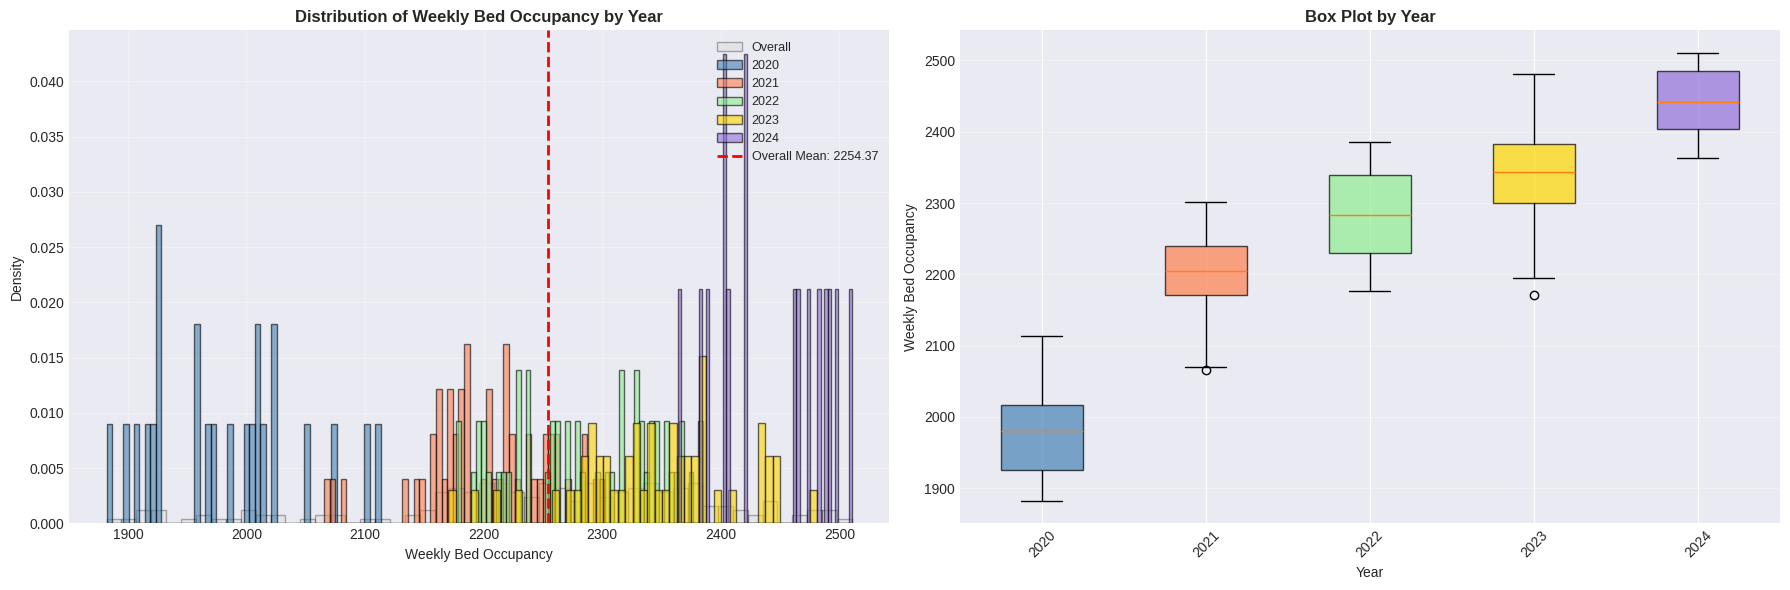

✓ Distribution plot saved (separated by year)


In [ ]:
# Distribution analysis (separated by year)
if len(weekly_occupancy) > 0:
    data = weekly_occupancy['bed_occupancy'].copy()

    # Use actual calendar years for COVID-19 data (2020-2024)
    # This is real date data, not deidentified anchor years
    weekly_occupancy_copy = weekly_occupancy.copy()
    weekly_occupancy_copy['year'] = weekly_occupancy_copy.index.year

    # Group data by year
    groups = {}
    for year in sorted(weekly_occupancy_copy['year'].unique()):
        group_data = weekly_occupancy_copy[weekly_occupancy_copy['year'] == year]['bed_occupancy']
        if len(group_data) > 0:
            groups[str(year)] = group_data

    print("\n" + "="*60)
    print("📊 DISTRIBUTION ANALYSIS (By Year)")
    print("="*60)
    print(f"Analyzing distribution of {len(data):,} weekly bed occupancy values")
    print(f"\nOverall Statistics:")
    print(f"  Mean: {data.mean():.2f} beds/week")
    print(f"  Median: {data.median():.2f} beds/week")
    print(f"  Std: {data.std():.2f}")
    print(f"  Min: {data.min():.2f}")
    print(f"  Max: {data.max():.2f}")
    print(f"  Skewness: {data.skew():.3f} ({'Right-skewed' if data.skew() > 0 else 'Left-skewed' if data.skew() < 0 else 'Symmetric'})")
    print(f"  Kurtosis: {data.kurtosis():.3f}")

    print(f"\nStatistics by Year:")
    for year_name in sorted(groups.keys()):
        group_data = groups[year_name]
        print(f"  {year_name}: n={len(group_data):,} weeks, mean={group_data.mean():.2f}, std={group_data.std():.2f}, range=[{group_data.min():.2f}, {group_data.max():.2f}]")

    print("\n📊 Plot: Histogram (left) shows overlapping distributions by year")
    print("   Box plot (right) shows side-by-side box plots for each year")

    # Define colors for each year
    colors = ['steelblue', 'coral', 'lightgreen', 'gold', 'mediumpurple']
    group_colors = {group: colors[i % len(colors)] for i, group in enumerate(sorted(groups.keys()))}

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    # Histogram: Overlapping distributions by year
    axes[0].hist(data, bins=50, color='lightgray', edgecolor='black', alpha=0.3, label='Overall', density=True)
    for group_name in sorted(groups.keys()):
        group_data = groups[group_name]
        axes[0].hist(group_data, bins=50, color=group_colors[group_name],
                    edgecolor='black', alpha=0.6, label=group_name, density=True)

    axes[0].axvline(data.mean(), color='red', linestyle='--', linewidth=2, label=f'Overall Mean: {data.mean():.2f}')
    axes[0].set_title('Distribution of Weekly Bed Occupancy by Year', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Weekly Bed Occupancy')
    axes[0].set_ylabel('Density')
    axes[0].legend(loc='upper right', fontsize=9)
    axes[0].grid(True, alpha=0.3)

    # Box plot: Side-by-side box plots for each year
    box_data = [groups[year].values for year in sorted(groups.keys())]
    box_labels = sorted(groups.keys())
    bp = axes[1].boxplot(box_data, labels=box_labels, patch_artist=True, vert=True)

    # Color the box plots
    for patch, year in zip(bp['boxes'], sorted(groups.keys())):
        patch.set_facecolor(group_colors[year])
        patch.set_alpha(0.7)

    axes[1].set_title('Box Plot by Year', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Year')
    axes[1].set_ylabel('Weekly Bed Occupancy')
    axes[1].grid(True, alpha=0.3, axis='y')
    axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    save_plot('admissions_distribution.png')
    plt.show()

    print("✓ Distribution plot saved (separated by year)")

## Trend Analysis

**Data Overview:**

1. **Weekly Data**: This analysis uses weekly bed occupancy data from COVID-19 Hospital Capacity dataset (197 weeks, 2020-07-19 to 2024-04-21).

2. **Data Source**: ADVENTHEALTH ORLANDO hospital capacity data:
   - Weekly bed occupancy counts (7-day averages)
   - Real calendar dates from 2020-07-19 to 2024-04-21
   - No deduplication needed - data is already at weekly frequency

3. **Year-over-Year Analysis**:
   - ✅ **Year-over-year comparisons** show COVID pandemic impact and recovery
   - ✅ **Rolling averages** (52-week) provide reliable annual trend information
   - ✅ **Seasonal patterns** are captured in weekly data
   - ⚠️ Note: 2020 data starts in July, so first year is partial



📈 TREND ANALYSIS
ℹ️  Using weekly bed occupancy data from COVID-19 Hospital Capacity dataset
   Years with data: 2020-2024 (5 years)
   Years displayed: [2020, 2021, 2022, 2023, 2024]

Yearly Statistics:
  2020: Avg=1981.83, Count=24 weeks, Total=47564
  2021: Avg=2201.91, Count=52 weeks, Total=114499
  2022: Avg=2284.44, Count=52 weeks, Total=118791
  2023: Avg=2343.12, Count=53 weeks, Total=124186
  2024: Avg=2441.92, Count=16 weeks, Total=39071

  Trend: increasing (23.2% change from 2020 to 2024)

📊 Plot 1 (Top): Yearly average trend
   - Shows average weekly bed occupancy per year (one point per year)
   - Values represent weekly averages for each calendar year
   - Helps identify long-term trends and year-over-year changes

📊 Plot 2 (Bottom): Weekly time series with 52-week rolling average
   - Light blue line: Raw weekly bed occupancy (shows week-to-week variation)
   - Red line: 52-week centered rolling average (smoothed trend)
   - Rolling window removes seasonality to reveal

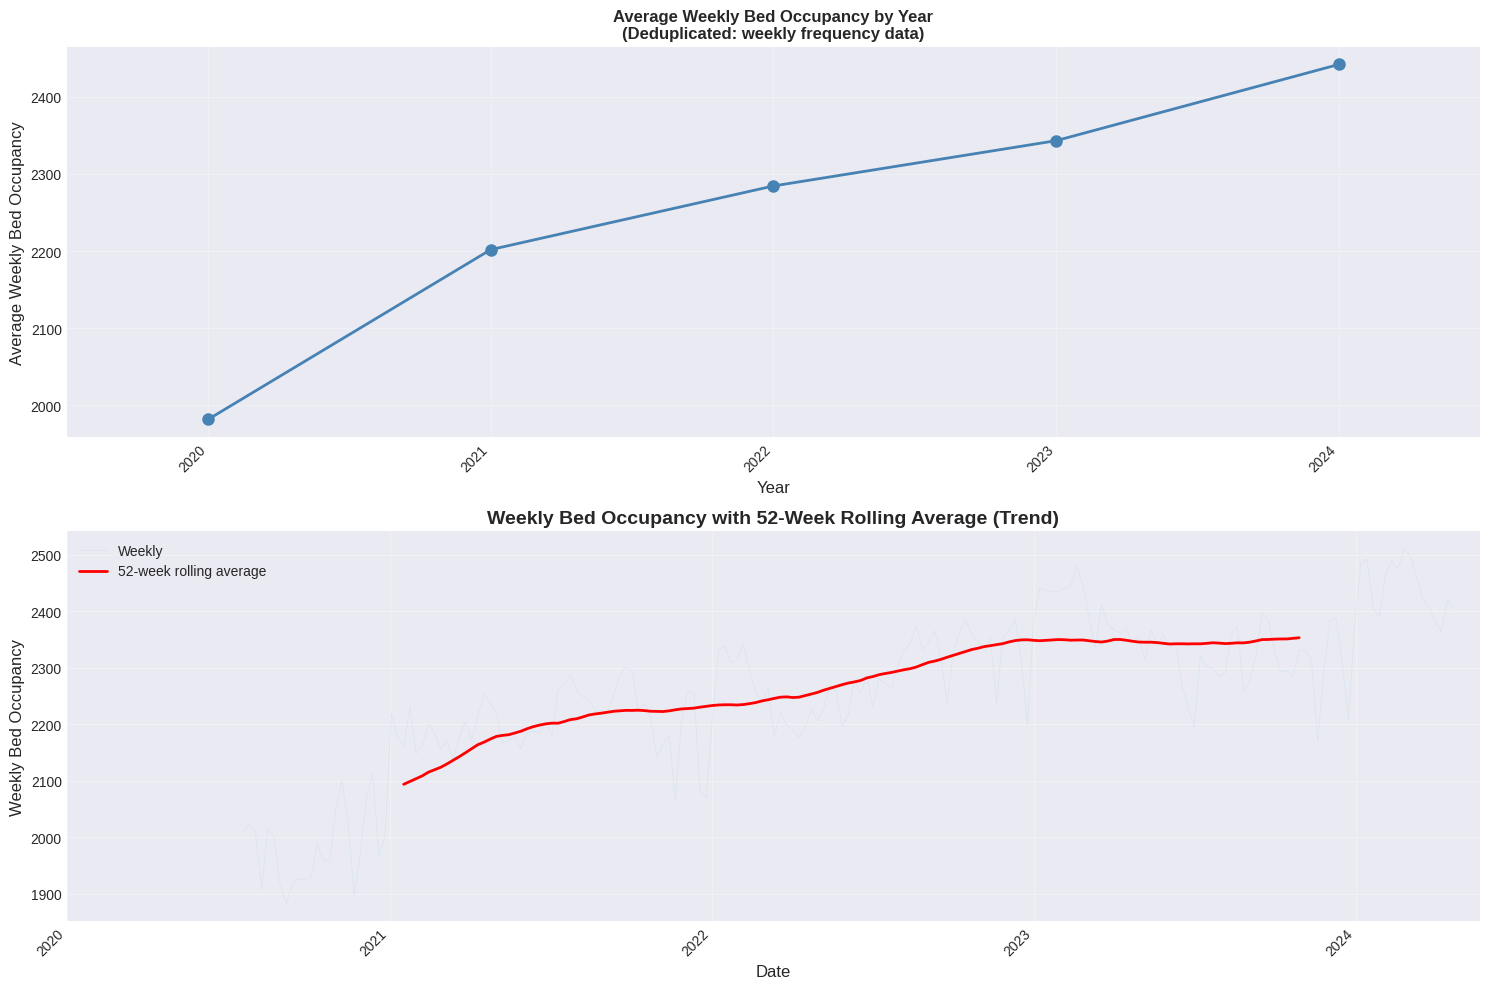


✓ Trend analysis plots saved
   Note: Year-over-year comparisons show averaged values by calendar year.
   Rolling averages provide smoothed trend information.



In [ ]:
# Year-over-year and trend analysis
if len(weekly_occupancy) > 0:
    print("\n" + "="*60)
    print("📈 TREND ANALYSIS")
    print("="*60)

    # Calculate yearly averages and counts (only includes years with data)
    yearly_avg = weekly_occupancy.groupby(weekly_occupancy.index.year)['bed_occupancy'].mean()
    yearly_count = weekly_occupancy.groupby(weekly_occupancy.index.year)['bed_occupancy'].count()
    yearly_total = weekly_occupancy.groupby(weekly_occupancy.index.year)['bed_occupancy'].sum()

    years_with_data = yearly_avg.index.tolist()

    print("ℹ️  Using weekly bed occupancy data from COVID-19 Hospital Capacity dataset")
    print(f"   Years with data: {min(years_with_data)}-{max(years_with_data)} ({len(years_with_data)} years)")
    print(f"   Years displayed: {sorted(years_with_data)}")
    print("\nYearly Statistics:")
    for year in sorted(years_with_data):
        print(f"  {year}: Avg={yearly_avg[year]:.2f}, Count={yearly_count[year]} weeks, Total={yearly_total[year]:.0f}")

    # Check for trend
    if len(yearly_avg) >= 2:
        trend_direction = "increasing" if yearly_avg.iloc[-1] > yearly_avg.iloc[0] else "decreasing"
        trend_magnitude = abs((yearly_avg.iloc[-1] - yearly_avg.iloc[0]) / yearly_avg.iloc[0] * 100)
        print(f"\n  Trend: {trend_direction} ({trend_magnitude:.1f}% change from {yearly_avg.index[0]} to {yearly_avg.index[-1]})")
        if trend_magnitude > 50:
            print(f"    ⚠️  Large trend detected - verify if this reflects real changes or data processing artifacts")
    print("\n📊 Plot 1 (Top): Yearly average trend")
    print("   - Shows average weekly bed occupancy per year (one point per year)")
    print("   - Values represent weekly averages for each calendar year")
    print("   - Helps identify long-term trends and year-over-year changes")

    if len(weekly_occupancy) >= 52:
        rolling_year = weekly_occupancy['bed_occupancy'].rolling(window=52, center=True).mean()
        rolling_std = weekly_occupancy['bed_occupancy'].rolling(window=52, center=True).std()
        print(f"\n📊 Plot 2 (Bottom): Weekly time series with 52-week rolling average")
        print(f"   - Light blue line: Raw weekly bed occupancy (shows week-to-week variation)")
        print(f"   - Red line: 52-week centered rolling average (smoothed trend)")
        print(f"   - Rolling window removes seasonality to reveal underlying trend")
        print(f"   - Rolling avg range: {rolling_year.min():.2f} to {rolling_year.max():.2f}")
    else:
        print(f"\n⚠️  Not enough data for 52-week rolling average (need 52+ weeks, have {len(weekly_occupancy)})")

    fig, axes = plt.subplots(2, 1, figsize=(15, 10))

    # Yearly trend ( data - weekly data)
    # Only plot years that have data (skip empty years)
    axes[0].plot(yearly_avg.index, yearly_avg.values, marker='o', linewidth=2, markersize=8, color='steelblue')
    # Set x-axis limits to only include years with data (add small padding)
    axes[0].set_xlim(min(years_with_data) - 0.5, max(years_with_data) + 0.5)
    axes[0].set_xticks(years_with_data)  # Only show years with data
    axes[0].set_xticklabels(years_with_data, rotation=45, ha='right')
    axes[0].set_title('Average Weekly Bed Occupancy by Year\n(Deduplicated: weekly frequency data)',
                     fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Year', fontsize=12)
    axes[0].set_ylabel('Average Weekly Bed Occupancy', fontsize=12)
    axes[0].grid(True, alpha=0.3)

    # Rolling 52-week average (yearly trend)
    if len(weekly_occupancy) >= 52:
        axes[1].plot(weekly_occupancy.index, weekly_occupancy['bed_occupancy'], alpha=0.3, color='lightblue', label='Weekly', linewidth=0.5)
        axes[1].plot(rolling_year.index, rolling_year.values, color='red', linewidth=2, label='52-week rolling average')
        axes[1].set_title('Weekly Bed Occupancy with 52-Week Rolling Average (Trend)', fontsize=14, fontweight='bold')
        axes[1].set_xlabel('Date', fontsize=12)
        axes[1].set_ylabel('Weekly Bed Occupancy', fontsize=12)
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)

        # Set x-axis to only show years with data (skip empty years)
        from matplotlib.ticker import NullLocator
        # Set xlim to actual data range with minimal padding to reduce empty space
        x_min = weekly_occupancy.index.min()
        x_max = weekly_occupancy.index.max()
        padding = pd.Timedelta(days=30)
        axes[1].set_xlim(x_min - padding, x_max + padding)
        axes[1].xaxis.set_major_locator(NullLocator())
        axes[1].xaxis.set_minor_locator(NullLocator())
        axes[1].set_xticks([pd.Timestamp(f'{year}-01-01') for year in years_with_data])
        axes[1].set_xticklabels([str(year) for year in years_with_data], rotation=45, ha='right')

    plt.tight_layout()
    save_plot('trend_analysis.png')
    plt.show()

    print("\n✓ Trend analysis plots saved")
    print("   Note: Year-over-year comparisons show averaged values by calendar year.")
    print("   Rolling averages provide smoothed trend information.\n")

## KPI Time Series Visualization



📊 KPI TIME SERIES VISUALIZATION
Plotting 10 KPIs over 197 weeks
KPIs to visualize: bed_occupancy, occupancy_rate, bed_capacity, icu_occupied, icu_capacity, icu_occupancy_rate, covid_inpatients, covid_icu, covid_patient_pct, staffed_beds

Statistics for each KPI:
  bed_occupancy:
    Mean: 2254.37, Std: 136.47
    Min: 1882.00, Max: 2510.70
    Range: 628.70
  occupancy_rate:
    Mean: 90.14, Std: 6.93
    Min: 66.81, Max: 98.40
    Range: 31.59
  bed_capacity:
    Mean: 2509.68, Std: 164.43
    Min: 2271.00, Max: 2895.90
    Range: 624.90
  icu_occupied:
    Mean: 276.82, Std: 21.99
    Min: 225.70, Max: 340.00
    Range: 114.30
  icu_capacity:
    Mean: 341.18, Std: 25.75
    Min: 297.00, Max: 447.70
    Range: 150.70
  icu_occupancy_rate:
    Mean: 81.69, Std: 9.81
    Min: 56.89, Max: 108.28
    Range: 51.39
  covid_inpatients:
    Mean: 201.25, Std: 168.16
    Min: 35.00, Max: 887.40
    Range: 852.40
  covid_icu:
    Mean: 29.97, Std: 34.33
    Min: 4.00, Max: 233.20
    Range: 2

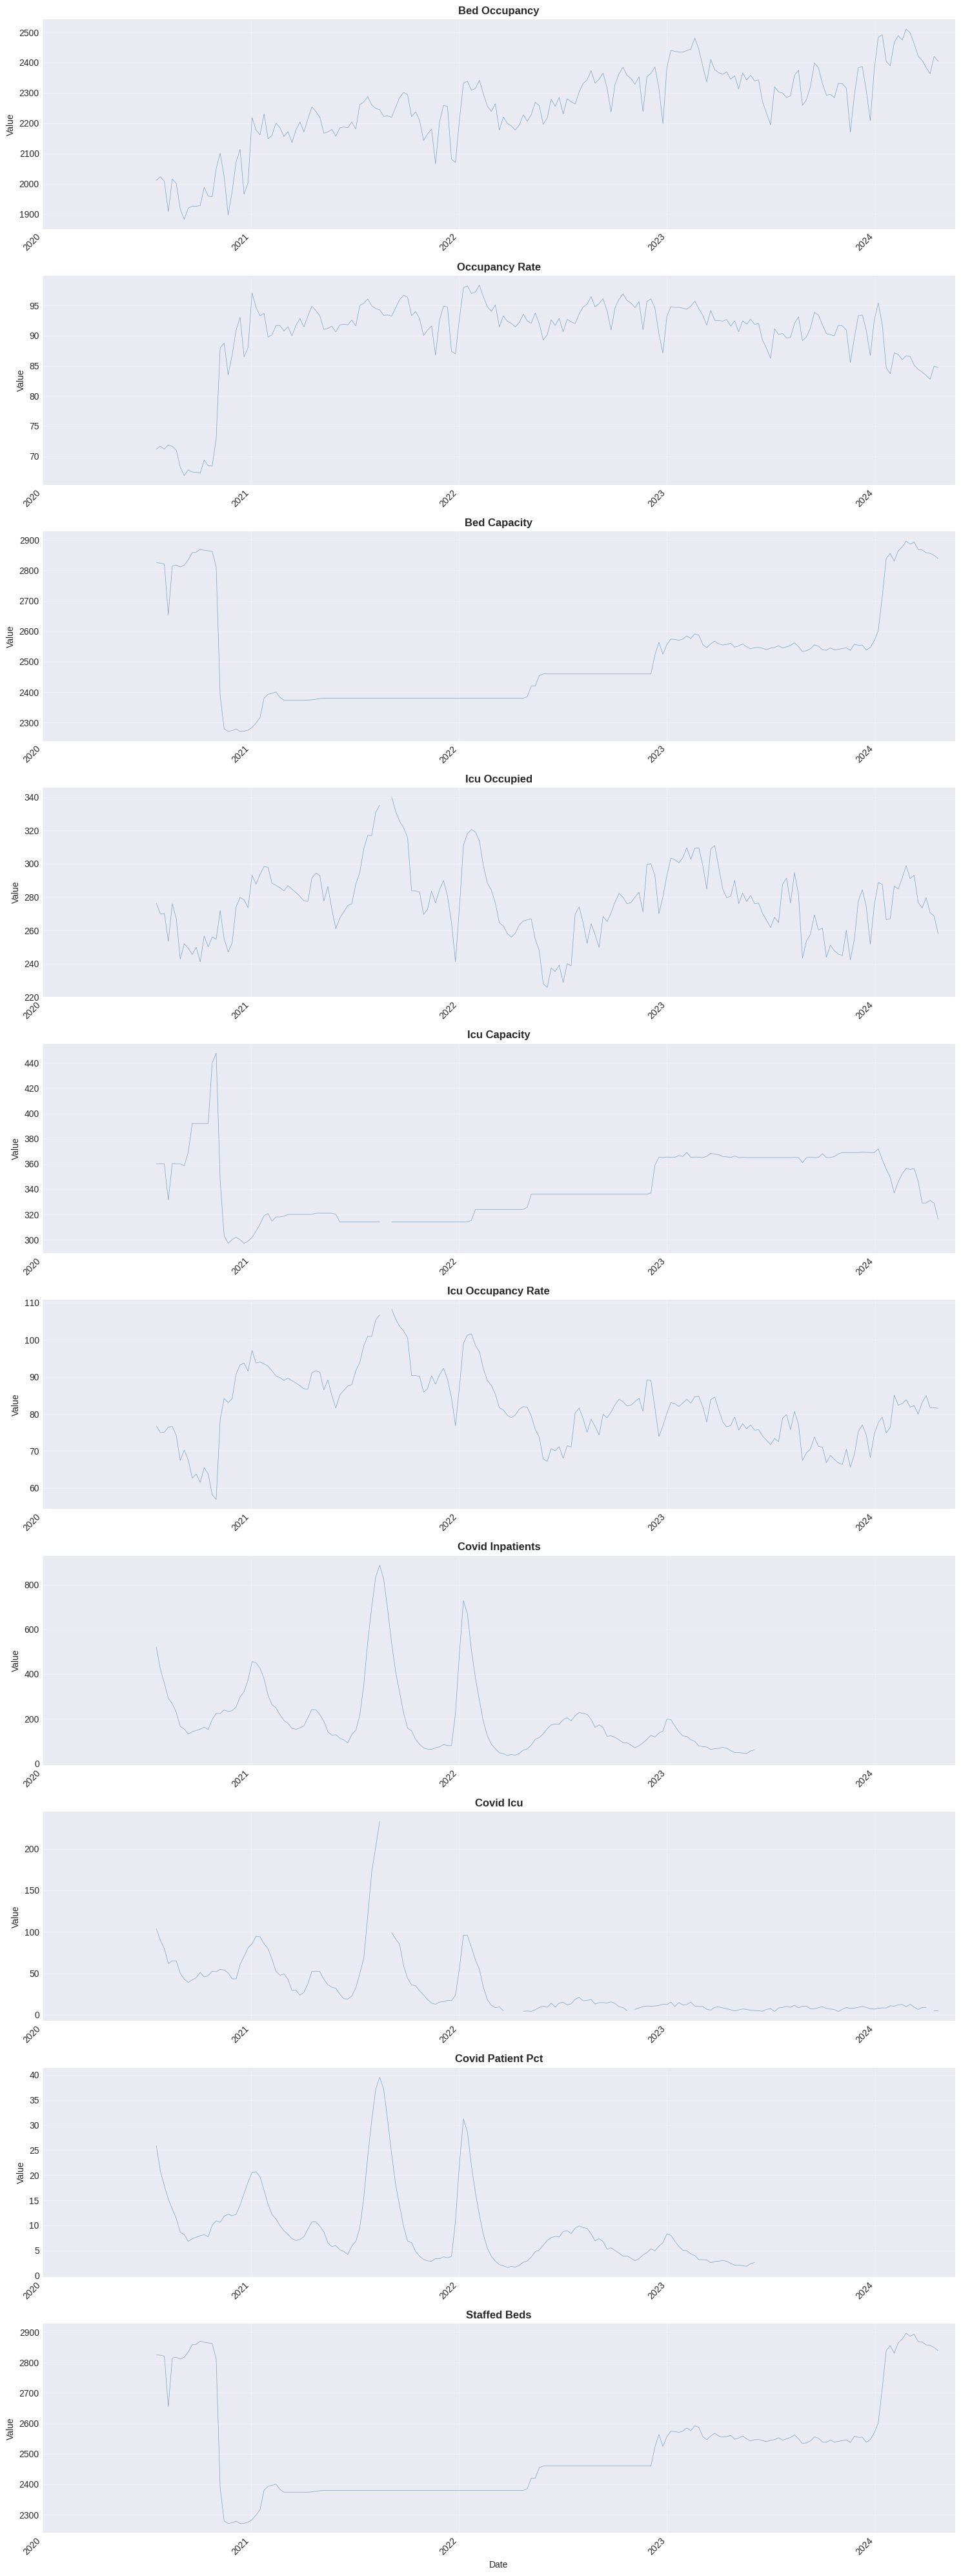

✓ KPI time series plots saved


📈 EXTERNAL FEATURES TIME SERIES VISUALIZATION

📊 Creating time series plots for external features:
   Weather features: 6 (temp_avg, temp_max, temp_min, precipitation, wind_speed, pressure)
   Flu features: 4 (flu_activity_level, wili, ili, is_flu_season)
   We expect to see:
     • Seasonal patterns (temperature cycles, flu season cycles)
     • Trends over time
     • Outliers or unusual periods
     • Variability in each feature

🌤️  Weather Features Time Series:
   Analyzing 6 weather features over 197 weeks


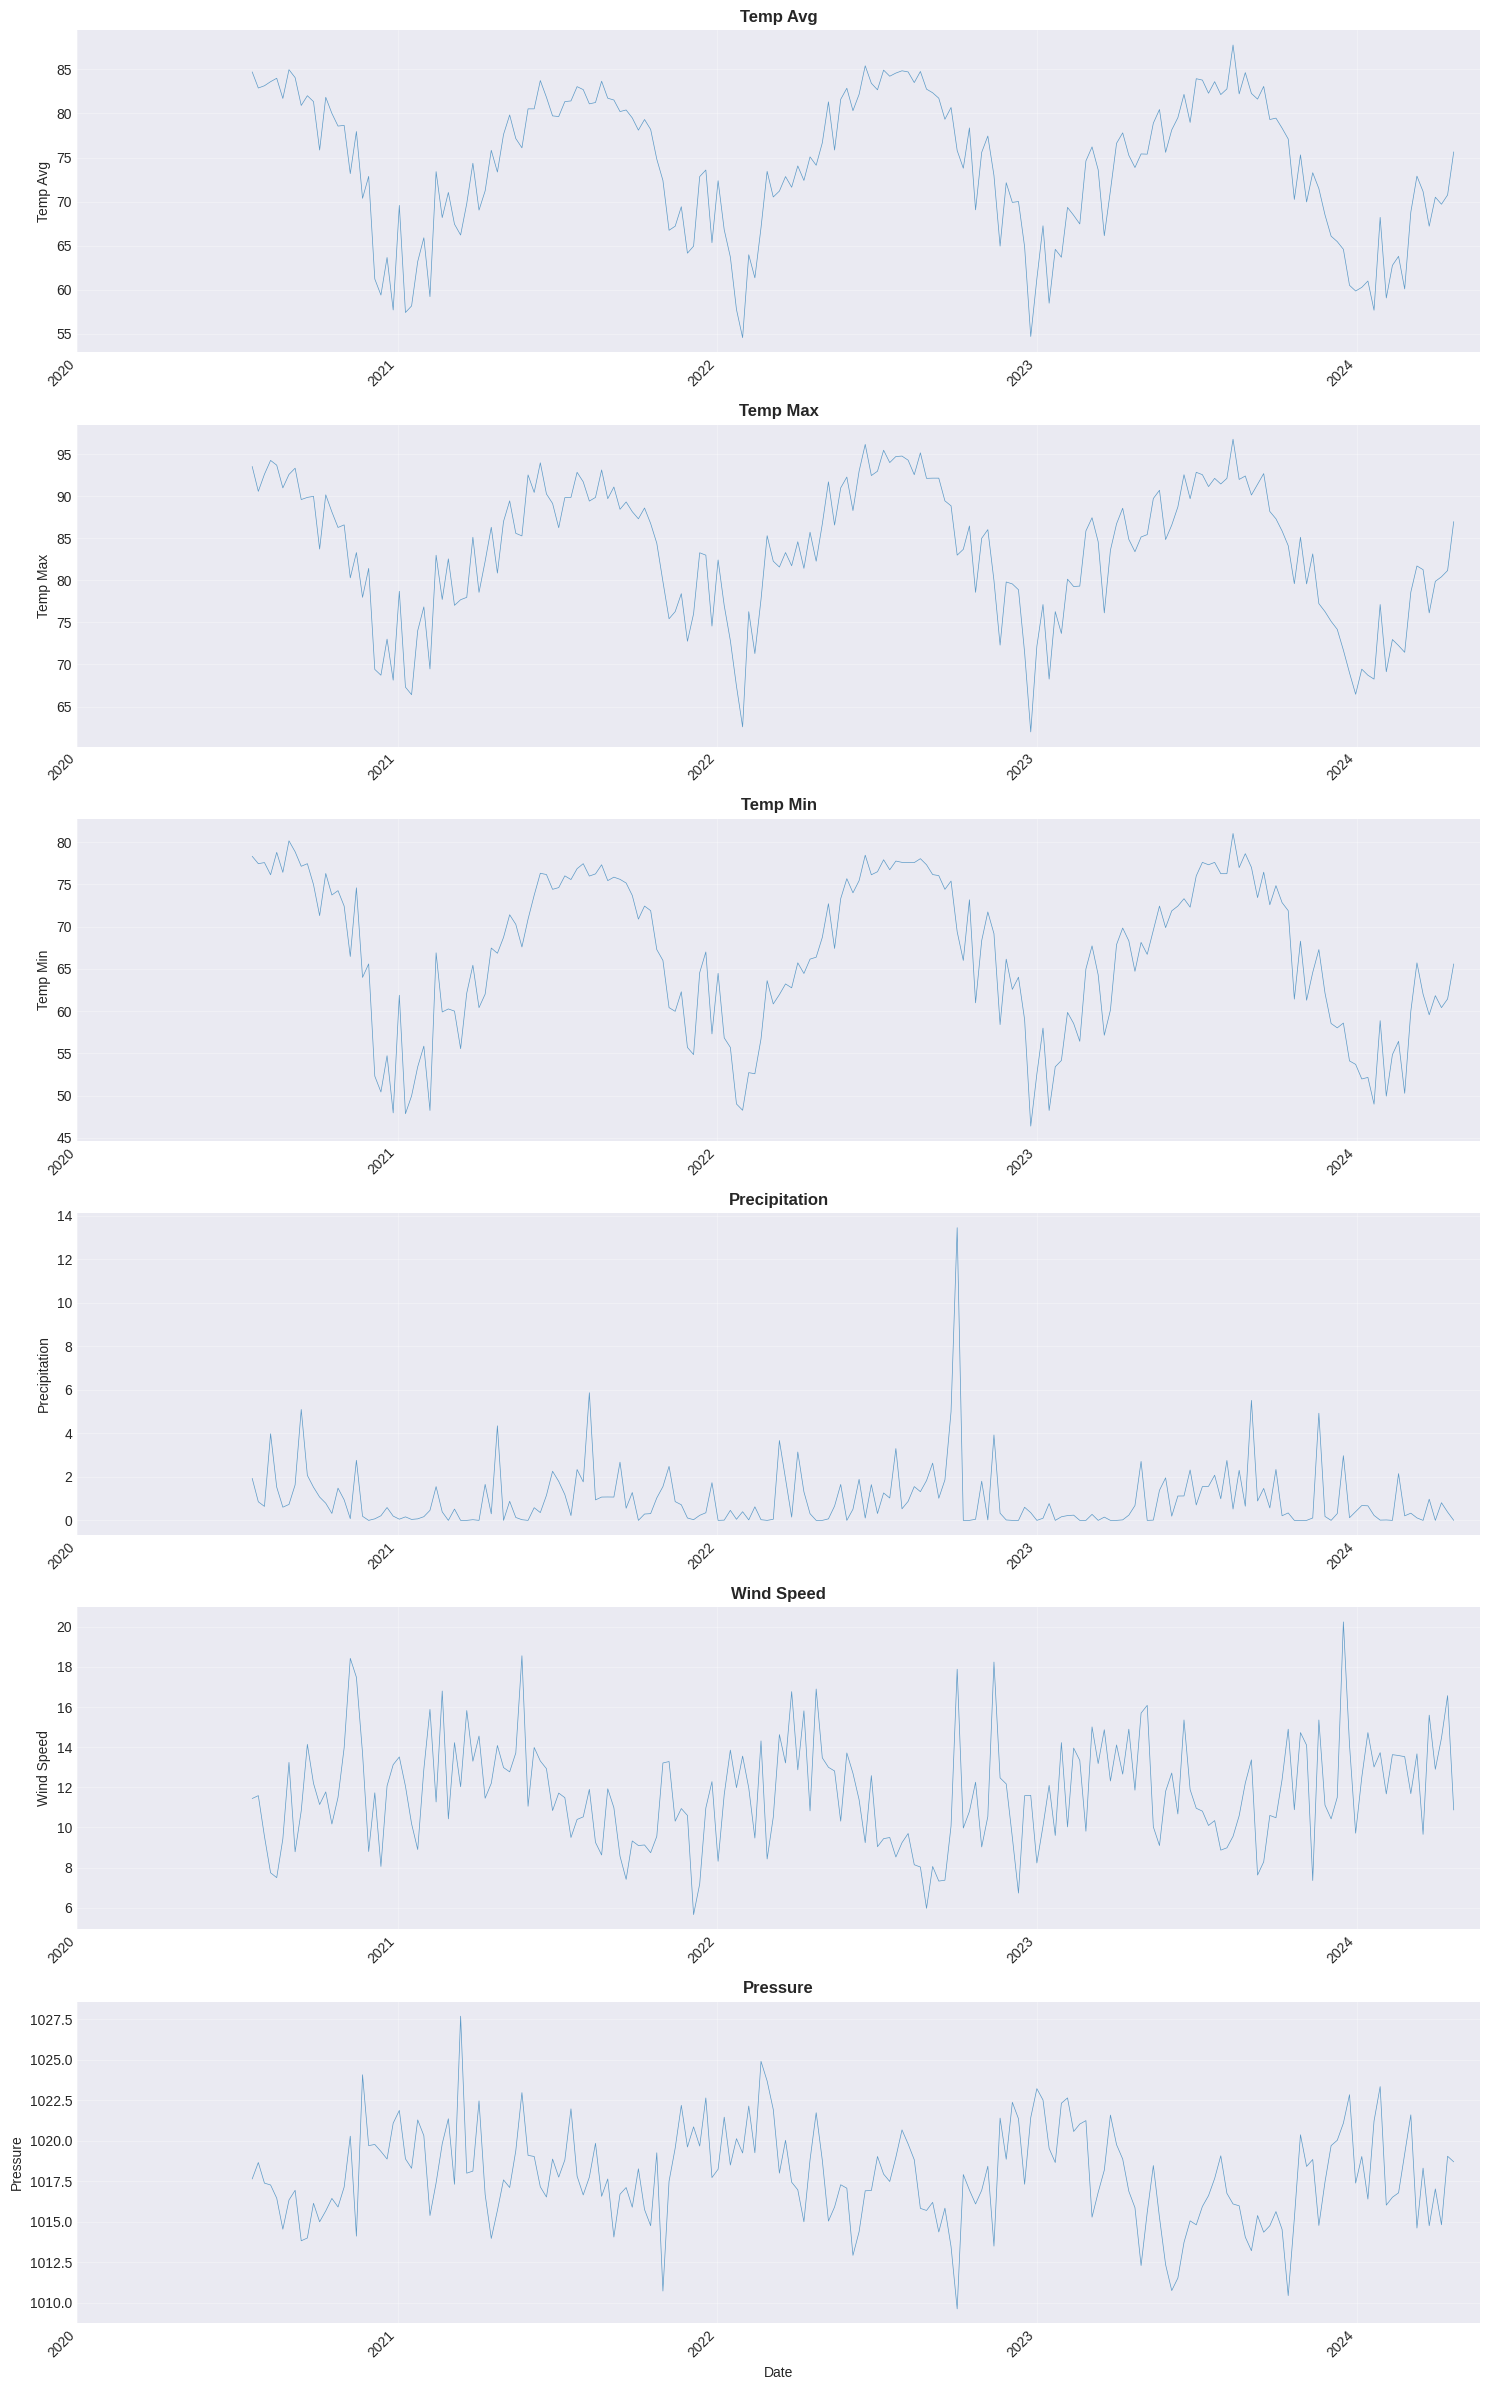


🔍 Weather Features Analysis:
   temp_avg:
     Mean: 74.12, Std: 7.90
     Min: 54.55 (on 2022-01-30), Max: 87.77 (on 2023-08-13)
     Range: 33.22
   temp_max:
     Mean: 83.48, Std: 7.91
     Min: 61.98 (on 2022-12-25), Max: 96.77 (on 2023-08-13)
     Range: 34.79
   temp_min:
     Mean: 66.71, Std: 8.94
     Min: 46.40 (on 2022-12-25), Max: 81.01 (on 2023-08-13)
     Range: 34.61
   precipitation:
     Mean: 0.97, Std: 1.46
     Min: 0.00 (on 2020-11-29), Max: 13.44 (on 2022-10-02)
     Range: 13.44
   wind_speed:
     Mean: 11.74, Std: 2.61
     Min: 5.66 (on 2021-12-05), Max: 20.24 (on 2023-12-17)
     Range: 14.59
   pressure:
     Mean: 1017.84, Std: 2.91
     Min: 1009.63 (on 2022-10-02), Max: 1027.69 (on 2021-03-14)
     Range: 18.06
   Patterns observed:
     • Temperature shows annual cycle (winter low, summer high)
     • Temperature range: 54.6°F to 87.8°F
✓ Weather time series plots saved: weather_timeseries.png

🦠 Flu Features Time Series:
   Analyzing 4 flu features ov

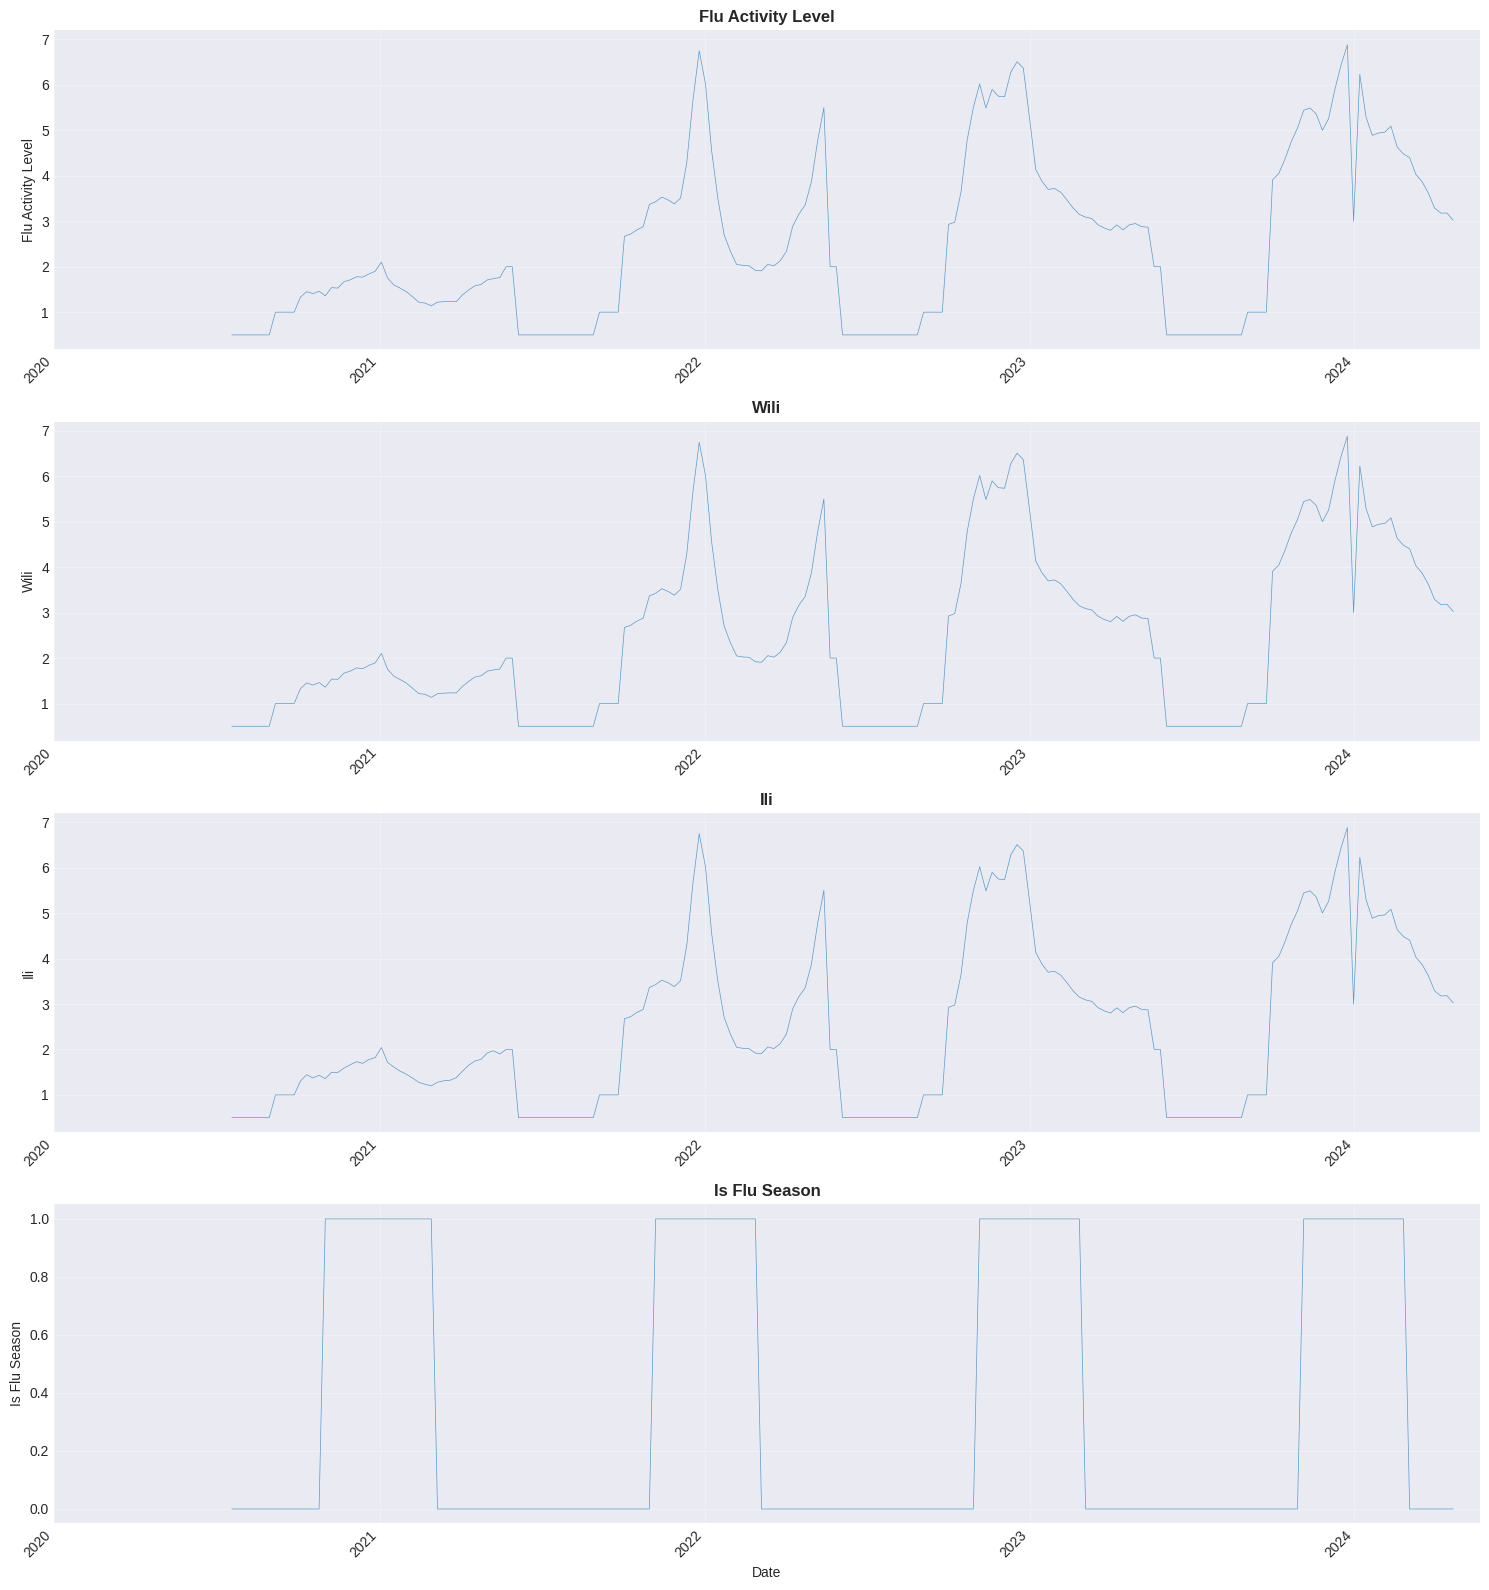


🔍 Flu Features Analysis:
   flu_activity_level:
     Mean: 2.46, Std: 1.80
     Min: 0.50, Max: 6.88
     Range: 0-10 scale, typical flu season peaks at higher values
   wili:
     Mean: 2.46, Std: 1.80
     Min: 0.50, Max: 6.88
   ili:
     Mean: 2.47, Std: 1.80
     Min: 0.50, Max: 6.88
   is_flu_season:
     Mean: 0.35, Std: 0.48
     Min: 0.00, Max: 1.00
   Patterns observed:
     • Flu activity shows seasonal peaks (typically winter/spring)
     • Peak flu activity: 6.88 (scale 0-10)
✓ Flu time series plots saved: flu_timeseries.png

✓ External features time series visualization complete



In [ ]:
# Plot all KPIs together (if KPI data is available)
if len(weekly_occupancy) > 0 and len(weekly_kpis) > 0:
    print("\n" + "="*60)
    print("📊 KPI TIME SERIES VISUALIZATION")
    print("="*60)
    print(f"Plotting {len(weekly_kpis.columns)} KPIs over {len(weekly_kpis):,} weeks")
    print(f"KPIs to visualize: {', '.join(weekly_kpis.columns)}")
    print("\nStatistics for each KPI:")
    for col in weekly_kpis.columns:
        stats = weekly_kpis[col]
        print(f"  {col}:")
        print(f"    Mean: {stats.mean():.2f}, Std: {stats.std():.2f}")
        print(f"    Min: {stats.min():.2f}, Max: {stats.max():.2f}")
        print(f"    Range: {stats.max() - stats.min():.2f}")

    print("\n📊 Plot: One subplot per KPI showing time series evolution")
    print("   - Each panel shows weekly values over time")
    print("   - Helps identify patterns, trends, and relationships between KPIs")

    fig, axes = plt.subplots(len(weekly_kpis.columns), 1, figsize=(15, 4*len(weekly_kpis.columns)))
    if len(weekly_kpis.columns) == 1:
        axes = [axes]

    # Get years with data (to skip empty years on x-axis)
    years_with_data = sorted(weekly_kpis.index.year.unique())
    year_labels = [str(year) for year in years_with_data]

    # Import for disabling auto ticks
    from matplotlib.ticker import NullLocator

    for idx, col in enumerate(weekly_kpis.columns):
        axes[idx].plot(weekly_kpis.index, weekly_kpis[col], alpha=0.6, linewidth=0.5)
        axes[idx].set_title(f'{col.replace("_", " ").title()}', fontsize=12, fontweight='bold')
        axes[idx].set_ylabel('Value', fontsize=10)
        axes[idx].grid(True, alpha=0.3)

                # Set x-axis to only show years with data (skip empty years)
        # Set xlim to actual data range with minimal padding to reduce empty space
        x_min = weekly_kpis.index.min()
        x_max = weekly_kpis.index.max()
        padding = pd.Timedelta(days=30)
        axes[idx].set_xlim(x_min - padding, x_max + padding)
        # Disable automatic tick locator first
        axes[idx].xaxis.set_major_locator(NullLocator())
        axes[idx].xaxis.set_minor_locator(NullLocator())

        # Manually set ticks to show only years with data
        year_ticks = [pd.Timestamp(f'{year}-01-01') for year in years_with_data]
        axes[idx].set_xticks(year_ticks)
        axes[idx].set_xticklabels(year_labels, rotation=45, ha='right')

        if idx == len(weekly_kpis.columns) - 1:
            axes[idx].set_xlabel('Date', fontsize=10)

    plt.tight_layout()
    save_plot('kpi_timeseries.png')
    plt.show()

    print("✓ KPI time series plots saved\n")
elif len(weekly_occupancy) > 0:
    print("ℹ️  KPI data not available for visualization")

# ============================================================================
# SECTION 3: EXTERNAL FEATURES TIME SERIES VISUALIZATION
# ============================================================================
if len(data_with_external) > 0 and len(EXTERNAL_FEATURES) > 0:
    print("\n" + "="*70)
    print("📈 EXTERNAL FEATURES TIME SERIES VISUALIZATION")
    print("="*70)

    # Separate weather and flu features
    weather_features = [f for f in EXTERNAL_FEATURES if f in ['temp_avg', 'temp_max', 'temp_min', 'precipitation', 'wind_speed', 'pressure']]
    flu_features = [f for f in EXTERNAL_FEATURES if f in ['epiweek', 'flu_activity_level', 'wili', 'ili', 'is_flu_season']]

    print(f"\n📊 Creating time series plots for external features:")
    print(f"   Weather features: {len(weather_features)} ({', '.join(weather_features)})")
    print(f"   Flu features: {len(flu_features)} ({', '.join(flu_features)})")
    print(f"   We expect to see:")
    print(f"     • Seasonal patterns (temperature cycles, flu season cycles)")
    print(f"     • Trends over time")
    print(f"     • Outliers or unusual periods")
    print(f"     • Variability in each feature")

    # Weather features visualization
    if len(weather_features) > 0:
        print(f"\n🌤️  Weather Features Time Series:")
        print(f"   Analyzing {len(weather_features)} weather features over {len(data_with_external):,} weeks")

        n_weather = len(weather_features)
        fig, axes = plt.subplots(n_weather, 1, figsize=(15, 4*n_weather))
        if n_weather == 1:
            axes = [axes]

        years_with_data = sorted(data_with_external.index.year.unique())
        from matplotlib.ticker import NullLocator

        for idx, feat in enumerate(weather_features):
            data = data_with_external[feat]
            axes[idx].plot(data.index, data.values, alpha=0.7, linewidth=0.5)
            axes[idx].set_title(f'{feat.replace("_", " ").title()}', fontsize=12, fontweight='bold')
            axes[idx].set_ylabel(feat.replace("_", " ").title(), fontsize=10)
            axes[idx].grid(True, alpha=0.3)

            # Fix x-axis to only show years with data
            x_min = data.index.min()
            x_max = data.index.max()
            padding = pd.Timedelta(days=30)
            axes[idx].set_xlim(x_min - padding, x_max + padding)
            axes[idx].xaxis.set_major_locator(NullLocator())
            axes[idx].xaxis.set_minor_locator(NullLocator())
            year_ticks = [pd.Timestamp(f'{year}-01-01') for year in years_with_data]
            axes[idx].set_xticks(year_ticks)
            axes[idx].set_xticklabels([str(year) for year in years_with_data], rotation=45, ha='right')

            if idx == n_weather - 1:
                axes[idx].set_xlabel('Date', fontsize=10)

        plt.tight_layout()
        save_plot('weather_timeseries.png')
        plt.show()

        print("\n🔍 Weather Features Analysis:")
        for feat in weather_features:
            data = data_with_external[feat]
            print(f"   {feat}:")
            print(f"     Mean: {data.mean():.2f}, Std: {data.std():.2f}")
            print(f"     Min: {data.min():.2f} (on {data.idxmin().date()}), Max: {data.max():.2f} (on {data.idxmax().date()})")
            print(f"     Range: {data.max() - data.min():.2f}")

        print("   Patterns observed:")
        if 'temp_avg' in weather_features:
            temp_data = data_with_external['temp_avg']
            print(f"     • Temperature shows annual cycle (winter low, summer high)")
            print(f"     • Temperature range: {temp_data.min():.1f}°F to {temp_data.max():.1f}°F")
        print("✓ Weather time series plots saved: weather_timeseries.png")

    # Flu features visualization
    if len(flu_features) > 0:
        print(f"\n🦠 Flu Features Time Series:")
        print(f"   Analyzing {len(flu_features)} flu features over {len(data_with_external):,} weeks")

        n_flu = len(flu_features)
        fig, axes = plt.subplots(n_flu, 1, figsize=(15, 4*n_flu))
        if n_flu == 1:
            axes = [axes]

        for idx, feat in enumerate(flu_features):
            data = data_with_external[feat]
            axes[idx].plot(data.index, data.values, alpha=0.7, linewidth=0.5)
            axes[idx].set_title(f'{feat.replace("_", " ").title()}', fontsize=12, fontweight='bold')
            axes[idx].set_ylabel(feat.replace("_", " ").title(), fontsize=10)
            axes[idx].grid(True, alpha=0.3)

            # Fix x-axis
            x_min = data.index.min()
            x_max = data.index.max()
            padding = pd.Timedelta(days=30)
            axes[idx].set_xlim(x_min - padding, x_max + padding)
            axes[idx].xaxis.set_major_locator(NullLocator())
            axes[idx].xaxis.set_minor_locator(NullLocator())
            year_ticks = [pd.Timestamp(f'{year}-01-01') for year in years_with_data]
            axes[idx].set_xticks(year_ticks)
            axes[idx].set_xticklabels([str(year) for year in years_with_data], rotation=45, ha='right')

            if idx == n_flu - 1:
                axes[idx].set_xlabel('Date', fontsize=10)

        plt.tight_layout()
        save_plot('flu_timeseries.png')
        plt.show()

        print("\n🔍 Flu Features Analysis:")
        for feat in flu_features:
            data = data_with_external[feat]
            print(f"   {feat}:")
            print(f"     Mean: {data.mean():.2f}, Std: {data.std():.2f}")
            print(f"     Min: {data.min():.2f}, Max: {data.max():.2f}")
            if feat == 'flu_activity_level':
                print(f"     Range: 0-10 scale, typical flu season peaks at higher values")

        print("   Patterns observed:")
        if 'flu_activity_level' in flu_features:
            flu_data = data_with_external['flu_activity_level']
            print(f"     • Flu activity shows seasonal peaks (typically winter/spring)")
            print(f"     • Peak flu activity: {flu_data.max():.2f} (scale 0-10)")
        print("✓ Flu time series plots saved: flu_timeseries.png")

    print("\n✓ External features time series visualization complete\n")
else:
    print("ℹ️  External features not available for time series visualization")

## Correlation Analysis



🔗 CORRELATION ANALYSIS
Calculating correlation matrix between KPIs...
   - Correlation ranges from -1 (perfect negative) to +1 (perfect positive)
   - Values close to 0 indicate weak/no linear relationship
   - Red colors = positive correlation, Blue colors = negative correlation

📊 Plot: Heatmap showing pairwise correlations
   - Darker red = stronger positive correlation
   - Darker blue = stronger negative correlation
   - White = weak/no correlation
   - Diagonal is always 1.0 (variable correlated with itself)


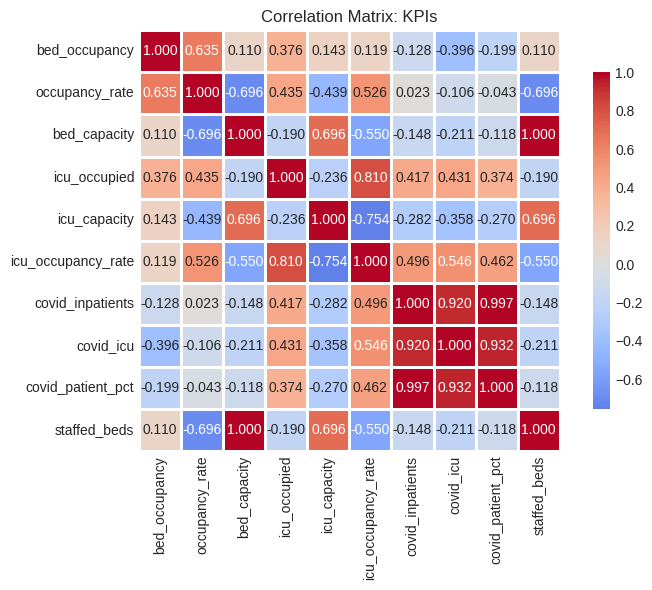


Correlation matrix (numerical values):
                    bed_occupancy  occupancy_rate  bed_capacity  icu_occupied  \
bed_occupancy            1.000000        0.634972      0.110203      0.375928   
occupancy_rate           0.634972        1.000000     -0.696298      0.435060   
bed_capacity             0.110203       -0.696298      1.000000     -0.190051   
icu_occupied             0.375928        0.435060     -0.190051      1.000000   
icu_capacity             0.143070       -0.439128      0.696177     -0.235811   
icu_occupancy_rate       0.119079        0.526181     -0.549643      0.809796   
covid_inpatients        -0.128070        0.022815     -0.148263      0.416765   
covid_icu               -0.396251       -0.106087     -0.210729      0.431386   
covid_patient_pct       -0.199291       -0.043070     -0.117897      0.374368   
staffed_beds             0.110203       -0.696298      1.000000     -0.190051   

                    icu_capacity  icu_occupancy_rate  covid_inpatien

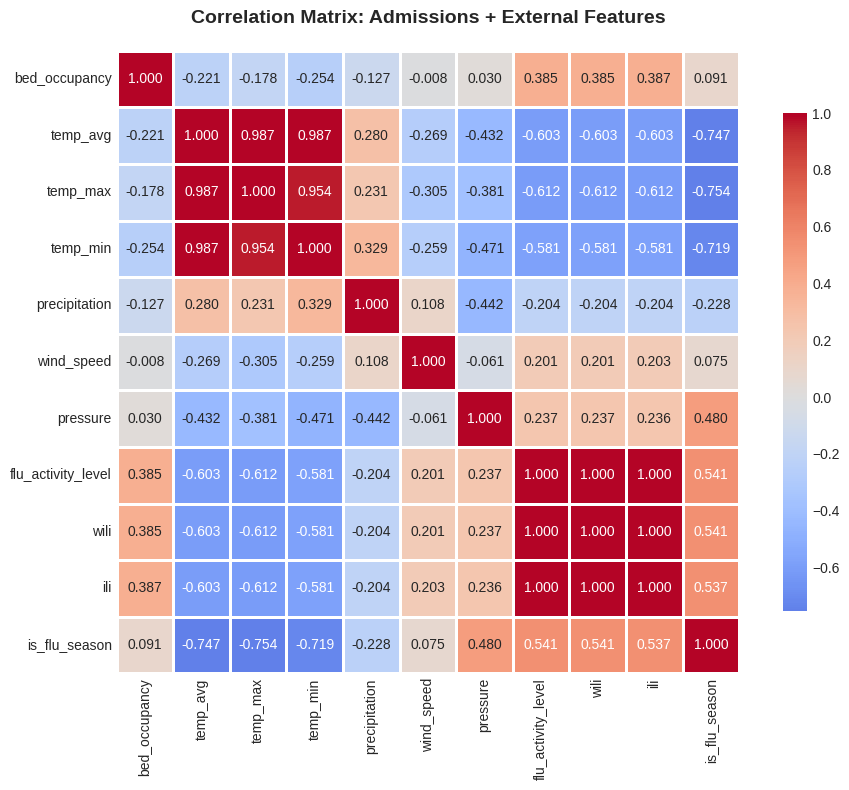


🔍 Correlation Analysis Results:

Correlations with Admissions (sorted by absolute value):
----------------------------------------------------------------------
  ili                      :   0.387 (STRONG   positive)
  wili                     :   0.385 (STRONG   positive)
  flu_activity_level       :   0.385 (STRONG   positive)
  temp_min                 :  -0.254 (MODERATE negative)
  temp_avg                 :  -0.221 (MODERATE negative)
  temp_max                 :  -0.178 (MODERATE negative)
  precipitation            :  -0.127 (WEAK     negative)
  is_flu_season            :   0.091 (WEAK     positive)
  pressure                 :   0.030 (WEAK     positive)
  wind_speed               :  -0.008 (WEAK     negative)

💡 Feature Categorization:
   Strong predictors (|r| > 0.3): 3 features
     ['ili', 'wili', 'flu_activity_level']
   Moderate predictors (0.15 < |r| <= 0.3): 3 features
     ['temp_min', 'temp_avg', 'temp_max']
   Weak predictors (|r| <= 0.15): 4 features
     ['prec

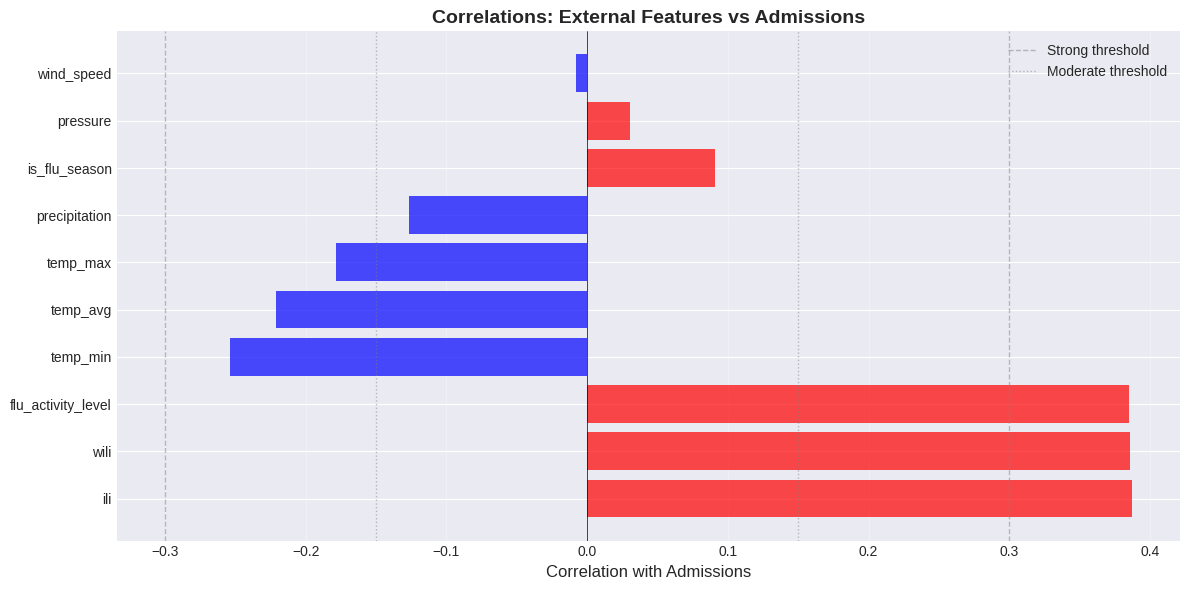


✓ Correlation analysis complete
   Visualizations saved: correlation_external_features.png, correlation_external_features_bar.png
   Use these correlations to guide feature selection for modeling


📊 STATISTICAL SIGNIFICANCE: EXTERNAL FEATURES

📊 Creating statistical significance analysis:
   Calculating p-values for correlations to distinguish real relationships from noise
   Statistical significance (p < 0.05) indicates a relationship is unlikely due to chance
   This helps us trust correlations and make informed feature selection decisions
   Applying Bonferroni correction for multiple testing to control false positive rate

📈 Statistical Tests:
   Testing 10 external features for correlation with admissions
   Bonferroni-corrected significance threshold: 0.0050 (original α=0.05)

🔍 Statistical Significance Results:
--------------------------------------------------------------------------------
Feature                   Correlation  P-value      Sig (p<0.05)    Sig (Bonf)  
------

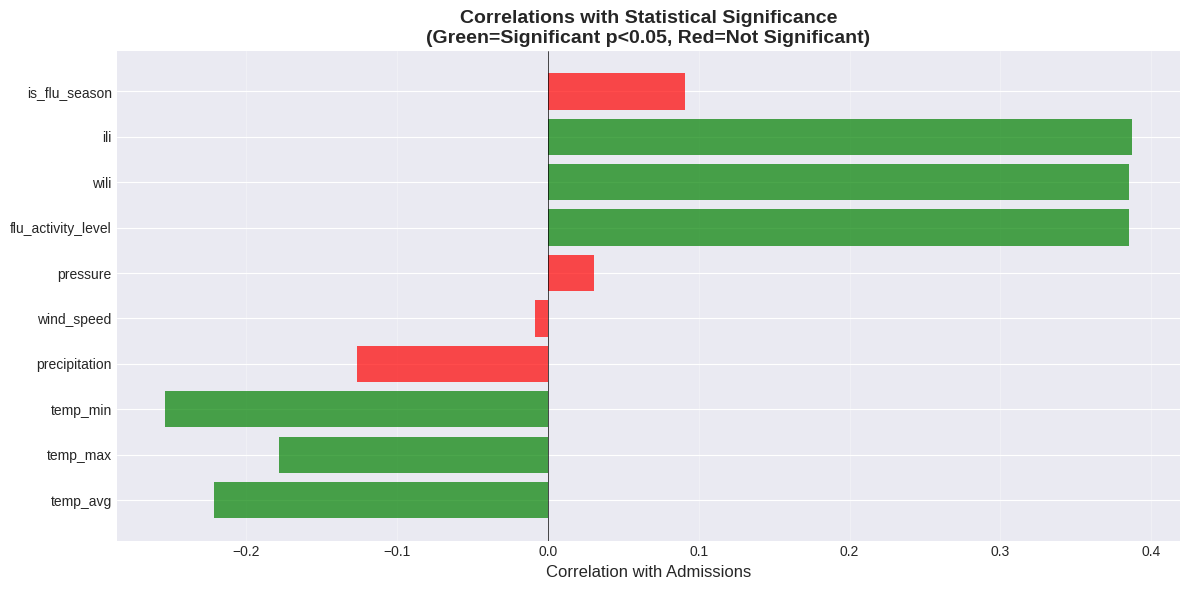


✓ Statistical significance analysis complete
   Visualization saved: correlation_significance.png
   Use significance results to filter features for modeling


🔗 MULTICOLLINEARITY: EXTERNAL FEATURES RELATIONSHIPS

📊 Creating multicollinearity analysis:
   Analyzing correlations between external features (not with admissions)
   High correlations between features indicate redundancy
   This helps identify which features can be dropped without losing information
   Key threshold: |r| > 0.8 indicates high multicollinearity

📈 Multicollinearity Analysis:
   Analyzing 10 external features
   Total feature pairs: 45


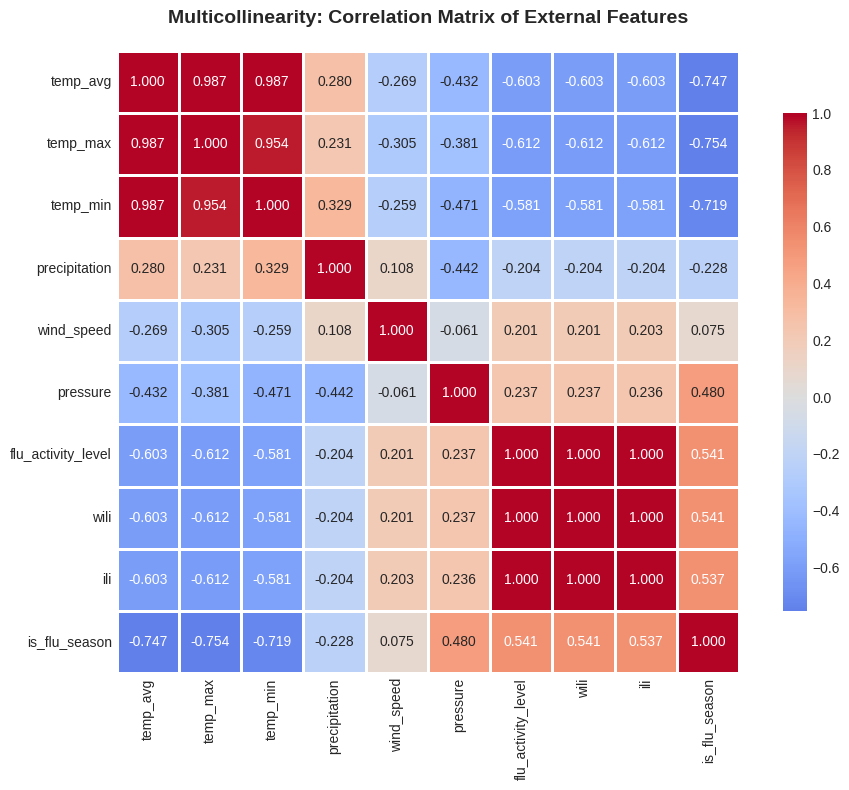


🔍 Multicollinearity Results:

⚠️  HIGH MULTICOLLINEARITY (|r| > 0.8) - Consider dropping one feature from each pair:
--------------------------------------------------------------------------------
   flu_activity_level        ↔ wili                     : r =   1.000
      → Recommendation: Keep one, drop the other (they contain similar information)
   flu_activity_level        ↔ ili                      : r =   1.000
      → Recommendation: Keep one, drop the other (they contain similar information)
   wili                      ↔ ili                      : r =   1.000
      → Recommendation: Keep one, drop the other (they contain similar information)
   temp_avg                  ↔ temp_max                 : r =   0.987
      → Recommendation: Keep one, drop the other (they contain similar information)
   temp_avg                  ↔ temp_min                 : r =   0.987
      → Recommendation: Keep one, drop the other (they contain similar information)
   temp_max                  ↔ 

In [ ]:
# Correlation between KPIs
if len(weekly_kpis) > 0:
    print("\n" + "="*60)
    print("🔗 CORRELATION ANALYSIS")
    print("="*60)
    print("Calculating correlation matrix between KPIs...")
    print("   - Correlation ranges from -1 (perfect negative) to +1 (perfect positive)")
    print("   - Values close to 0 indicate weak/no linear relationship")
    print("   - Red colors = positive correlation, Blue colors = negative correlation")

    corr_matrix = weekly_kpis.corr()

    print("\n📊 Plot: Heatmap showing pairwise correlations")
    print("   - Darker red = stronger positive correlation")
    print("   - Darker blue = stronger negative correlation")
    print("   - White = weak/no correlation")
    print("   - Diagonal is always 1.0 (variable correlated with itself)")

    plt.figure(figsize=(8, 6))
    sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0,
                square=True, linewidths=1, cbar_kws={"shrink": 0.8})
    plt.title('Correlation Matrix: KPIs')
    plt.tight_layout()
    save_plot('kpi_correlation.png')
    plt.show()

    print("\nCorrelation matrix (numerical values):")
    print(corr_matrix)

    print("\n💡 Key Insights:")
    for i, col1 in enumerate(corr_matrix.columns):
        for j, col2 in enumerate(corr_matrix.columns):
            if i < j:  # Only show upper triangle
                corr_val = corr_matrix.loc[col1, col2]
                strength = "strong" if abs(corr_val) > 0.7 else "moderate" if abs(corr_val) > 0.3 else "weak"
                direction = "positive" if corr_val > 0 else "negative"
                print(f"  {col1} ↔ {col2}: {corr_val:.3f} ({strength} {direction})")

    print("\n✓ Correlation heatmap saved\n")
else:
    print("ℹ️  KPI data not available for correlation analysis")

# ============================================================================
# SECTION 2: CORRELATION ANALYSIS - EXTERNAL FEATURES
# ============================================================================
if len(data_with_external) > 0 and 'bed_occupancy' in data_with_external.columns and len(EXTERNAL_FEATURES) > 0:
    print("\n" + "="*70)
    print("🔗 CORRELATION ANALYSIS: EXTERNAL FEATURES")
    print("="*70)

    print("\n📊 Creating correlation analysis:")
    print("   This heatmap will show correlations between admissions and all external features")
    print("   Correlation ranges from -1 (perfect negative) to +1 (perfect positive)")
    print("   Values close to 0 indicate weak/no linear relationship")
    print("   Key things to look for:")
    print("     • Strong correlations (|r| > 0.3): Features likely to be useful for modeling")
    print("     • Moderate correlations (0.15 < |r| <= 0.3): Features worth testing")
    print("     • Weak correlations (|r| <= 0.15): Features may not add much predictive power")

    # Calculate correlation with admissions
    corr_with_admissions = data_with_external[['bed_occupancy'] + EXTERNAL_FEATURES].corr()['bed_occupancy'].drop('bed_occupancy')

    # Sort by absolute correlation
    corr_sorted = corr_with_admissions.reindex(corr_with_admissions.abs().sort_values(ascending=False).index)

    print(f"\n📈 Correlation Matrix Calculation:")
    print(f"   Analyzing {len(EXTERNAL_FEATURES)} external features vs admissions")
    print(f"   Data points: {len(data_with_external):,} weeks")

    # Create full correlation matrix for visualization
    corr_matrix_full = data_with_external[['bed_occupancy'] + EXTERNAL_FEATURES].corr()

    # Create visualization
    plt.figure(figsize=(max(10, len(EXTERNAL_FEATURES) * 0.8), max(8, len(EXTERNAL_FEATURES) * 0.6)))
    sns.heatmap(corr_matrix_full, annot=True, fmt='.3f', cmap='coolwarm', center=0,
                square=True, linewidths=1, cbar_kws={"shrink": 0.8},
                xticklabels=True, yticklabels=True)
    plt.title('Correlation Matrix: Admissions + External Features', fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    save_plot('correlation_external_features.png')
    plt.show()

    print("\n🔍 Correlation Analysis Results:")
    print(f"\nCorrelations with Admissions (sorted by absolute value):")
    print("-" * 70)
    for feat, corr_val in corr_sorted.items():
        strength = "STRONG" if abs(corr_val) > 0.3 else "MODERATE" if abs(corr_val) > 0.15 else "WEAK"
        direction = "positive" if corr_val > 0 else "negative"
        print(f"  {feat:25s}: {corr_val:7.3f} ({strength:8s} {direction})")

    # Categorize features
    strong_features = [f for f, c in corr_sorted.items() if abs(c) > 0.3]
    moderate_features = [f for f, c in corr_sorted.items() if 0.15 < abs(c) <= 0.3]
    weak_features = [f for f, c in corr_sorted.items() if abs(c) <= 0.15]

    print(f"\n💡 Feature Categorization:")
    print(f"   Strong predictors (|r| > 0.3): {len(strong_features)} features")
    if len(strong_features) > 0:
        print(f"     {strong_features}")
    print(f"   Moderate predictors (0.15 < |r| <= 0.3): {len(moderate_features)} features")
    if len(moderate_features) > 0:
        print(f"     {moderate_features}")
    print(f"   Weak predictors (|r| <= 0.15): {len(weak_features)} features")
    if len(weak_features) > 0:
        print(f"     {weak_features}")

    # Bar chart of correlations
    plt.figure(figsize=(12, 6))
    colors = ['red' if x > 0 else 'blue' for x in corr_sorted.values]
    bars = plt.barh(range(len(corr_sorted)), corr_sorted.values, color=colors, alpha=0.7)
    plt.yticks(range(len(corr_sorted)), corr_sorted.index)
    plt.xlabel('Correlation with Admissions', fontsize=12)
    plt.title('Correlations: External Features vs Admissions', fontsize=14, fontweight='bold')
    plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    plt.axvline(x=0.3, color='gray', linestyle='--', linewidth=1, alpha=0.5, label='Strong threshold')
    plt.axvline(x=-0.3, color='gray', linestyle='--', linewidth=1, alpha=0.5)
    plt.axvline(x=0.15, color='gray', linestyle=':', linewidth=1, alpha=0.5, label='Moderate threshold')
    plt.axvline(x=-0.15, color='gray', linestyle=':', linewidth=1, alpha=0.5)
    plt.legend()
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    save_plot('correlation_external_features_bar.png')
    plt.show()

    print("\n✓ Correlation analysis complete")
    print("   Visualizations saved: correlation_external_features.png, correlation_external_features_bar.png")
    print("   Use these correlations to guide feature selection for modeling\n")
else:
    print("ℹ️  External features not available for correlation analysis")

# ============================================================================
# SECTION 9: STATISTICAL SIGNIFICANCE TESTS
# ============================================================================
if len(data_with_external) > 0 and 'bed_occupancy' in data_with_external.columns and len(EXTERNAL_FEATURES) > 0:
    print("\n" + "="*70)
    print("📊 STATISTICAL SIGNIFICANCE: EXTERNAL FEATURES")
    print("="*70)

    print("\n📊 Creating statistical significance analysis:")
    print("   Calculating p-values for correlations to distinguish real relationships from noise")
    print("   Statistical significance (p < 0.05) indicates a relationship is unlikely due to chance")
    print("   This helps us trust correlations and make informed feature selection decisions")
    print("   Applying Bonferroni correction for multiple testing to control false positive rate")

    # Calculate correlations with p-values
    admissions_data = data_with_external['bed_occupancy'].dropna()
    n_tests = len(EXTERNAL_FEATURES)
    bonferroni_alpha = 0.05 / n_tests if n_tests > 0 else 0.05

    print(f"\n📈 Statistical Tests:")
    print(f"   Testing {n_tests} external features for correlation with admissions")
    print(f"   Bonferroni-corrected significance threshold: {bonferroni_alpha:.4f} (original α=0.05)")

    results = []
    for feat in EXTERNAL_FEATURES:
        feat_data = data_with_external[feat].dropna()
        # Align indices
        common_idx = admissions_data.index.intersection(feat_data.index)
        if len(common_idx) > 2:
            adm_aligned = admissions_data.loc[common_idx]
            feat_aligned = feat_data.loc[common_idx]
            corr_val, p_value = pearsonr(adm_aligned, feat_aligned)

            # Check significance
            significant = p_value < 0.05
            significant_bonf = p_value < bonferroni_alpha

            results.append({
                'feature': feat,
                'correlation': corr_val,
                'p_value': p_value,
                'significant': significant,
                'significant_bonf': significant_bonf
            })

    results_df = pd.DataFrame(results)

    if len(results_df) > 0:
        # Create summary table
        print("\n🔍 Statistical Significance Results:")
        print("-" * 80)
        print(f"{'Feature':<25} {'Correlation':<12} {'P-value':<12} {'Sig (p<0.05)':<15} {'Sig (Bonf)':<12}")
        print("-" * 80)

        for _, row in results_df.iterrows():
            sig_str = "✓ YES" if row['significant'] else "✗ NO"
            sig_bonf_str = "✓ YES" if row['significant_bonf'] else "✗ NO"
            print(f"{row['feature']:<25} {row['correlation']:>11.3f} {row['p_value']:>11.4f} {sig_str:<15} {sig_bonf_str:<12}")

        # Summary statistics
        n_significant = results_df['significant'].sum()
        n_significant_bonf = results_df['significant_bonf'].sum()
        n_strong_and_sig = len(results_df[(results_df['correlation'].abs() > 0.3) & results_df['significant']])

        print("-" * 80)
        print(f"\n💡 Summary:")
        print(f"   Statistically significant (p < 0.05): {n_significant}/{len(results_df)} features")
        print(f"   Statistically significant (Bonferroni corrected): {n_significant_bonf}/{len(results_df)} features")
        print(f"   Strong correlation AND significant (|r| > 0.3, p < 0.05): {n_strong_and_sig} features")

        # Identify features to trust
        trusted_features = results_df[results_df['significant'] == True]['feature'].tolist()
        strong_trusted = results_df[(results_df['correlation'].abs() > 0.3) & (results_df['significant'] == True)]

        if len(trusted_features) > 0:
            print(f"\n✅ Features with statistically significant correlations (trustworthy):")
            for feat in trusted_features:
                row = results_df[results_df['feature'] == feat].iloc[0]
                print(f"     {feat}: r={row['correlation']:.3f}, p={row['p_value']:.4f}")

        if len(strong_trusted) > 0:
            print(f"\n⭐ High-confidence features (strong correlation + significant):")
            for _, row in strong_trusted.iterrows():
                print(f"     {row['feature']}: r={row['correlation']:.3f}, p={row['p_value']:.4f}")

        # Warning for high correlation but not significant
        high_corr_not_sig = results_df[(results_df['correlation'].abs() > 0.3) & (results_df['significant'] == False)]
        if len(high_corr_not_sig) > 0:
            print(f"\n⚠️  Caution: Features with high correlation but NOT statistically significant:")
            for _, row in high_corr_not_sig.iterrows():
                print(f"     {row['feature']}: r={row['correlation']:.3f}, p={row['p_value']:.4f} (may be spurious)")

        # Visualization
        plt.figure(figsize=(12, 6))
        colors = ['green' if sig else 'red' for sig in results_df['significant']]
        bars = plt.barh(range(len(results_df)), results_df['correlation'].values, color=colors, alpha=0.7)
        plt.yticks(range(len(results_df)), results_df['feature'].values)
        plt.xlabel('Correlation with Admissions', fontsize=12)
        plt.title('Correlations with Statistical Significance\n(Green=Significant p<0.05, Red=Not Significant)',
                 fontsize=14, fontweight='bold')
        plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
        plt.grid(axis='x', alpha=0.3)
        plt.tight_layout()
        save_plot('correlation_significance.png')
        plt.show()

        print("\n✓ Statistical significance analysis complete")
        print("   Visualization saved: correlation_significance.png")
        print("   Use significance results to filter features for modeling\n")
    else:
        print("⚠️  Could not calculate significance tests (insufficient data)")
else:
    print("ℹ️  External features not available for statistical significance tests")

# ============================================================================
# SECTION 15: MULTICOLLINEARITY ANALYSIS BETWEEN EXTERNAL FEATURES
# ============================================================================
if len(data_with_external) > 0 and len(EXTERNAL_FEATURES) > 1:
    print("\n" + "="*70)
    print("🔗 MULTICOLLINEARITY: EXTERNAL FEATURES RELATIONSHIPS")
    print("="*70)

    print("\n📊 Creating multicollinearity analysis:")
    print("   Analyzing correlations between external features (not with admissions)")
    print("   High correlations between features indicate redundancy")
    print("   This helps identify which features can be dropped without losing information")
    print("   Key threshold: |r| > 0.8 indicates high multicollinearity")

    # Calculate correlation matrix for external features only
    external_corr = data_with_external[EXTERNAL_FEATURES].corr()

    print(f"\n📈 Multicollinearity Analysis:")
    print(f"   Analyzing {len(EXTERNAL_FEATURES)} external features")
    print(f"   Total feature pairs: {len(EXTERNAL_FEATURES) * (len(EXTERNAL_FEATURES) - 1) // 2}")

    # Find highly correlated pairs
    high_corr_pairs = []
    moderate_corr_pairs = []

    for i in range(len(EXTERNAL_FEATURES)):
        for j in range(i+1, len(EXTERNAL_FEATURES)):
            feat1 = EXTERNAL_FEATURES[i]
            feat2 = EXTERNAL_FEATURES[j]
            corr_val = external_corr.loc[feat1, feat2]

            if abs(corr_val) > 0.9:
                high_corr_pairs.append((feat1, feat2, corr_val))
            elif abs(corr_val) > 0.8:
                high_corr_pairs.append((feat1, feat2, corr_val))
            elif abs(corr_val) > 0.7:
                moderate_corr_pairs.append((feat1, feat2, corr_val))

    # Visualization
    plt.figure(figsize=(max(10, len(EXTERNAL_FEATURES) * 0.8), max(8, len(EXTERNAL_FEATURES) * 0.6)))
    sns.heatmap(external_corr, annot=True, fmt='.3f', cmap='coolwarm', center=0,
                square=True, linewidths=1, cbar_kws={"shrink": 0.8})
    plt.title('Multicollinearity: Correlation Matrix of External Features',
             fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    save_plot('multicollinearity_external_features.png')
    plt.show()

    print("\n🔍 Multicollinearity Results:")

    if len(high_corr_pairs) > 0:
        print(f"\n⚠️  HIGH MULTICOLLINEARITY (|r| > 0.8) - Consider dropping one feature from each pair:")
        print("-" * 80)
        for feat1, feat2, corr_val in sorted(high_corr_pairs, key=lambda x: abs(x[2]), reverse=True):
            print(f"   {feat1:25s} ↔ {feat2:25s}: r = {corr_val:7.3f}")
            print(f"      → Recommendation: Keep one, drop the other (they contain similar information)")
    else:
        print(f"\n✓ No high multicollinearity detected (|r| > 0.8)")

    if len(moderate_corr_pairs) > 0:
        print(f"\nℹ️  MODERATE MULTICOLLINEARITY (0.7 < |r| <= 0.8):")
        print("-" * 80)
        for feat1, feat2, corr_val in sorted(moderate_corr_pairs, key=lambda x: abs(x[2]), reverse=True)[:10]:
            print(f"   {feat1:25s} ↔ {feat2:25s}: r = {corr_val:7.3f}")
        if len(moderate_corr_pairs) > 10:
            print(f"   ... and {len(moderate_corr_pairs) - 10} more pairs")

    # Feature groups (features that are highly correlated)
    if len(high_corr_pairs) > 0:
        print(f"\n💡 Feature Groups (Redundant Features):")
        # Group features by correlation clusters
        feature_groups = {}
        for feat1, feat2, corr_val in high_corr_pairs:
            # Try to find existing group
            found = False
            for group_key, group_features in feature_groups.items():
                if feat1 in group_features or feat2 in group_features:
                    group_features.add(feat1)
                    group_features.add(feat2)
                    found = True
                    break
            if not found:
                feature_groups[(feat1, feat2)] = {feat1, feat2}

        for group_key, group_features in feature_groups.items():
            print(f"   Group: {', '.join(sorted(group_features))}")
            print(f"      → Recommendation: Keep {sorted(group_features)[0]} (representative feature), drop others")

    # Identify features to keep/drop
    features_to_drop = set()
    features_to_keep = set(EXTERNAL_FEATURES)

    if len(high_corr_pairs) > 0:
        print(f"\n📋 Feature Selection Recommendations:")
        # Simple heuristic: for each high-correlation pair, keep the first one, drop the second
        # (In practice, you might want to keep the one with higher correlation with admissions)
        for feat1, feat2, corr_val in high_corr_pairs:
            # Check which one has higher correlation with admissions
            if 'bed_occupancy' in data_with_external.columns:
                corr1 = abs(data_with_external['bed_occupancy'].corr(data_with_external[feat1]))
                corr2 = abs(data_with_external['bed_occupancy'].corr(data_with_external[feat2]))
                if corr1 >= corr2:
                    keep_feat, drop_feat = feat1, feat2
                else:
                    keep_feat, drop_feat = feat2, feat1
            else:
                keep_feat, drop_feat = feat1, feat2

            if drop_feat not in features_to_drop:
                features_to_drop.add(drop_feat)
                features_to_keep.discard(drop_feat)
                print(f"   DROP: {drop_feat:25s} (highly correlated with {keep_feat}, r={corr_val:.3f})")
                print(f"   KEEP: {keep_feat:25s} (higher predictive power or more representative)")

    if len(features_to_drop) == 0:
        print(f"\n✓ No features recommended for removal (low multicollinearity)")
        print(f"   All {len(EXTERNAL_FEATURES)} external features can be retained")
    else:
        print(f"\n📊 Summary:")
        print(f"   Features to keep: {len(features_to_keep)} - {sorted(features_to_keep)}")
        print(f"   Features to drop: {len(features_to_drop)} - {sorted(features_to_drop)}")

    print("\n✓ Multicollinearity analysis complete")
    print("   Visualization saved: multicollinearity_external_features.png")
    print("   Use recommendations to reduce redundant features for modeling\n")
else:
    print("ℹ️  Insufficient external features for multicollinearity analysis (need 2+ features)")

## Time Series Visualization



📈 FULL TIME SERIES VISUALIZATION
Plotting complete time series: 197 weeks
Date range: 2020-07-19 to 2024-04-21
Calendar span: 197 weeks (from first to last date)
Actual data points: 197 weeks (weekly data)
  Note: Weekly data aggregated to Sunday dates

Admissions statistics:
  Mean: 2254.37
  Median: 2269.40
  Std: 136.47
  Min: 1882.00 (on 2020-09-06)
  Max: 2510.70 (on 2024-02-25)

📊 Plot: Complete time series of weekly bed occupancy
   - Shows all weekly values without aggregation
   - Helps identify overall patterns, outliers, and data quality issues
   - Useful for spotting missing data periods or anomalies


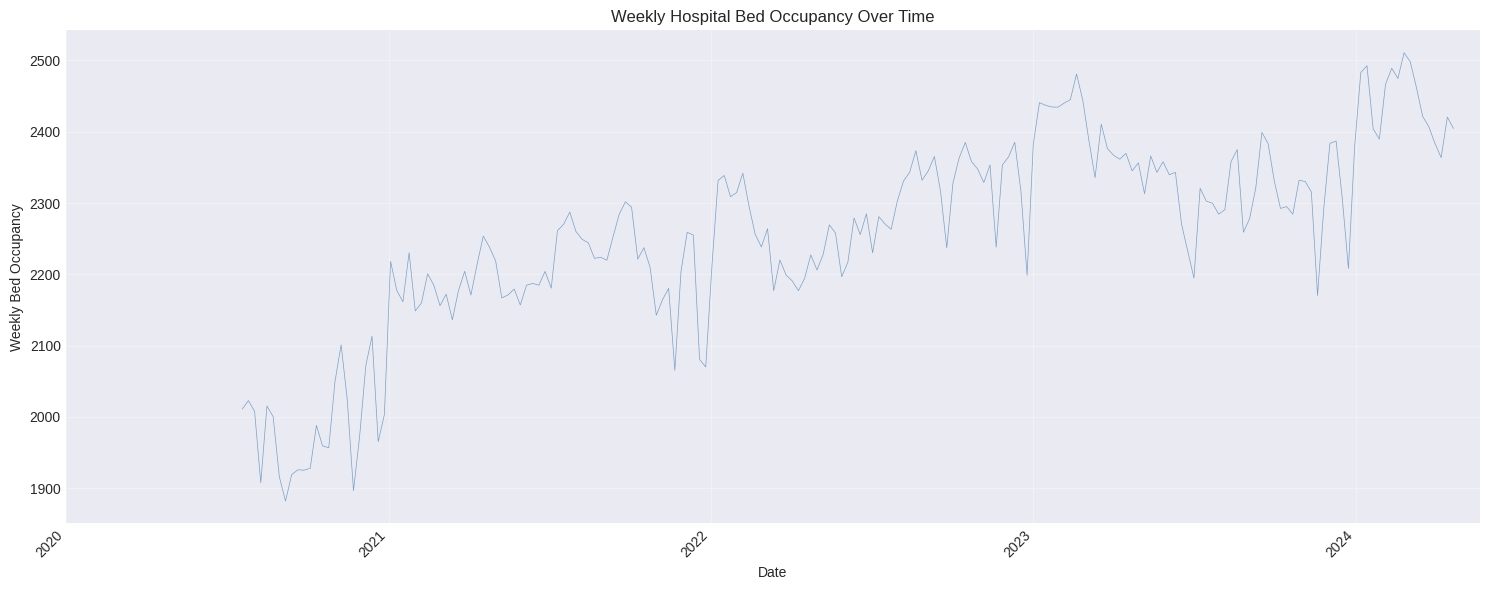

✓ Full time series plot saved



In [ ]:
# Plot full time series
if len(weekly_occupancy) > 0:
    print("\n" + "="*60)
    print("📈 FULL TIME SERIES VISUALIZATION")
    print("="*60)
    print(f"Plotting complete time series: {len(weekly_occupancy):,} weeks")
    print(f"Date range: {weekly_occupancy.index.min().date()} to {weekly_occupancy.index.max().date()}")
    calendar_weeks = (weekly_occupancy.index.max() - weekly_occupancy.index.min()).days // 7 + 1
    print(f"Calendar span: {calendar_weeks:,} weeks (from first to last date)")
    print(f"Actual data points: {len(weekly_occupancy):,} weeks (weekly data)")
    print(f"  Note: Weekly data aggregated to Sunday dates")

    data = weekly_occupancy['bed_occupancy']
    print(f"\nAdmissions statistics:")
    print(f"  Mean: {data.mean():.2f}")
    print(f"  Median: {data.median():.2f}")
    print(f"  Std: {data.std():.2f}")
    print(f"  Min: {data.min():.2f} (on {data.idxmin().date()})")
    print(f"  Max: {data.max():.2f} (on {data.idxmax().date()})")

    print("\n📊 Plot: Complete time series of weekly bed occupancy")
    print("   - Shows all weekly values without aggregation")
    print("   - Helps identify overall patterns, outliers, and data quality issues")
    print("   - Useful for spotting missing data periods or anomalies")

    plt.figure(figsize=(15, 6))
    plt.plot(weekly_occupancy.index, weekly_occupancy['bed_occupancy'], linewidth=0.5, alpha=0.7, color='steelblue')
    plt.title('Weekly Hospital Bed Occupancy Over Time')
    plt.xlabel('Date')
    plt.ylabel('Weekly Bed Occupancy')

    # Set x-axis to only show years with data (skip empty years)
    years_with_data = sorted(weekly_occupancy.index.year.unique())
    from matplotlib.ticker import NullLocator
    # Set xlim to actual data range with minimal padding to reduce empty space
    x_min = weekly_occupancy.index.min()
    x_max = weekly_occupancy.index.max()
    padding = pd.Timedelta(days=30)
    plt.gca().set_xlim(x_min - padding, x_max + padding)
    plt.gca().xaxis.set_major_locator(NullLocator())
    plt.gca().xaxis.set_minor_locator(NullLocator())
    plt.gca().set_xticks([pd.Timestamp(f'{year}-01-01') for year in years_with_data])
    plt.gca().set_xticklabels([str(year) for year in years_with_data], rotation=45, ha='right')

    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    save_plot('weekly_occupancy_timeseries.png')
    plt.show()

    print("✓ Full time series plot saved\n")

## Time Series Decomposition



🔍 TIME SERIES DECOMPOSITION
Decomposing time series into components using additive model (period=52 weeks)
   - Trend: Long-term direction of the series
   - Seasonal: Repeating patterns within a year (52-week cycle)
   - Residual: Random fluctuations after removing trend and seasonality
   - Observed: Original time series (Trend + Seasonal + Residual)

Component Statistics:
  Trend - Mean: 2257.51, Std: 93.22
  Seasonal - Mean: 0.90, Std: 55.85
  Residual - Mean: -4.05, Std: 50.29

  Seasonal Strength: 0.375
    → Moderate seasonal patterns

📊 Plot: 4-panel decomposition
   - Top: Observed (original data)
   - 2nd: Trend (long-term movement)
   - 3rd: Seasonal (yearly repeating pattern)
   - Bottom: Residual (noise/random variation)


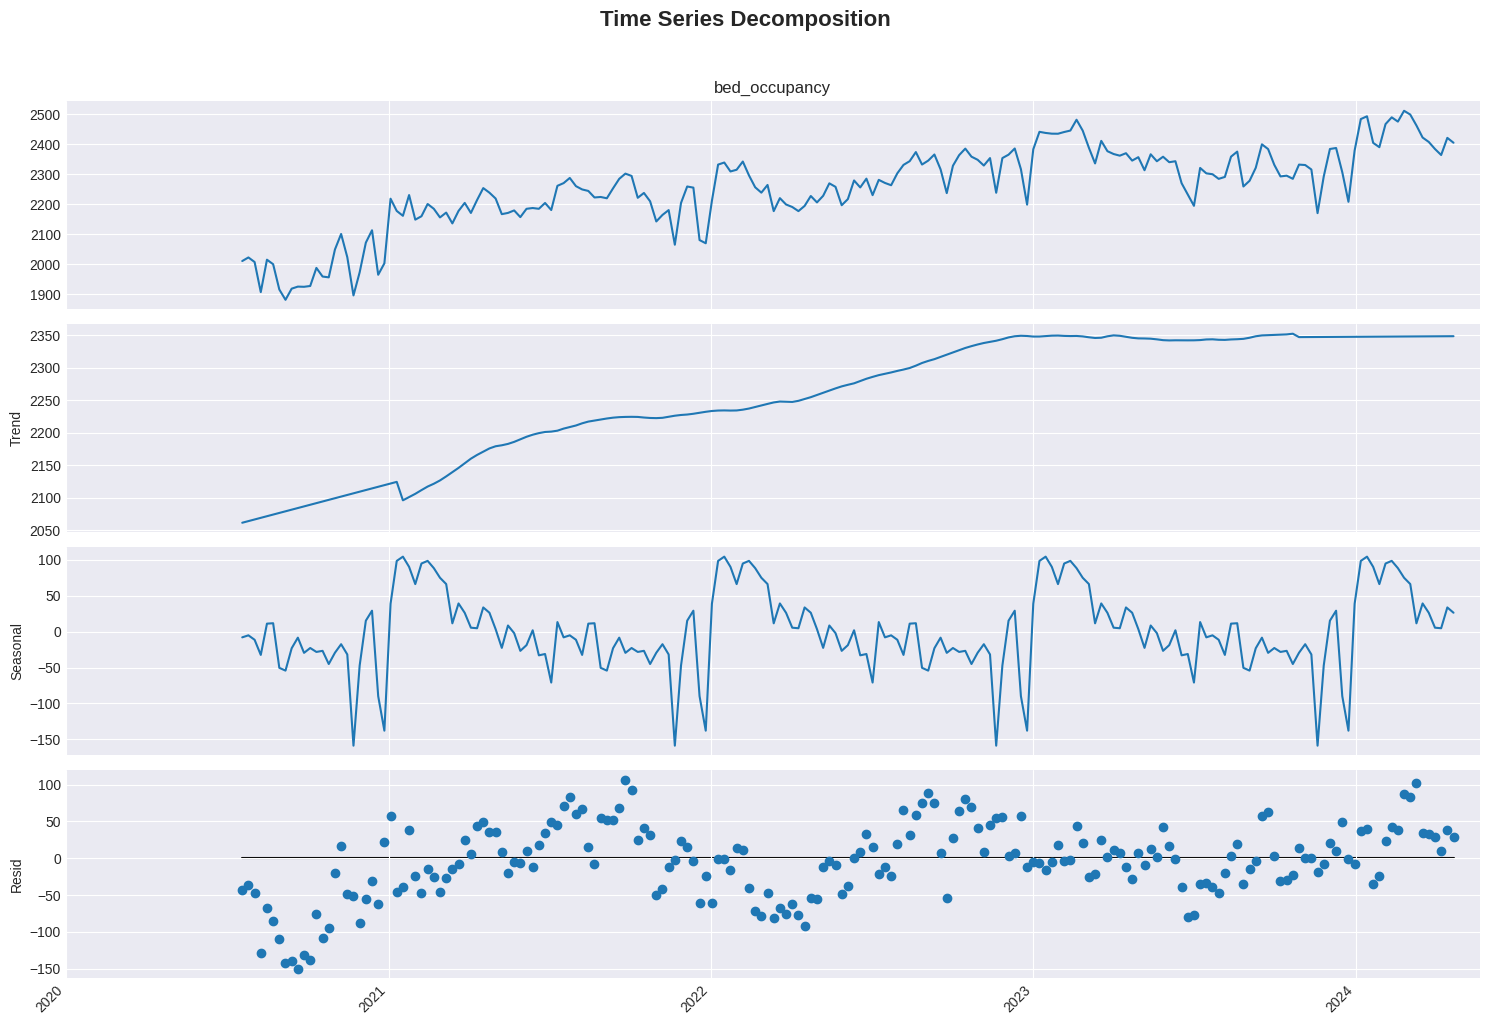


✓ Decomposition plot saved
   Note: Additive model assumes components add together: Observed = Trend + Seasonal + Residual



In [ ]:
# Time series decomposition
if len(weekly_occupancy) >= 52:
    print("\n" + "="*60)
    print("🔍 TIME SERIES DECOMPOSITION")
    print("="*60)
    print("Decomposing time series into components using additive model (period=52 weeks)")
    print("   - Trend: Long-term direction of the series")
    print("   - Seasonal: Repeating patterns within a year (52-week cycle)")
    print("   - Residual: Random fluctuations after removing trend and seasonality")
    print("   - Observed: Original time series (Trend + Seasonal + Residual)")

    try:
        decomposition = seasonal_decompose(weekly_occupancy['bed_occupancy'], model='additive', period=52, extrapolate_trend='freq')

        print("\nComponent Statistics:")
        print(f"  Trend - Mean: {decomposition.trend.mean():.2f}, Std: {decomposition.trend.std():.2f}")
        print(f"  Seasonal - Mean: {decomposition.seasonal.mean():.2f}, Std: {decomposition.seasonal.std():.2f}")
        print(f"  Residual - Mean: {decomposition.resid.mean():.2f}, Std: {decomposition.resid.std():.2f}")

        # Check if seasonal component is significant
        seasonal_strength = decomposition.seasonal.std() / (decomposition.trend.std() + decomposition.seasonal.std())
        print(f"\n  Seasonal Strength: {seasonal_strength:.3f}")
        if seasonal_strength > 0.4:
            print("    → Strong seasonal patterns detected")
        elif seasonal_strength > 0.1:
            print("    → Moderate seasonal patterns")
        else:
            print("    → Weak seasonal patterns")

        print("\n📊 Plot: 4-panel decomposition")
        print("   - Top: Observed (original data)")
        print("   - 2nd: Trend (long-term movement)")
        print("   - 3rd: Seasonal (yearly repeating pattern)")
        print("   - Bottom: Residual (noise/random variation)")

        fig = decomposition.plot()
        fig.set_size_inches(15, 10)
        plt.suptitle('Time Series Decomposition', fontsize=16, fontweight='bold', y=1.02)

                # Fix x-axis on all subplots to skip empty years and compress empty space
        years_with_data = sorted(weekly_occupancy.index.year.unique())
        from matplotlib.ticker import NullLocator
        year_ticks = [pd.Timestamp(f'{year}-01-01') for year in years_with_data]
        year_labels = [str(year) for year in years_with_data]

        # Set x-axis limits to actual data range with minimal padding (to reduce empty space)
        x_min = weekly_occupancy.index.min()
        x_max = weekly_occupancy.index.max()
        padding = pd.Timedelta(days=30)  # Small padding

        # decomposition.plot() creates 4 axes: observed, trend, seasonal, resid
        for ax in fig.axes:
            ax.set_xlim(x_min - padding, x_max + padding)
            ax.xaxis.set_major_locator(NullLocator())
            ax.xaxis.set_minor_locator(NullLocator())
            ax.set_xticks(year_ticks)
            ax.set_xticklabels(year_labels, rotation=45, ha='right')

        plt.tight_layout()
        save_plot('decomposition.png')
        plt.show()

        print("\n✓ Decomposition plot saved")
        print("   Note: Additive model assumes components add together: Observed = Trend + Seasonal + Residual\n")
    except Exception as e:
        print(f"❌ Decomposition failed: {e}")
        print(f"   Error type: {type(e).__name__}")
else:
    print(f"⚠️  Not enough data for decomposition (need 52+ weeks, have {len(weekly_occupancy)})")

## Seasonality Analysis - Week Number Patterns

**Note:** Day-of-week analysis is not applicable for this dataset because:
- Data is aggregated to **weekly frequency** (7-day averages)
- All dates are **Sundays** (week-ending dates)
- Instead, we analyze patterns by **week number** within the year



📅 WEEK NUMBER PATTERN ANALYSIS
Note: Day-of-week analysis is not applicable for weekly data (all dates are Sundays).
Instead, analyzing patterns by week number within the year.

Calculating average bed occupancy for each week number...

Week number statistics (selected weeks):
  Week  1: 2358.27 beds/week
  Week 10: 2277.65 beds/week
  Week 20: 2259.97 beds/week
  Week 30: 2217.47 beds/week
  Week 40: 2201.20 beds/week
  Week 52: 2244.00 beds/week

  Range: 247.75 (2110.53 to 2358.27)
  Coefficient of Variation: 0.025 (Weak seasonal pattern)
  Highest: Week 1 (2358.27)
  Lowest: Week 51 (2110.53)
  Difference: 247.75 (11.0% of mean)

📊 Plot: Line chart showing average bed occupancy by week number
   - Helps identify annual seasonal patterns
   - Useful for understanding if week-of-year features will be valuable for modeling


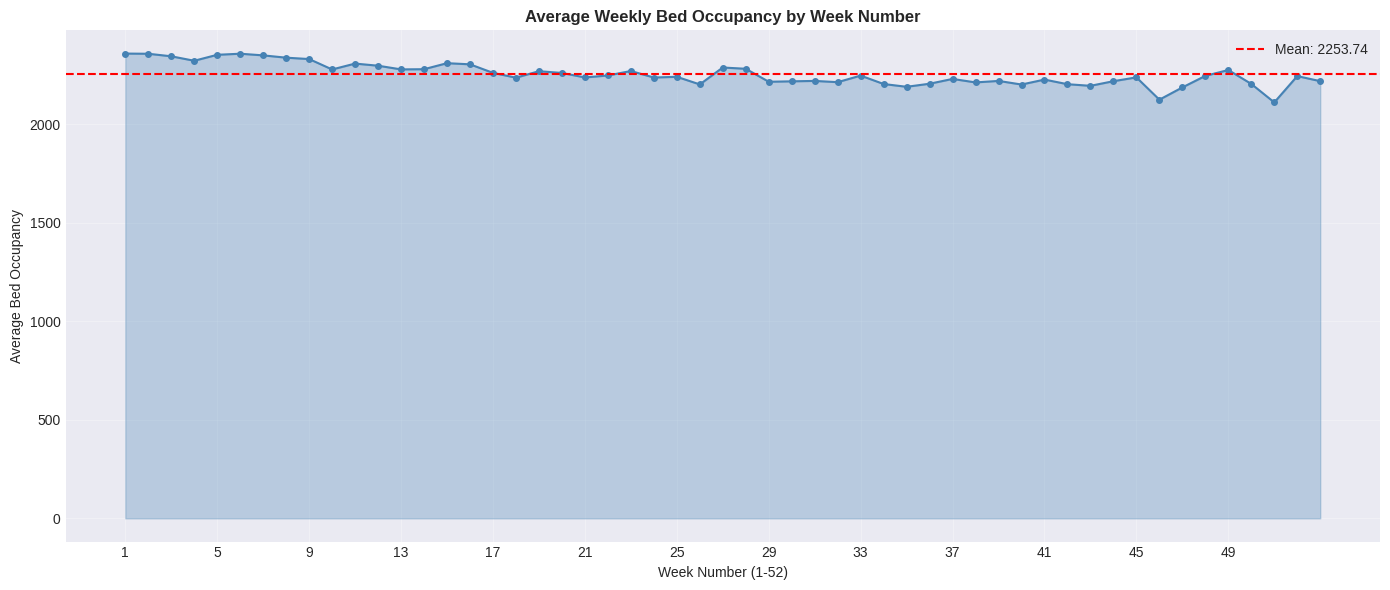


Week number averages (first and last 5 weeks):
First 5 weeks: {np.uint32(1): 2358.2749999999996, np.uint32(2): 2357.35, np.uint32(3): 2344.475, np.uint32(4): 2321.8, np.uint32(5): 2352.075}
Last 5 weeks: {np.uint32(49): 2274.85, np.uint32(50): 2204.2, np.uint32(51): 2110.525, np.uint32(52): 2244.0, np.uint32(53): 2218.3}

✓ Week number pattern plot saved



In [ ]:
# Week number patterns (replaces day-of-week analysis which is not applicable for weekly data)
if len(weekly_occupancy) > 0:
    print("\n" + "="*60)
    print("📅 WEEK NUMBER PATTERN ANALYSIS")
    print("="*60)

    print("Note: Day-of-week analysis is not applicable for weekly data (all dates are Sundays).")
    print("Instead, analyzing patterns by week number within the year.\n")

    # Group by week number (1-52)
    weekly_occupancy_copy = weekly_occupancy.copy()
    weekly_occupancy_copy['week_num'] = weekly_occupancy_copy.index.isocalendar().week

    week_avg = weekly_occupancy_copy.groupby('week_num')['bed_occupancy'].mean()

    print("Calculating average bed occupancy for each week number...")
    print(f"\nWeek number statistics (selected weeks):")
    for week in [1, 10, 20, 30, 40, 52]:
        if week in week_avg.index:
            print(f"  Week {week:2d}: {week_avg[week]:6.2f} beds/week")

    week_range = week_avg.max() - week_avg.min()
    week_cv = week_avg.std() / week_avg.mean()
    print(f"\n  Range: {week_range:.2f} ({week_avg.min():.2f} to {week_avg.max():.2f})")
    print(f"  Coefficient of Variation: {week_cv:.3f} ({'Strong' if week_cv > 0.1 else 'Moderate' if week_cv > 0.05 else 'Weak'} seasonal pattern)")

    highest_week = week_avg.idxmax()
    lowest_week = week_avg.idxmin()
    print(f"  Highest: Week {highest_week} ({week_avg.max():.2f})")
    print(f"  Lowest: Week {lowest_week} ({week_avg.min():.2f})")
    print(f"  Difference: {week_avg.max() - week_avg.min():.2f} ({100*(week_avg.max() - week_avg.min())/week_avg.mean():.1f}% of mean)")

    print("\n📊 Plot: Line chart showing average bed occupancy by week number")
    print("   - Helps identify annual seasonal patterns")
    print("   - Useful for understanding if week-of-year features will be valuable for modeling")

    plt.figure(figsize=(14, 6))
    plt.plot(week_avg.index, week_avg.values, marker='o', markersize=4, linewidth=1.5, color='steelblue')
    plt.fill_between(week_avg.index, week_avg.values, alpha=0.3, color='steelblue')
    plt.axhline(y=week_avg.mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean: {week_avg.mean():.2f}')
    plt.title('Average Weekly Bed Occupancy by Week Number', fontsize=12, fontweight='bold')
    plt.xlabel('Week Number (1-52)')
    plt.ylabel('Average Bed Occupancy')
    plt.xticks(range(1, 53, 4))
    plt.grid(axis='both', alpha=0.3)
    plt.legend()
    plt.tight_layout()
    save_plot('week_number_pattern.png')
    plt.show()

    print(f"\nWeek number averages (first and last 5 weeks):")
    print("First 5 weeks:", dict(list(week_avg.head().items())))
    print("Last 5 weeks:", dict(list(week_avg.tail().items())))
    print("\n✓ Week number pattern plot saved\n")

## Seasonality Analysis - Monthly Patterns


📅 MONTHLY PATTERN ANALYSIS
Calculating average bed occupancy for each month...

Monthly statistics:
  Jan (Month  1): 2333.68 beds/week
  Feb (Month  2): 2349.06 beds/week
  Mar (Month  3): 2307.81 beds/week
  Apr (Month  4): 2290.87 beds/week
  May (Month  5): 2245.04 beds/week
  Jun (Month  6): 2248.50 beds/week
  Jul (Month  7): 2236.40 beds/week
  Aug (Month  8): 2206.04 beds/week
  Sep (Month  9): 2209.70 beds/week
  Oct (Month 10): 2223.85 beds/week
  Nov (Month 11): 2178.79 beds/week
  Dec (Month 12): 2220.44 beds/week

  Range: 170.26 (2178.79 to 2349.06)
  Coefficient of Variation: 0.024 (Weak monthly seasonality)
  Highest: Feb (Month 2, 2349.06)
  Lowest: Nov (Month 11, 2178.79)
  Difference: 170.26 (7.6% of mean)

  Seasonal averages:
    Spring (Mar-May): 2281.24
    Summer (Jun-Aug): 2230.31
    Fall (Sep-Nov): 2204.11
    Winter (Dec-Feb): 2301.06

📊 Plot: Bar chart showing average bed occupancy per month
   - Helps identify monthly/seasonal patterns
   - Useful for und

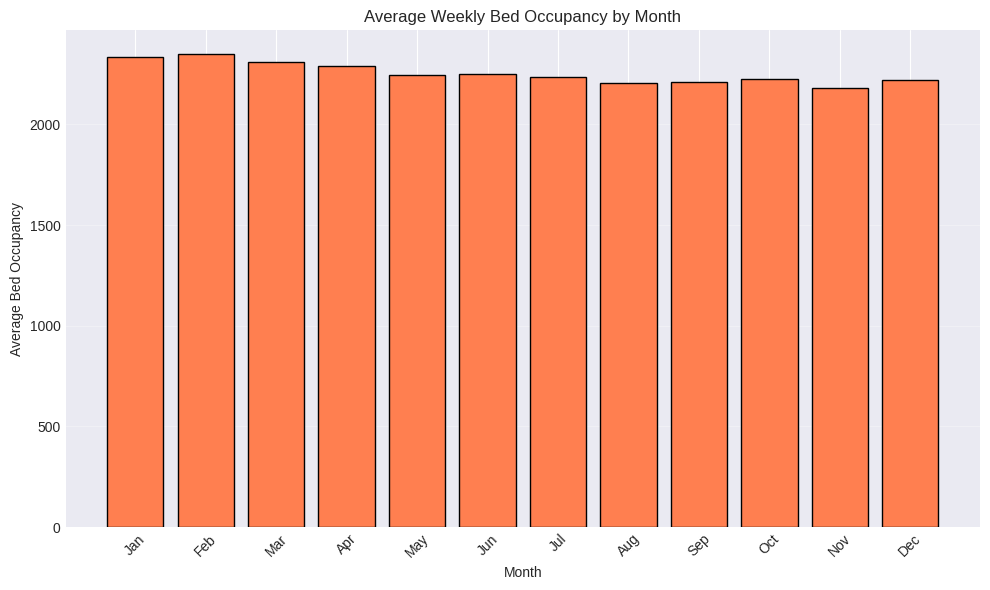


Monthly averages (detailed):
date
1     2333.678947
2     2349.056250
3     2307.805882
4     2290.868750
5     2245.035714
6     2248.500000
7     2236.400000
8     2206.038889
9     2209.700000
10    2223.847368
11    2178.794118
12    2220.441176
Name: bed_occupancy, dtype: float64

✓ Monthly pattern plot saved


🌤️  WEATHER SEASONALITY AND ADMISSIONS

📊 Creating weather seasonality analysis:
   This analysis will show how temperature patterns align with admissions patterns
   We expect to see:
     • Temperature follows annual cycle (low in winter, high in summer)
     • Whether admissions peak during same seasons as temperature extremes
     • Relationship strength between temperature and admissions

📈 Monthly Patterns:
   Comparing average temperature and admissions by month


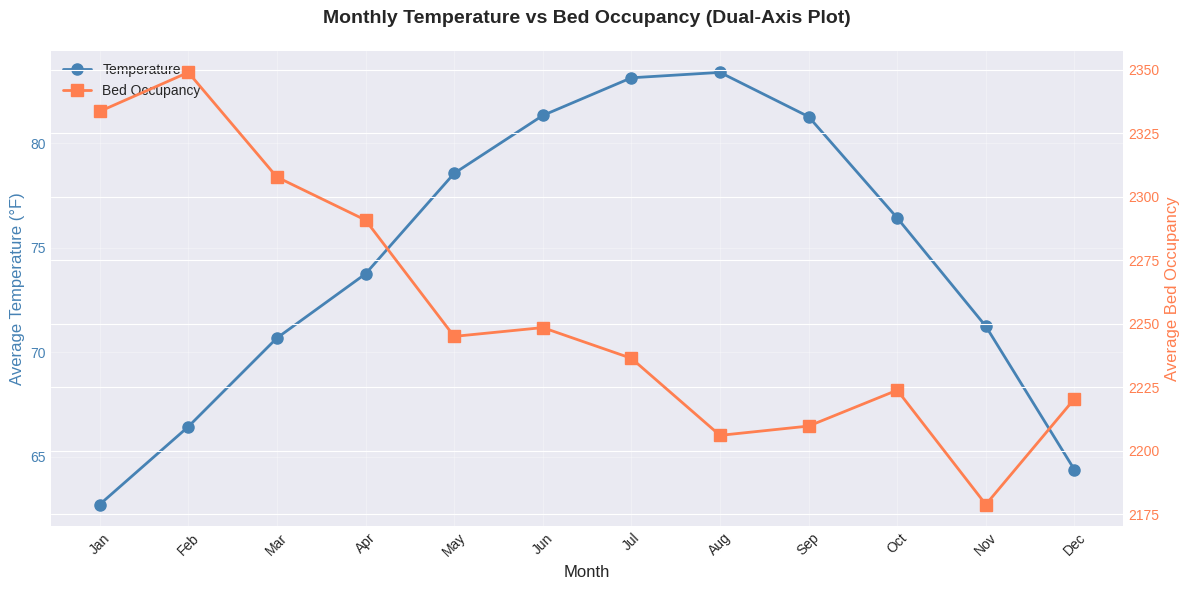

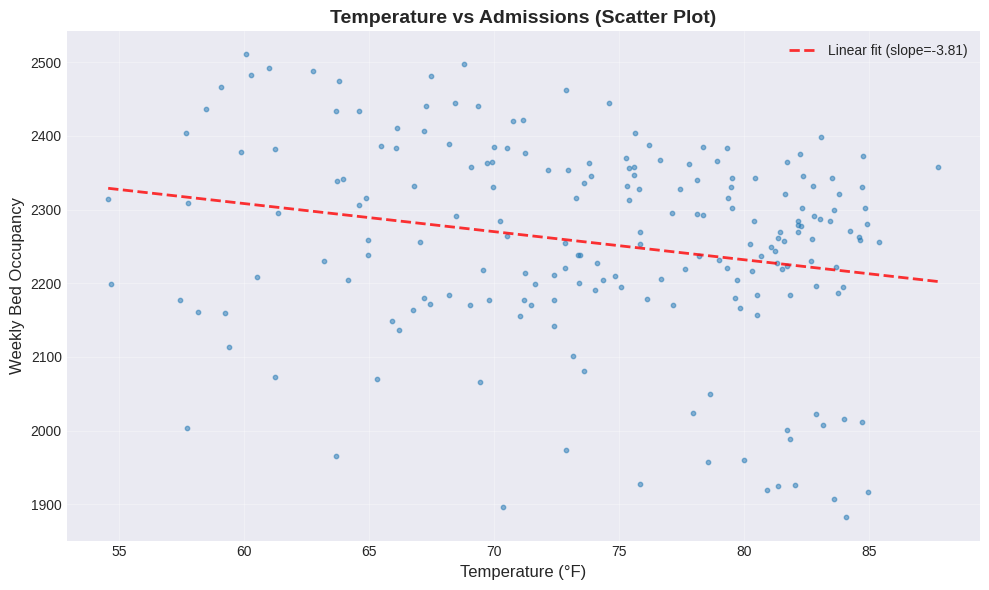


🔍 Weather Seasonality Analysis:

Temperature Seasonality:
   Coldest month: Jan (Month 1, 62.7°F)
   Warmest month: Aug (Month 8, 83.4°F)
   Temperature range: 20.7°F

Admissions Seasonality (for comparison):
   Lowest admissions month: Nov (Month 11, 2178.79)
   Highest admissions month: Feb (Month 2, 2349.06)

Relationship Analysis:
   Temperature-Admissions correlation: -0.221
     → Moderate correlation
     → Temperature peaks in Aug, admissions peak in Feb

Admissions by Temperature Category:
   Cold : Mean=2297.63, Count=50 weeks
   Cool : Mean=2262.74, Count=49 weeks
   Warm : Mean=2244.32, Count=49 weeks
   Hot  : Mean=2211.89, Count=49 weeks

✓ Weather seasonality analysis complete
   Visualizations saved: weather_seasonality.png, temp_vs_admissions_scatter.png


🦠 FLU SEASONALITY AND ADMISSIONS

📊 Creating flu seasonality analysis:
   This analysis will show how flu activity patterns align with admissions patterns
   We expect to see:
     • Flu activity peaks during winter

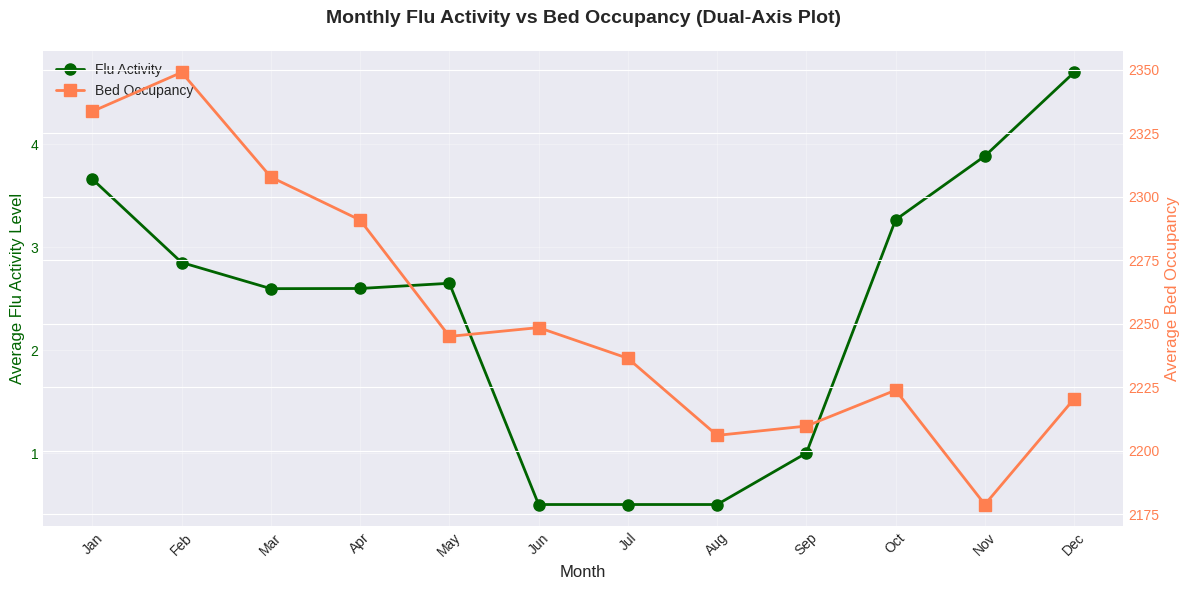

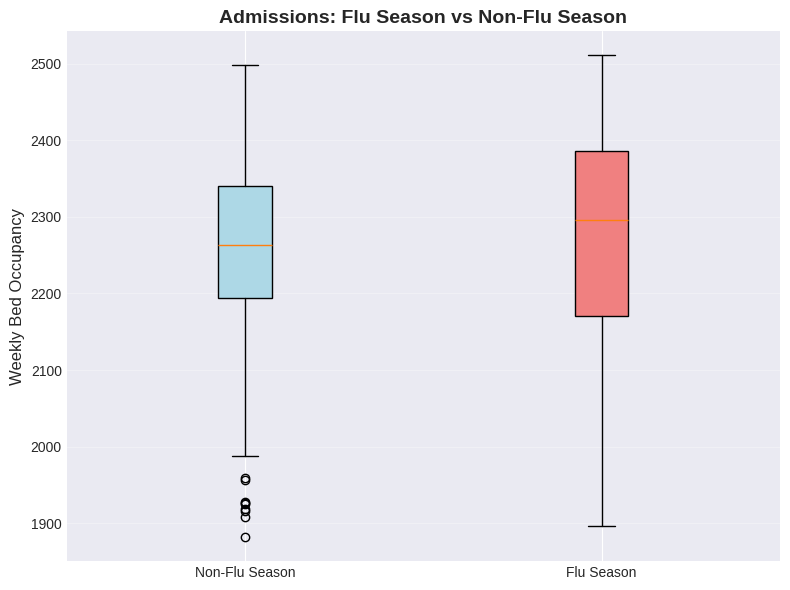


🔍 Flu Seasonality Analysis:

Flu Activity Seasonality:
   Lowest flu month: Jun (Month 6, 0.50)
   Highest flu month: Dec (Month 12, 4.70)
   Flu activity range: 4.20 (scale 0-10)

Admissions Seasonality (for comparison):
   Lowest admissions month: Nov (Month 11, 2178.79)
   Highest admissions month: Feb (Month 2, 2349.06)

Relationship Analysis:
   Flu-Admissions correlation: 0.385
     → Strong correlation (|r| > 0.3)
     → Admissions peak 2 month(s) after flu peak (potential lag)

Flu Season vs Non-Flu Season:
   Non-flu season mean admissions: 2245.30
   Flu season mean admissions: 2271.19
   Difference: +25.88 (+1.2%)
     → Admissions are higher during flu season

✓ Flu seasonality analysis complete
   Visualizations saved: flu_seasonality.png, flu_season_boxplot.png


🔗 CROSS-CORRELATION: LAGGED RELATIONSHIPS

📊 Creating cross-correlation analysis:
   This shows how correlations change at different time lags
   Positive lag = feature leads (predictive), Negative lag = feature

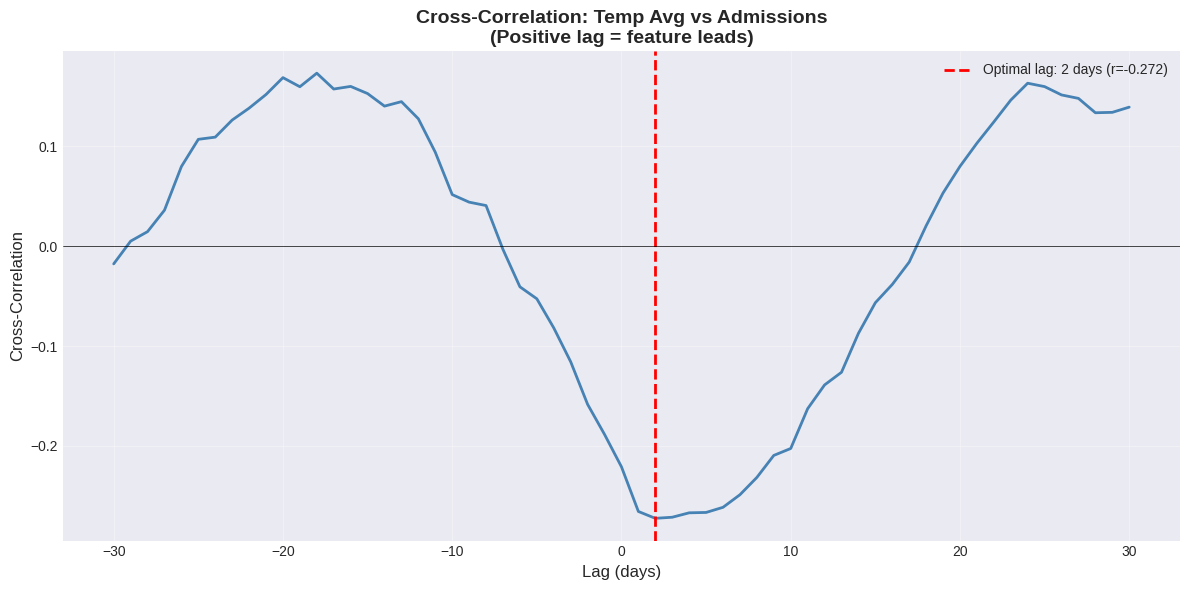

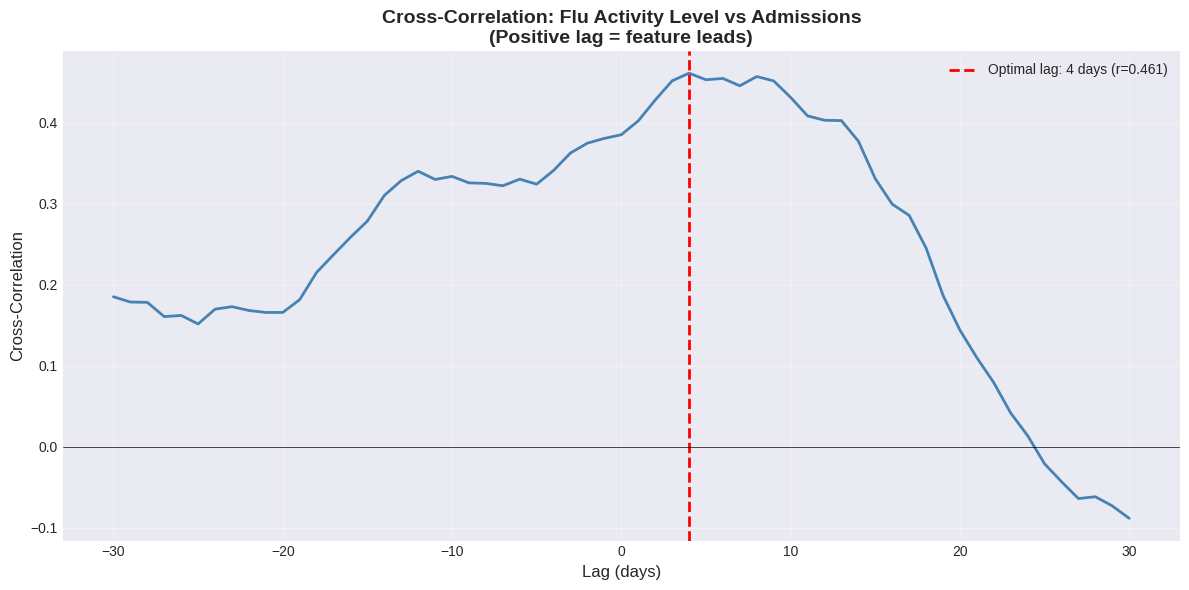

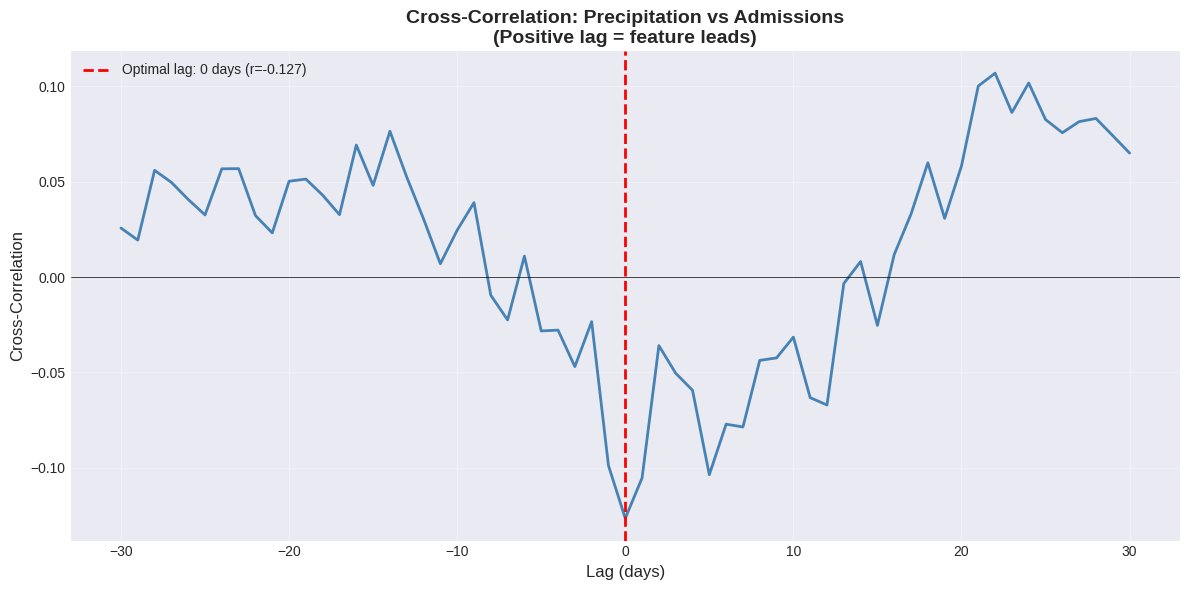


🔍 Optimal Lags Summary:
----------------------------------------------------------------------
Feature                        Optimal Lag     Correlation     Type                
----------------------------------------------------------------------
temp_avg                                    0 weeks         -0.221 Simultaneous        
temp_max                                    0 weeks         -0.178 Simultaneous        
temp_min                                    0 weeks         -0.254 Simultaneous        
precipitation                               0 weeks         -0.127 Simultaneous        
wind_speed                                -15 weeks         -0.198 Lagging (Reactive)  
pressure                                  -18 weeks         -0.135 Lagging (Reactive)  
flu_activity_level                          0 weeks          0.385 Simultaneous        
wili                                        0 weeks          0.385 Simultaneous        
ili                                         0

In [ ]:
# Monthly patterns
if len(weekly_occupancy) > 0:
    print("\n" + "="*60)
    print("📅 MONTHLY PATTERN ANALYSIS")
    print("="*60)

    month_avg = weekly_occupancy.groupby(weekly_occupancy.index.month)['bed_occupancy'].mean()
    month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

    print("Calculating average bed occupancy for each month...")
    print(f"\nMonthly statistics:")
    for month_num in range(1, 13):
        month_name = month_names[month_num - 1]
        print(f"  {month_name:3s} (Month {month_num:2d}): {month_avg[month_num]:6.2f} beds/week")

    month_range = month_avg.max() - month_avg.min()
    month_cv = month_avg.std() / month_avg.mean()
    print(f"\n  Range: {month_range:.2f} ({month_avg.min():.2f} to {month_avg.max():.2f})")
    print(f"  Coefficient of Variation: {month_cv:.3f} ({'Strong' if month_cv > 0.1 else 'Weak'} monthly seasonality)")

    highest_month = month_avg.idxmax()
    lowest_month = month_avg.idxmin()
    print(f"  Highest: {month_names[highest_month-1]} (Month {highest_month}, {month_avg.max():.2f})")
    print(f"  Lowest: {month_names[lowest_month-1]} (Month {lowest_month}, {month_avg.min():.2f})")
    print(f"  Difference: {month_avg.max() - month_avg.min():.2f} ({100*(month_avg.max() - month_avg.min())/month_avg.mean():.1f}% of mean)")

    # Identify seasonal patterns
    spring_avg = month_avg[[3, 4, 5]].mean()
    summer_avg = month_avg[[6, 7, 8]].mean()
    fall_avg = month_avg[[9, 10, 11]].mean()
    winter_avg = month_avg[[12, 1, 2]].mean()
    print(f"\n  Seasonal averages:")
    print(f"    Spring (Mar-May): {spring_avg:.2f}")
    print(f"    Summer (Jun-Aug): {summer_avg:.2f}")
    print(f"    Fall (Sep-Nov): {fall_avg:.2f}")
    print(f"    Winter (Dec-Feb): {winter_avg:.2f}")

    print("\n📊 Plot: Bar chart showing average bed occupancy per month")
    print("   - Helps identify monthly/seasonal patterns")
    print("   - Useful for understanding if monthly features will be valuable for modeling")

    plt.figure(figsize=(10, 6))
    plt.bar(range(1, 13), month_avg.values, color='coral', edgecolor='black')
    plt.xticks(range(1, 13), month_names, rotation=45)
    plt.title('Average Weekly Bed Occupancy by Month')
    plt.xlabel('Month')
    plt.ylabel('Average Bed Occupancy')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    save_plot('monthly_pattern.png')
    plt.show()

    print(f"\nMonthly averages (detailed):")
    print(month_avg)
    print("\n✓ Monthly pattern plot saved\n")

# ============================================================================
# SECTION 4: WEATHER SEASONALITY ANALYSIS
# ============================================================================
if len(data_with_external) > 0 and 'bed_occupancy' in data_with_external.columns and 'temp_avg' in data_with_external.columns:
    print("\n" + "="*70)
    print("🌤️  WEATHER SEASONALITY AND ADMISSIONS")
    print("="*70)

    print("\n📊 Creating weather seasonality analysis:")
    print("   This analysis will show how temperature patterns align with admissions patterns")
    print("   We expect to see:")
    print("     • Temperature follows annual cycle (low in winter, high in summer)")
    print("     • Whether admissions peak during same seasons as temperature extremes")
    print("     • Relationship strength between temperature and admissions")

    # Temperature vs Admissions by month
    temp_monthly = data_with_external.groupby(data_with_external.index.month)['temp_avg'].mean()
    adm_monthly = data_with_external.groupby(data_with_external.index.month)['bed_occupancy'].mean()

    month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

    print(f"\n📈 Monthly Patterns:")
    print(f"   Comparing average temperature and admissions by month")

    # Dual-axis plot
    fig, ax1 = plt.subplots(figsize=(12, 6))

    color1 = 'steelblue'
    ax1.set_xlabel('Month', fontsize=12)
    ax1.set_ylabel('Average Temperature (°F)', color=color1, fontsize=12)
    line1 = ax1.plot(range(1, 13), temp_monthly.values, color=color1, marker='o', linewidth=2, markersize=8, label='Temperature')
    ax1.tick_params(axis='y', labelcolor=color1)
    ax1.set_xticks(range(1, 13))
    ax1.set_xticklabels(month_names, rotation=45)
    ax1.grid(True, alpha=0.3)

    ax2 = ax1.twinx()
    color2 = 'coral'
    ax2.set_ylabel('Average Bed Occupancy', color=color2, fontsize=12)
    line2 = ax2.plot(range(1, 13), adm_monthly.values, color=color2, marker='s', linewidth=2, markersize=8, label='Bed Occupancy')
    ax2.tick_params(axis='y', labelcolor=color2)

    plt.title('Monthly Temperature vs Bed Occupancy (Dual-Axis Plot)', fontsize=14, fontweight='bold', pad=20)

    # Add legend
    lines = line1 + line2
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='upper left')

    plt.tight_layout()
    save_plot('weather_seasonality.png')
    plt.show()

    # Scatter plot: Temperature vs Admissions
    plt.figure(figsize=(10, 6))
    plt.scatter(data_with_external['temp_avg'], data_with_external['bed_occupancy'], alpha=0.5, s=10)
    plt.xlabel('Temperature (°F)', fontsize=12)
    plt.ylabel('Weekly Bed Occupancy', fontsize=12)
    plt.title('Temperature vs Admissions (Scatter Plot)', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)

    # Add correlation line
    z = np.polyfit(data_with_external['temp_avg'].dropna(),
                   data_with_external.loc[data_with_external['temp_avg'].dropna().index, 'bed_occupancy'], 1)
    p = np.poly1d(z)
    plt.plot(data_with_external['temp_avg'].dropna().sort_values(),
             p(data_with_external['temp_avg'].dropna().sort_values()),
             "r--", alpha=0.8, linewidth=2, label=f'Linear fit (slope={z[0]:.2f})')
    plt.legend()

    plt.tight_layout()
    save_plot('temp_vs_admissions_scatter.png')
    plt.show()

    # Correlation
    temp_adm_corr = data_with_external['temp_avg'].corr(data_with_external['bed_occupancy'])

    print("\n🔍 Weather Seasonality Analysis:")
    print(f"\nTemperature Seasonality:")
    print(f"   Coldest month: {month_names[temp_monthly.idxmin() - 1]} (Month {temp_monthly.idxmin()}, {temp_monthly.min():.1f}°F)")
    print(f"   Warmest month: {month_names[temp_monthly.idxmax() - 1]} (Month {temp_monthly.idxmax()}, {temp_monthly.max():.1f}°F)")
    print(f"   Temperature range: {temp_monthly.max() - temp_monthly.min():.1f}°F")

    print(f"\nAdmissions Seasonality (for comparison):")
    print(f"   Lowest admissions month: {month_names[adm_monthly.idxmin() - 1]} (Month {adm_monthly.idxmin()}, {adm_monthly.min():.2f})")
    print(f"   Highest admissions month: {month_names[adm_monthly.idxmax() - 1]} (Month {adm_monthly.idxmax()}, {adm_monthly.max():.2f})")

    print(f"\nRelationship Analysis:")
    print(f"   Temperature-Admissions correlation: {temp_adm_corr:.3f}")
    if abs(temp_adm_corr) > 0.3:
        print(f"     → Strong correlation (|r| > 0.3)")
    elif abs(temp_adm_corr) > 0.15:
        print(f"     → Moderate correlation")
    else:
        print(f"     → Weak correlation")

    # Check alignment
    temp_peak_month = temp_monthly.idxmax()
    adm_peak_month = adm_monthly.idxmax()
    if temp_peak_month == adm_peak_month:
        print(f"     → Temperature and admissions peak in same month ({month_names[temp_peak_month - 1]})")
    else:
        print(f"     → Temperature peaks in {month_names[temp_peak_month - 1]}, admissions peak in {month_names[adm_peak_month - 1]}")

    # Temperature quartiles analysis
    temp_quartiles = data_with_external['temp_avg'].quantile([0.25, 0.5, 0.75])
    data_with_external['temp_category'] = pd.cut(data_with_external['temp_avg'],
                                                   bins=[-np.inf, temp_quartiles[0.25], temp_quartiles[0.5],
                                                         temp_quartiles[0.75], np.inf],
                                                   labels=['Cold', 'Cool', 'Warm', 'Hot'])

    print(f"\nAdmissions by Temperature Category:")
    for cat in ['Cold', 'Cool', 'Warm', 'Hot']:
        cat_data = data_with_external[data_with_external['temp_category'] == cat]['bed_occupancy']
        if len(cat_data) > 0:
            print(f"   {cat:5s}: Mean={cat_data.mean():.2f}, Count={len(cat_data):,} weeks")

    print("\n✓ Weather seasonality analysis complete")
    print("   Visualizations saved: weather_seasonality.png, temp_vs_admissions_scatter.png\n")
else:
    print("ℹ️  Weather data not available for seasonality analysis")

# ============================================================================
# SECTION 5: FLU SEASONALITY ANALYSIS
# ============================================================================
if len(data_with_external) > 0 and 'bed_occupancy' in data_with_external.columns and 'flu_activity_level' in data_with_external.columns:
    print("\n" + "="*70)
    print("🦠 FLU SEASONALITY AND ADMISSIONS")
    print("="*70)

    print("\n📊 Creating flu seasonality analysis:")
    print("   This analysis will show how flu activity patterns align with admissions patterns")
    print("   We expect to see:")
    print("     • Flu activity peaks during winter/spring (typical flu season)")
    print("     • Whether admissions increase during flu season")
    print("     • Lag relationship (do admissions peak after flu peaks?)")

    # Flu activity by month
    flu_monthly = data_with_external.groupby(data_with_external.index.month)['flu_activity_level'].mean()
    adm_monthly = data_with_external.groupby(data_with_external.index.month)['bed_occupancy'].mean()

    print(f"\n📈 Monthly Patterns:")
    print(f"   Comparing average flu activity and admissions by month")

    # Dual-axis plot
    fig, ax1 = plt.subplots(figsize=(12, 6))

    color1 = 'darkgreen'
    ax1.set_xlabel('Month', fontsize=12)
    ax1.set_ylabel('Average Flu Activity Level', color=color1, fontsize=12)
    line1 = ax1.plot(range(1, 13), flu_monthly.values, color=color1, marker='o', linewidth=2, markersize=8, label='Flu Activity')
    ax1.tick_params(axis='y', labelcolor=color1)
    ax1.set_xticks(range(1, 13))
    ax1.set_xticklabels(month_names, rotation=45)
    ax1.grid(True, alpha=0.3)

    ax2 = ax1.twinx()
    color2 = 'coral'
    ax2.set_ylabel('Average Bed Occupancy', color=color2, fontsize=12)
    line2 = ax2.plot(range(1, 13), adm_monthly.values, color=color2, marker='s', linewidth=2, markersize=8, label='Bed Occupancy')
    ax2.tick_params(axis='y', labelcolor=color2)

    plt.title('Monthly Flu Activity vs Bed Occupancy (Dual-Axis Plot)', fontsize=14, fontweight='bold', pad=20)

    # Add legend
    lines = line1 + line2
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='upper left')

    plt.tight_layout()
    save_plot('flu_seasonality.png')
    plt.show()

    # Box plot: Admissions during flu season vs non-flu season
    if 'is_flu_season' in data_with_external.columns:
        fig, ax = plt.subplots(figsize=(8, 6))
        flu_season_data = [data_with_external[data_with_external['is_flu_season'] == False]['bed_occupancy'].dropna(),
                          data_with_external[data_with_external['is_flu_season'] == True]['bed_occupancy'].dropna()]
        bp = ax.boxplot(flu_season_data, labels=['Non-Flu Season', 'Flu Season'], patch_artist=True)
        bp['boxes'][0].set_facecolor('lightblue')
        bp['boxes'][1].set_facecolor('lightcoral')
        ax.set_ylabel('Weekly Bed Occupancy', fontsize=12)
        ax.set_title('Admissions: Flu Season vs Non-Flu Season', fontsize=14, fontweight='bold')
        ax.grid(True, alpha=0.3, axis='y')
        plt.tight_layout()
        save_plot('flu_season_boxplot.png')
        plt.show()

    # Correlation
    flu_adm_corr = data_with_external['flu_activity_level'].corr(data_with_external['bed_occupancy'])

    print("\n🔍 Flu Seasonality Analysis:")
    print(f"\nFlu Activity Seasonality:")
    print(f"   Lowest flu month: {month_names[flu_monthly.idxmin() - 1]} (Month {flu_monthly.idxmin()}, {flu_monthly.min():.2f})")
    print(f"   Highest flu month: {month_names[flu_monthly.idxmax() - 1]} (Month {flu_monthly.idxmax()}, {flu_monthly.max():.2f})")
    print(f"   Flu activity range: {flu_monthly.max() - flu_monthly.min():.2f} (scale 0-10)")

    print(f"\nAdmissions Seasonality (for comparison):")
    print(f"   Lowest admissions month: {month_names[adm_monthly.idxmin() - 1]} (Month {adm_monthly.idxmin()}, {adm_monthly.min():.2f})")
    print(f"   Highest admissions month: {month_names[adm_monthly.idxmax() - 1]} (Month {adm_monthly.idxmax()}, {adm_monthly.max():.2f})")

    print(f"\nRelationship Analysis:")
    print(f"   Flu-Admissions correlation: {flu_adm_corr:.3f}")
    if abs(flu_adm_corr) > 0.3:
        print(f"     → Strong correlation (|r| > 0.3)")
    elif abs(flu_adm_corr) > 0.15:
        print(f"     → Moderate correlation")
    else:
        print(f"     → Weak correlation")

    # Check alignment
    flu_peak_month = flu_monthly.idxmax()
    adm_peak_month = adm_monthly.idxmax()
    month_diff = (adm_peak_month - flu_peak_month) % 12
    if month_diff == 0:
        print(f"     → Flu and admissions peak in same month ({month_names[flu_peak_month - 1]})")
    elif month_diff <= 2:
        print(f"     → Admissions peak {month_diff} month(s) after flu peak (potential lag)")
    else:
        print(f"     → Flu peaks in {month_names[flu_peak_month - 1]}, admissions peak in {month_names[adm_peak_month - 1]}")

    # Flu season comparison
    if 'is_flu_season' in data_with_external.columns:
        non_flu_adm = data_with_external[data_with_external['is_flu_season'] == False]['bed_occupancy'].mean()
        flu_adm = data_with_external[data_with_external['is_flu_season'] == True]['bed_occupancy'].mean()
        diff = flu_adm - non_flu_adm
        pct_diff = (diff / non_flu_adm) * 100

        print(f"\nFlu Season vs Non-Flu Season:")
        print(f"   Non-flu season mean admissions: {non_flu_adm:.2f}")
        print(f"   Flu season mean admissions: {flu_adm:.2f}")
        print(f"   Difference: {diff:+.2f} ({pct_diff:+.1f}%)")
        if diff > 0:
            print(f"     → Admissions are higher during flu season")
        else:
            print(f"     → Admissions are lower during flu season")

    print("\n✓ Flu seasonality analysis complete")
    print("   Visualizations saved: flu_seasonality.png, flu_season_boxplot.png\n")
else:
    print("ℹ️  Flu data not available for seasonality analysis")

# ============================================================================
# SECTION 6: CROSS-CORRELATION ANALYSIS (LAGGED RELATIONSHIPS)
# ============================================================================
if len(data_with_external) > 0 and 'bed_occupancy' in data_with_external.columns and len(EXTERNAL_FEATURES) > 0:
    print("\n" + "="*70)
    print("🔗 CROSS-CORRELATION: LAGGED RELATIONSHIPS")
    print("="*70)

    print("\n📊 Creating cross-correlation analysis:")
    print("   This shows how correlations change at different time lags")
    print("   Positive lag = feature leads (predictive), Negative lag = feature lags (reactive)")
    print("   Optimal lag = lag where correlation is strongest")
    print("   Key things to look for:")
    print("     • Peak correlation and its lag")
    print("     • Whether features are leading (predictive) or lagging (reactive)")
    print("     • Lag window where correlation remains strong")

    admissions_series = data_with_external['bed_occupancy'].dropna()
    max_lag = 30  # Analyze lags from -30 to +30 days

    print(f"\n📈 Cross-Correlation Analysis:")
    print(f"   Analyzing lags from -{max_lag} to +{max_lag} weeks")
    print(f"   Data points: {len(admissions_series):,} weeks")

    # Select key features for detailed cross-correlation
    key_features = []
    if 'temp_avg' in EXTERNAL_FEATURES:
        key_features.append('temp_avg')
    if 'flu_activity_level' in EXTERNAL_FEATURES:
        key_features.append('flu_activity_level')
    if 'precipitation' in EXTERNAL_FEATURES:
        key_features.append('precipitation')

    # Calculate cross-correlations for key features
    optimal_lags = {}

    for feat in key_features[:3]:  # Limit to 3 features for detailed plots
        feat_series = data_with_external[feat].dropna()

        # Align indices
        common_idx = admissions_series.index.intersection(feat_series.index)
        adm_aligned = admissions_series.loc[common_idx].values
        feat_aligned = feat_series.loc[common_idx].values

        if len(adm_aligned) < max_lag * 2:
            continue

        # Calculate cross-correlation
        cross_corr = signal.correlate(adm_aligned - np.mean(adm_aligned),
                                      feat_aligned - np.mean(feat_aligned),
                                      mode='full')
        lags = signal.correlation_lags(len(adm_aligned), len(feat_aligned), mode='full')

        # Normalize
        cross_corr = cross_corr / (np.std(adm_aligned) * np.std(feat_aligned) * len(adm_aligned))

        # Filter to desired lag range
        mask = (lags >= -max_lag) & (lags <= max_lag)
        lags_filtered = lags[mask]
        cross_corr_filtered = cross_corr[mask]

        # Find optimal lag
        optimal_lag_idx = np.argmax(np.abs(cross_corr_filtered))
        optimal_lag = lags_filtered[optimal_lag_idx]
        optimal_corr = cross_corr_filtered[optimal_lag_idx]
        optimal_lags[feat] = (optimal_lag, optimal_corr)

        # Plot
        plt.figure(figsize=(12, 6))
        plt.plot(lags_filtered, cross_corr_filtered, linewidth=2, color='steelblue')
        plt.axvline(x=optimal_lag, color='red', linestyle='--', linewidth=2,
                   label=f'Optimal lag: {optimal_lag} days (r={optimal_corr:.3f})')
        plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
        plt.xlabel('Lag (days)', fontsize=12)
        plt.ylabel('Cross-Correlation', fontsize=12)
        plt.title(f'Cross-Correlation: {feat.replace("_", " ").title()} vs Admissions\n(Positive lag = feature leads)',
                 fontsize=14, fontweight='bold')
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        save_plot(f'crosscorrelation_{feat}.png')
        plt.show()

    # Calculate optimal lags for all features (simplified, using pandas)
    print("\n🔍 Optimal Lags Summary:")
    print("-" * 70)
    print(f"{'Feature':<30} {'Optimal Lag':<15} {'Correlation':<15} {'Type':<20}")
    print("-" * 70)

    all_optimal_lags = {}
    for feat in EXTERNAL_FEATURES:
        feat_series = data_with_external[feat].dropna()
        common_idx = admissions_series.index.intersection(feat_series.index)
        if len(common_idx) < 60:  # Need enough data
            continue

        adm_aligned = admissions_series.loc[common_idx]
        feat_aligned = feat_series.loc[common_idx]

        # Test lags from -30 to +30
        best_lag = 0
        best_corr = abs(adm_aligned.corr(feat_aligned))

        for lag in range(-30, 31):
            if lag == 0:
                continue
            try:
                if lag > 0:
                    adm_shifted = adm_aligned.iloc[lag:]
                    feat_shifted = feat_aligned.iloc[:-lag]
                else:
                    adm_shifted = adm_aligned.iloc[:lag]
                    feat_shifted = feat_aligned.iloc[-lag:]

                if len(adm_shifted) > 10:
                    corr_val = abs(adm_shifted.corr(feat_shifted))
                    if corr_val > best_corr:
                        best_corr = corr_val
                        best_lag = lag
            except:
                continue

        all_optimal_lags[feat] = best_lag
        lag_type = "Leading (Predictive)" if best_lag > 0 else "Lagging (Reactive)" if best_lag < 0 else "Simultaneous"
        corr_at_lag = adm_aligned.corr(feat_aligned) if best_lag == 0 else (
            adm_aligned.iloc[best_lag:].corr(feat_aligned.iloc[:-best_lag]) if best_lag > 0
            else adm_aligned.iloc[:best_lag].corr(feat_aligned.iloc[-best_lag:])
        )
        print(f"{feat:<30} {best_lag:>14} weeks {corr_at_lag:>14.3f} {lag_type:<20}")

    print("-" * 70)

    print("\n💡 Interpretation:")
    print("   Leading features (positive lag): Can predict admissions")
    print("   Lagging features (negative lag): React to admissions")
    print("   Simultaneous features (lag=0): Move together")
    print("   Use optimal lags to create time-shifted features for modeling")

    print("\n✓ Cross-correlation analysis complete")
    print("   Use optimal lags to create lagged features (e.g., temp_lag_7 if optimal lag is 7 weeks)\n")
else:
    print("ℹ️  External features not available for cross-correlation analysis")

## Stationarity Tests


In [ ]:
# Stationarity tests
if len(weekly_occupancy) > 0:
    adf_result = adfuller(weekly_occupancy['bed_occupancy'].dropna())
    print(f"ADF: Stat={adf_result[0]:.4f}, p={adf_result[1]:.4f} → {'STATIONARY' if adf_result[1] <= 0.05 else 'NON-STATIONARY'}")

ADF: Stat=-2.1862, p=0.2113 → NON-STATIONARY


In [ ]:
# KPSS test
if len(weekly_occupancy) > 0:
    try:
        kpss_result = kpss(weekly_occupancy['bed_occupancy'].dropna(), regression='ct')
        print(f"KPSS: Stat={kpss_result[0]:.4f}, p={kpss_result[1]:.4f} → {'STATIONARY' if kpss_result[1] >= 0.05 else 'NON-STATIONARY'}")
    except Exception as e:
        print(f"KPSS error: {e}")

KPSS: Stat=0.2160, p=0.0100 → NON-STATIONARY


## Stationarity Tests for New KPIs (VAR Model Requirements)

For VAR models, all endogenous variables should be stationary (or cointegrated).
Testing stationarity of ICU and COVID metrics:

In [ ]:
# Stationarity tests for new KPIs (critical for VAR model)
print("\n" + "="*70)
print("📊 STATIONARITY TESTS FOR NEW KPIS (VAR MODEL REQUIREMENTS)")
print("="*70)
print("For VAR models, all endogenous variables should be stationary.")
print("Non-stationary series may need differencing or cointegration analysis.\n")

# Define KPIs to test for VAR model
VAR_KPIS = ['bed_occupancy', 'icu_occupancy_rate', 'covid_patient_pct']
stationarity_results = {}

for kpi in VAR_KPIS:
    if kpi in weekly_kpis.columns:
        data = weekly_kpis[kpi].dropna()
        if len(data) >= 20:  # Need sufficient data for tests
            print(f"\n📈 {kpi}:")
            print(f"   Observations: {len(data)}, Missing: {weekly_kpis[kpi].isna().sum()}")

            # ADF test
            try:
                adf_result = adfuller(data)
                adf_stationary = adf_result[1] <= 0.05
                print(f"   ADF: Stat={adf_result[0]:.4f}, p={adf_result[1]:.4f} → {'STATIONARY' if adf_stationary else 'NON-STATIONARY'}")
            except Exception as e:
                adf_stationary = None
                print(f"   ADF: Error - {e}")

            # KPSS test
            try:
                kpss_result = kpss(data, regression='ct')
                kpss_stationary = kpss_result[1] >= 0.05
                print(f"   KPSS: Stat={kpss_result[0]:.4f}, p={kpss_result[1]:.4f} → {'STATIONARY' if kpss_stationary else 'NON-STATIONARY'}")
            except Exception as e:
                kpss_stationary = None
                print(f"   KPSS: Error - {e}")

            # Summary
            if adf_stationary is not None and kpss_stationary is not None:
                if adf_stationary and kpss_stationary:
                    verdict = "✓ STATIONARY (both tests agree)"
                elif not adf_stationary and not kpss_stationary:
                    verdict = "✗ NON-STATIONARY (both tests agree) → needs differencing"
                else:
                    verdict = "⚠️ INCONCLUSIVE (tests disagree) → further analysis needed"
                print(f"   Verdict: {verdict}")
                stationarity_results[kpi] = {'adf': adf_stationary, 'kpss': kpss_stationary}
        else:
            print(f"\n📈 {kpi}: ⚠️ Insufficient data ({len(data)} points) for stationarity tests")
    else:
        print(f"\n📈 {kpi}: ⚠️ Not available in dataset")

# Summary for VAR model
print("\n" + "-"*70)
print("📋 STATIONARITY SUMMARY FOR VAR MODEL:")
stationary_vars = [k for k, v in stationarity_results.items() if v.get('adf') and v.get('kpss')]
nonstationary_vars = [k for k, v in stationarity_results.items() if not v.get('adf') or not v.get('kpss')]

if stationary_vars:
    print(f"   ✓ Stationary: {stationary_vars}")
if nonstationary_vars:
    print(f"   ✗ Non-stationary (need differencing): {nonstationary_vars}")
print("\n   Recommendation for VAR model:")
if len(nonstationary_vars) > 0:
    print("   → Consider using first-differences or testing for cointegration")
    print("   → If cointegrated, use VECM instead of VAR")
else:
    print("   → All variables appear stationary, VAR model is appropriate")
print("="*70)


📊 STATIONARITY TESTS FOR NEW KPIS (VAR MODEL REQUIREMENTS)
For VAR models, all endogenous variables should be stationary.
Non-stationary series may need differencing or cointegration analysis.


📈 bed_occupancy:
   Observations: 197, Missing: 0
   ADF: Stat=-2.1862, p=0.2113 → NON-STATIONARY
   KPSS: Stat=0.2160, p=0.0100 → NON-STATIONARY
   Verdict: ✗ NON-STATIONARY (both tests agree) → needs differencing

📈 icu_occupancy_rate:
   Observations: 195, Missing: 2
   ADF: Stat=-2.7880, p=0.0600 → NON-STATIONARY
   KPSS: Stat=0.1600, p=0.0384 → NON-STATIONARY
   Verdict: ✗ NON-STATIONARY (both tests agree) → needs differencing

📈 covid_patient_pct:
   Observations: 151, Missing: 46
   ADF: Stat=-4.0494, p=0.0012 → STATIONARY
   KPSS: Stat=0.0469, p=0.1000 → STATIONARY
   Verdict: ✓ STATIONARY (both tests agree)

----------------------------------------------------------------------
📋 STATIONARITY SUMMARY FOR VAR MODEL:
   ✓ Stationary: ['covid_patient_pct']
   ✗ Non-stationary (need diffe

## ACF and PACF Plots


🔗 ACF AND PACF ANALYSIS
Analyzing autocorrelation for 197 observations
   - ACF (Autocorrelation Function): Measures correlation with lagged values
   - PACF (Partial Autocorrelation Function): Measures direct correlation at each lag
   - Used for selecting ARIMA model parameters (p, d, q)

📊 Plot: Two panels showing ACF (left) and PACF (right)
   - X-axis: Lag (weeks)
   - Y-axis: Correlation coefficient (-1 to 1)
   - Blue shaded region: 95% confidence interval
   - Bars outside confidence region: Significant autocorrelation

Model Selection Guidelines:
   - ACF: Used to identify MA(q) component
     * Slow decay → non-stationary (needs differencing)
     * Significant spikes at specific lags → MA order
   - PACF: Used to identify AR(p) component
     * Sharp cutoff after lag p → AR order
     * Significant spikes → direct relationship with that lag


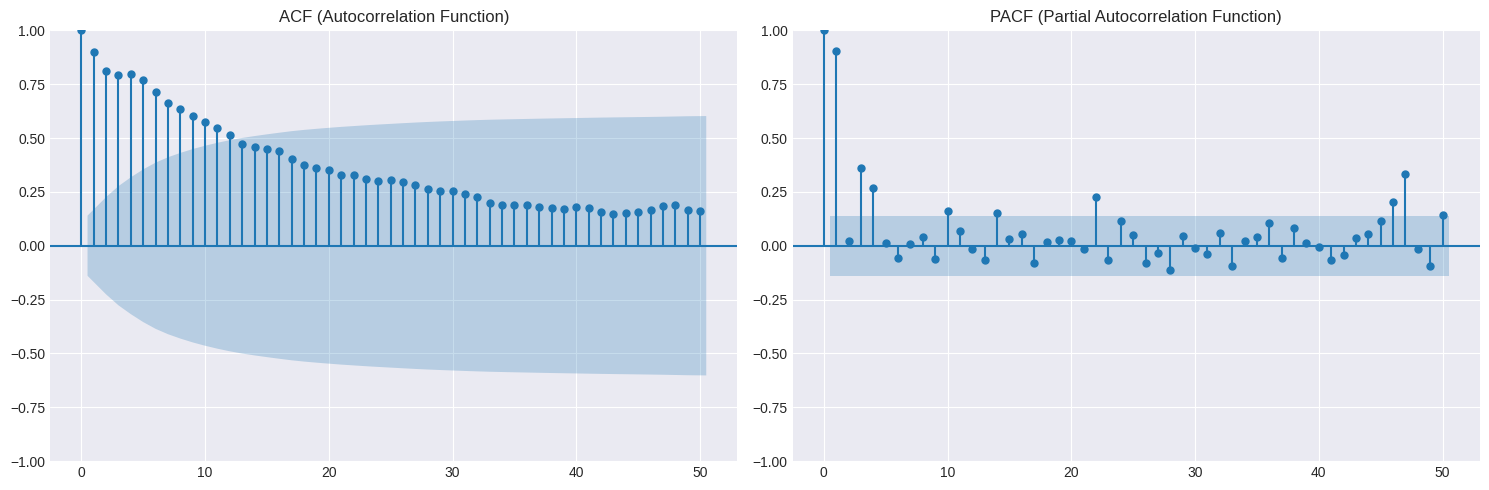


Significant autocorrelations (first 20 lags):
  ACF lags with significant correlation: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
    Lag 1: 0.898
    Lag 2: 0.809
    Lag 3: 0.790
    Lag 4: 0.796
    Lag 5: 0.772
  PACF lags with significant correlation: [1, 3, 4, 10, 14]
    Lag 1: 0.904
    Lag 3: 0.363
    Lag 4: 0.268
    Lag 10: 0.159
    Lag 14: 0.153

💡 Interpretation:
   - ACF→MA(q): If ACF cuts off after lag q, suggests MA(q) model
   - PACF→AR(p): If PACF cuts off after lag p, suggests AR(p) model
   - Slow decay in both: May need differencing (d > 0)

✓ ACF/PACF plots saved



In [ ]:
# ACF and PACF plots
if len(weekly_occupancy) > 0:
    print("\n" + "="*60)
    print("🔗 ACF AND PACF ANALYSIS")
    print("="*60)

    data = weekly_occupancy['bed_occupancy'].dropna()
    print(f"Analyzing autocorrelation for {len(data):,} observations")
    print("   - ACF (Autocorrelation Function): Measures correlation with lagged values")
    print("   - PACF (Partial Autocorrelation Function): Measures direct correlation at each lag")
    print("   - Used for selecting ARIMA model parameters (p, d, q)")

    print("\n📊 Plot: Two panels showing ACF (left) and PACF (right)")
    print("   - X-axis: Lag (weeks)")
    print("   - Y-axis: Correlation coefficient (-1 to 1)")
    print("   - Blue shaded region: 95% confidence interval")
    print("   - Bars outside confidence region: Significant autocorrelation")

    print("\nModel Selection Guidelines:")
    print("   - ACF: Used to identify MA(q) component")
    print("     * Slow decay → non-stationary (needs differencing)")
    print("     * Significant spikes at specific lags → MA order")
    print("   - PACF: Used to identify AR(p) component")
    print("     * Sharp cutoff after lag p → AR order")
    print("     * Significant spikes → direct relationship with that lag")

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    plot_acf(data, lags=50, ax=axes[0], alpha=0.05)
    plot_pacf(data, lags=50, ax=axes[1], alpha=0.05, method='ols')
    axes[0].set_title('ACF (Autocorrelation Function)')
    axes[1].set_title('PACF (Partial Autocorrelation Function)')
    plt.tight_layout()
    save_plot('acf_pacf.png')
    plt.show()

    # Calculate first few significant lags
    from statsmodels.tsa.stattools import acf, pacf
    acf_values = acf(data, nlags=50, fft=False)
    pacf_values = pacf(data, nlags=50, method='ols')

    # Find significant lags (outside confidence interval)
    conf_int = 1.96 / np.sqrt(len(data))
    sig_acf_lags = [i for i in range(1, min(20, len(acf_values))) if abs(acf_values[i]) > conf_int]
    sig_pacf_lags = [i for i in range(1, min(20, len(pacf_values))) if abs(pacf_values[i]) > conf_int]

    print(f"\nSignificant autocorrelations (first 20 lags):")
    if sig_acf_lags:
        print(f"  ACF lags with significant correlation: {sig_acf_lags[:10]}")
        for lag in sig_acf_lags[:5]:
            print(f"    Lag {lag}: {acf_values[lag]:.3f}")
    else:
        print("  No significant ACF lags (weak autocorrelation)")

    if sig_pacf_lags:
        print(f"  PACF lags with significant correlation: {sig_pacf_lags[:10]}")
        for lag in sig_pacf_lags[:5]:
            print(f"    Lag {lag}: {pacf_values[lag]:.3f}")
    else:
        print("  No significant PACF lags (weak direct autocorrelation)")

    print("\n💡 Interpretation:")
    print("   - ACF→MA(q): If ACF cuts off after lag q, suggests MA(q) model")
    print("   - PACF→AR(p): If PACF cuts off after lag p, suggests AR(p) model")
    print("   - Slow decay in both: May need differencing (d > 0)")

    print("\n✓ ACF/PACF plots saved\n")

## Summary Statistics

In [ ]:
# Summary statistics
if len(weekly_occupancy) > 0:
    print("\n" + "="*60)
    print("📊 SUMMARY STATISTICS")
    print("="*60)

    stats = weekly_occupancy['bed_occupancy']
    peak_day = stats.idxmax()
    low_day = stats.idxmin()
    cv = stats.std() / stats.mean()
    q25, q50, q75 = stats.quantile([0.25, 0.50, 0.75])
    iqr = q75 - q25

    print(f"\nBasic Statistics:")
    print(f"  Total weeks: {len(weekly_occupancy):,}")
    print(f"  Date range: {weekly_occupancy.index.min().date()} to {weekly_occupancy.index.max().date()}")
    print(f"  Mean: {stats.mean():.2f} beds/week")
    print(f"  Median: {stats.median():.2f} beds/week")
    print(f"  Std: {stats.std():.2f}")
    print(f"  Min: {stats.min():.2f} (on {low_day.date()})")
    print(f"  Max: {stats.max():.2f} (on {peak_day.date()})")
    print(f"  Range: {stats.max() - stats.min():.2f}")

    print(f"\nQuartiles:")
    print(f"  Q1 (25th percentile): {q25:.2f}")
    print(f"  Q2 (50th percentile, median): {q50:.2f}")
    print(f"  Q3 (75th percentile): {q75:.2f}")
    print(f"  IQR (Interquartile Range): {iqr:.2f}")

    print(f"\nVariability Metrics:")
    print(f"  Coefficient of Variation (CV): {cv:.3f}")
    if cv < 0.1:
        print("    → Low variability (very consistent)")
    elif cv < 0.5:
        print("    → Moderate variability")
    else:
        print("    → High variability (large week-to-week fluctuations)")

    print(f"  Variance: {stats.var():.2f}")
    print(f"  Skewness: {stats.skew():.3f} ({'Right-skewed' if stats.skew() > 0 else 'Left-skewed' if stats.skew() < 0 else 'Symmetric'})")
    print(f"  Kurtosis: {stats.kurtosis():.3f} ({'Heavy-tailed' if stats.kurtosis() > 0 else 'Light-tailed' if stats.kurtosis() < 0 else 'Normal tails'})")

    print(f"\nExtreme Values:")
    print(f"  Peak week: {peak_day.strftime('%Y-%m-%d (%A)')} with {stats.max():.2f} beds")
    print(f"  Lowest week: {low_day.strftime('%Y-%m-%d (%A)')} with {stats.min():.2f} beds")
    print(f"  Peak-to-low ratio: {stats.max() / stats.min():.2f}x")

    # Outliers using IQR method
    lower_bound = q25 - 1.5 * iqr
    upper_bound = q75 + 1.5 * iqr
    outliers = stats[(stats < lower_bound) | (stats > upper_bound)]
    print(f"\nOutliers (IQR method, bounds: {lower_bound:.2f} to {upper_bound:.2f}):")
    print(f"  Number of outliers: {len(outliers)} ({100*len(outliers)/len(stats):.1f}% of data)")
    if len(outliers) > 0:
        print(f"  Outlier range: {outliers.min():.2f} to {outliers.max():.2f}")

    print(f"\n" + "="*60)
    print(f"Overall Summary: {len(weekly_occupancy)} weeks | Mean: {stats.mean():.2f} | Std: {stats.std():.2f} | Range: {stats.min():.2f}-{stats.max():.2f}")
    print(f"Peak: {peak_day.strftime('%Y-%m-%d')} ({stats.max():.2f} beds) | CV: {cv:.3f}")
    print("="*60 + "\n")


📊 SUMMARY STATISTICS

Basic Statistics:
  Total weeks: 197
  Date range: 2020-07-19 to 2024-04-21
  Mean: 2254.37 beds/week
  Median: 2269.40 beds/week
  Std: 136.47
  Min: 1882.00 (on 2020-09-06)
  Max: 2510.70 (on 2024-02-25)
  Range: 628.70

Quartiles:
  Q1 (25th percentile): 2184.70
  Q2 (50th percentile, median): 2269.40
  Q3 (75th percentile): 2353.40
  IQR (Interquartile Range): 168.70

Variability Metrics:
  Coefficient of Variation (CV): 0.061
    → Low variability (very consistent)
  Variance: 18623.13
  Skewness: -0.724 (Left-skewed)
  Kurtosis: 0.316 (Heavy-tailed)

Extreme Values:
  Peak week: 2024-02-25 (Sunday) with 2510.70 beds
  Lowest week: 2020-09-06 (Sunday) with 1882.00 beds
  Peak-to-low ratio: 1.33x

Outliers (IQR method, bounds: 1931.65 to 2606.45):
  Number of outliers: 8 (4.1% of data)
  Outlier range: 1882.00 to 1928.00

Overall Summary: 197 weeks | Mean: 2254.37 | Std: 136.47 | Range: 1882.00-2510.70
Peak: 2024-02-25 (2510.70 beds) | CV: 0.061



## ACF/PACF for New KPIs (VAR Model Design)

For VAR model lag selection, we need to analyze autocorrelation structure of all endogenous variables.
This helps identify optimal lag order for the VAR model.


🔗 ACF/PACF ANALYSIS FOR NEW KPIS (VAR MODEL LAG SELECTION)
Analyzing autocorrelation structure for VAR model variable selection.


📈 icu_occupancy_rate (195 observations):


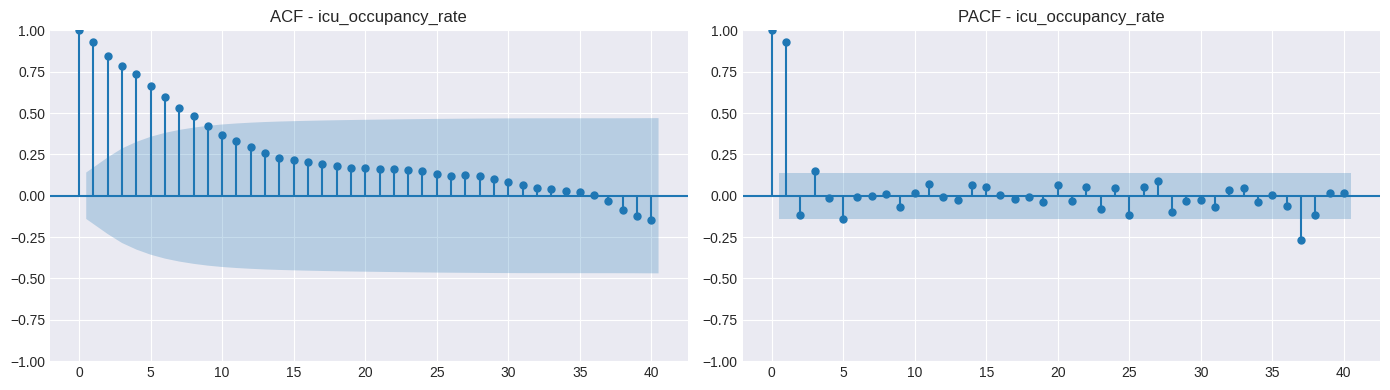

   Significant ACF lags: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
   Significant PACF lags: [1, 3]
   ACF at lag 1: 0.927

📈 covid_patient_pct (151 observations):


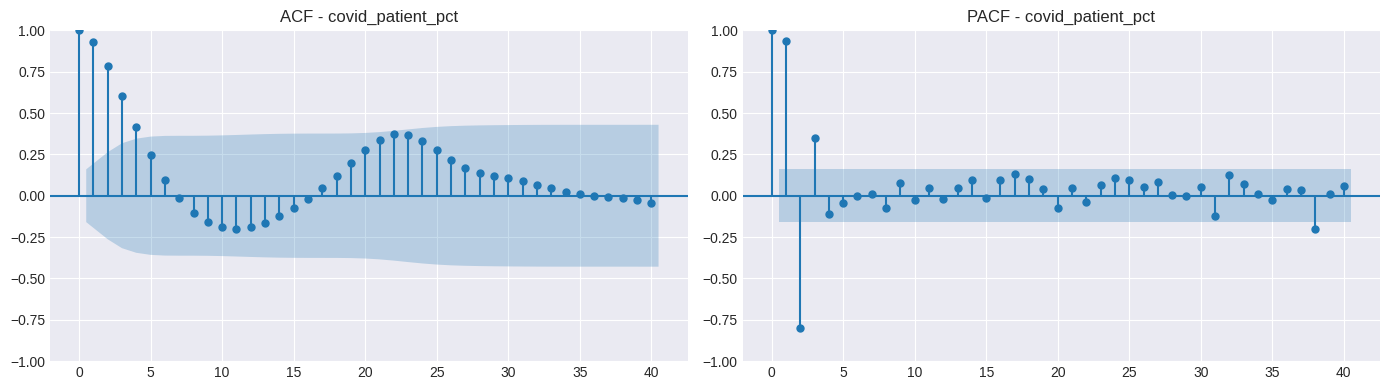

   Significant ACF lags: [1, 2, 3, 4, 5, 10, 11, 12, 13, 19]
   Significant PACF lags: [1, 2, 3]
   ACF at lag 1: 0.928

----------------------------------------------------------------------
📋 ACF/PACF SUMMARY FOR VAR MODEL:
   icu_occupancy_rate: ACF(1)=0.927, Significant PACF lags=[1, 3]
   covid_patient_pct: ACF(1)=0.928, Significant PACF lags=[1, 2, 3]
   Recommendation: Use maximum significant PACF lag as VAR lag order candidate


In [ ]:
# ACF/PACF for new KPIs
print("\n" + "="*70)
print("🔗 ACF/PACF ANALYSIS FOR NEW KPIS (VAR MODEL LAG SELECTION)")
print("="*70)
print("Analyzing autocorrelation structure for VAR model variable selection.\n")

VAR_KPIS_ACF = ['icu_occupancy_rate', 'covid_patient_pct']
acf_results = {}

for kpi in VAR_KPIS_ACF:
    if kpi in weekly_kpis.columns:
        data = weekly_kpis[kpi].dropna()
        if len(data) >= 30:
            print(f"\n📈 {kpi} ({len(data)} observations):")

            # Create ACF/PACF plots
            fig, axes = plt.subplots(1, 2, figsize=(14, 4))

            try:
                plot_acf(data, lags=min(40, len(data)//3), ax=axes[0], alpha=0.05)
                plot_pacf(data, lags=min(40, len(data)//3), ax=axes[1], alpha=0.05, method='ols')
                axes[0].set_title(f'ACF - {kpi}')
                axes[1].set_title(f'PACF - {kpi}')
                plt.tight_layout()
                save_plot(f'acf_pacf_{kpi}.png')
                plt.show()

                # Calculate significant lags
                from statsmodels.tsa.stattools import acf, pacf
                acf_vals = acf(data, nlags=min(20, len(data)//5), fft=False)
                pacf_vals = pacf(data, nlags=min(20, len(data)//5), method='ols')
                conf_int = 1.96 / np.sqrt(len(data))

                sig_acf = [i for i in range(1, len(acf_vals)) if abs(acf_vals[i]) > conf_int]
                sig_pacf = [i for i in range(1, len(pacf_vals)) if abs(pacf_vals[i]) > conf_int]

                print(f"   Significant ACF lags: {sig_acf[:10] if sig_acf else 'None'}")
                print(f"   Significant PACF lags: {sig_pacf[:10] if sig_pacf else 'None'}")

                if sig_acf:
                    print(f"   ACF at lag 1: {acf_vals[1]:.3f}")

                acf_results[kpi] = {'sig_acf': sig_acf, 'sig_pacf': sig_pacf, 'acf_lag1': acf_vals[1]}

            except Exception as e:
                print(f"   ⚠️ Error creating ACF/PACF: {e}")
        else:
            print(f"\n📈 {kpi}: ⚠️ Insufficient data ({len(data)} points)")
    else:
        print(f"\n📈 {kpi}: ⚠️ Not available in dataset")

# Summary
if acf_results:
    print("\n" + "-"*70)
    print("📋 ACF/PACF SUMMARY FOR VAR MODEL:")
    for kpi, results in acf_results.items():
        print(f"   {kpi}: ACF(1)={results['acf_lag1']:.3f}, Significant PACF lags={results['sig_pacf'][:5]}")
    print("   Recommendation: Use maximum significant PACF lag as VAR lag order candidate")
    print("="*70)

## Cross-Correlation Analysis Between KPIs

Cross-correlation helps identify lead-lag relationships between KPIs:
- Does ICU pressure predict bed occupancy surges?
- Does COVID patient percentage predict future bed occupancy?


🔗 CROSS-CORRELATION ANALYSIS BETWEEN KPIS
Analyzing lead-lag relationships for VAR model structure.


📈 bed_occupancy vs icu_occupancy_rate (195 common observations):


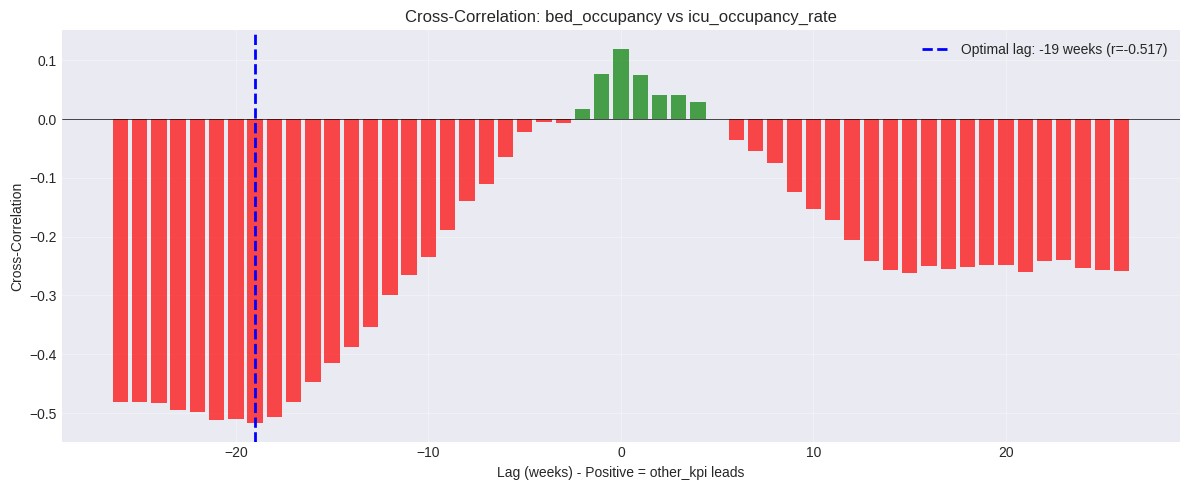

   Correlation at lag 0: 0.1191
   Optimal lag: -19 weeks (r = -0.5168)
   → bed_occupancy LEADS icu_occupancy_rate by 19 weeks

📈 bed_occupancy vs covid_patient_pct (151 common observations):


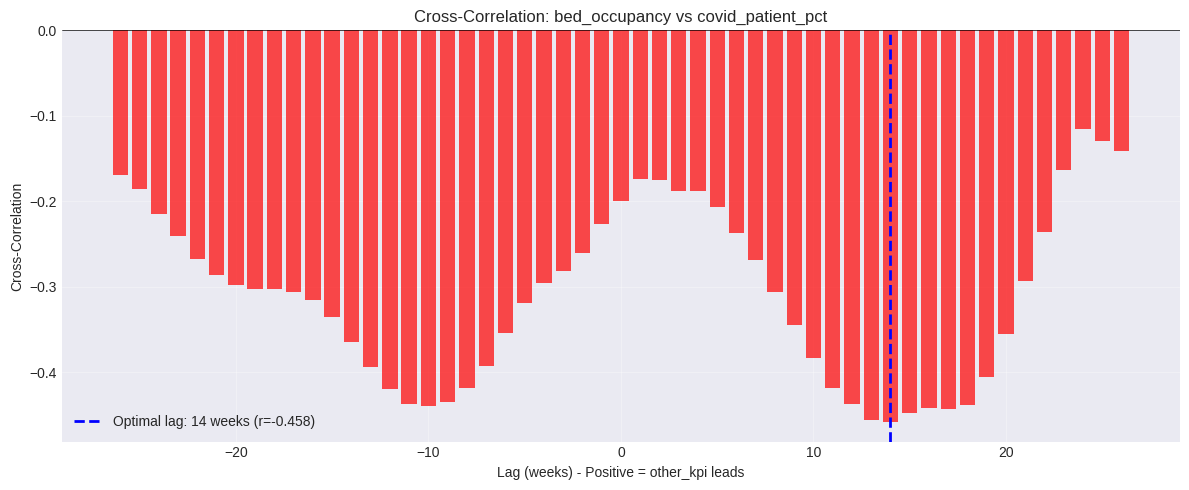

   Correlation at lag 0: -0.1993
   Optimal lag: 14 weeks (r = -0.4579)
   → covid_patient_pct LEADS bed_occupancy by 14 weeks (predictive!)



In [ ]:
# Cross-correlation between KPIs
print("\n" + "="*70)
print("🔗 CROSS-CORRELATION ANALYSIS BETWEEN KPIS")
print("="*70)
print("Analyzing lead-lag relationships for VAR model structure.\n")

# Target variable
target = 'bed_occupancy'
other_kpis = ['icu_occupancy_rate', 'covid_patient_pct']

if target in weekly_kpis.columns:
    target_data = weekly_kpis[target].dropna()

    for other_kpi in other_kpis:
        if other_kpi in weekly_kpis.columns:
            other_data = weekly_kpis[other_kpi].dropna()
            common_idx = target_data.index.intersection(other_data.index)

            if len(common_idx) >= 30:
                target_aligned = target_data.loc[common_idx].values
                other_aligned = other_data.loc[common_idx].values

                print(f"\n📈 {target} vs {other_kpi} ({len(common_idx)} common observations):")

                # Calculate cross-correlation
                max_lag = min(26, len(common_idx) // 4)  # Max 6 months lag

                # Test different lags
                correlations = []
                for lag in range(-max_lag, max_lag + 1):
                    if lag == 0:
                        corr = np.corrcoef(target_aligned, other_aligned)[0, 1]
                    elif lag > 0:
                        # Positive lag: other_kpi leads target
                        corr = np.corrcoef(target_aligned[lag:], other_aligned[:-lag])[0, 1]
                    else:
                        # Negative lag: target leads other_kpi
                        corr = np.corrcoef(target_aligned[:lag], other_aligned[-lag:])[0, 1]
                    correlations.append((lag, corr))

                # Find optimal lag
                optimal_lag, optimal_corr = max(correlations, key=lambda x: abs(x[1]))

                # Plot cross-correlation
                lags = [c[0] for c in correlations]
                corrs = [c[1] for c in correlations]

                plt.figure(figsize=(12, 5))
                plt.bar(lags, corrs, color=['green' if c > 0 else 'red' for c in corrs], alpha=0.7)
                plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
                plt.axvline(x=optimal_lag, color='blue', linestyle='--', linewidth=2,
                           label=f'Optimal lag: {optimal_lag} weeks (r={optimal_corr:.3f})')
                plt.xlabel('Lag (weeks) - Positive = other_kpi leads')
                plt.ylabel('Cross-Correlation')
                plt.title(f'Cross-Correlation: {target} vs {other_kpi}')
                plt.legend()
                plt.grid(True, alpha=0.3)
                plt.tight_layout()
                save_plot(f'crosscorr_{target}_vs_{other_kpi}.png')
                plt.show()

                print(f"   Correlation at lag 0: {correlations[max_lag][1]:.4f}")
                print(f"   Optimal lag: {optimal_lag} weeks (r = {optimal_corr:.4f})")

                if optimal_lag > 0:
                    print(f"   → {other_kpi} LEADS {target} by {optimal_lag} weeks (predictive!)")
                elif optimal_lag < 0:
                    print(f"   → {target} LEADS {other_kpi} by {-optimal_lag} weeks")
                else:
                    print(f"   → Variables move simultaneously")
            else:
                print(f"\n📈 {target} vs {other_kpi}: ⚠️ Insufficient common data")
        else:
            print(f"\n📈 {other_kpi}: ⚠️ Not available")

print("\n" + "="*70)

## Granger Causality Tests (VAR Model Design)

Granger causality tests whether one time series helps predict another.
This is critical for VAR model variable selection:
- If X Granger-causes Y, including X in the VAR model improves Y forecasts.

In [ ]:
# Granger causality tests
print("\n" + "="*70)
print("📊 GRANGER CAUSALITY TESTS (VAR MODEL DESIGN)")
print("="*70)
print("Testing if KPIs Granger-cause bed_occupancy (improves forecasts).\n")

target = 'bed_occupancy'
granger_kpis = ['icu_occupancy_rate', 'covid_patient_pct']
max_lag = 8  # Test up to 8 weeks lag

granger_results = {}

if target in weekly_kpis.columns:
    target_data = weekly_kpis[target].dropna()

    for other_kpi in granger_kpis:
        if other_kpi in weekly_kpis.columns:
            other_data = weekly_kpis[other_kpi].dropna()
            common_idx = target_data.index.intersection(other_data.index)

            if len(common_idx) >= 50:  # Need enough data for Granger test
                # Prepare data for Granger test
                granger_data = pd.DataFrame({
                    target: target_data.loc[common_idx].values,
                    other_kpi: other_data.loc[common_idx].values
                }).dropna()

                print(f"\n📈 Does {other_kpi} Granger-cause {target}?")
                print(f"   Observations: {len(granger_data)}")

                try:
                    # Run Granger causality test
                    gc_result = grangercausalitytests(granger_data[[target, other_kpi]], maxlag=max_lag, verbose=False)

                    # Extract p-values for each lag
                    print(f"\n   Granger Causality Test Results (H0: {other_kpi} does NOT cause {target}):")
                    print(f"   {'Lag':<6} {'F-stat':<12} {'p-value':<12} {'Significant?':<15}")
                    print("   " + "-"*50)

                    significant_lags = []
                    for lag in range(1, max_lag + 1):
                        f_stat = gc_result[lag][0]['ssr_ftest'][0]
                        p_value = gc_result[lag][0]['ssr_ftest'][1]
                        is_significant = p_value < 0.05
                        if is_significant:
                            significant_lags.append(lag)
                        print(f"   {lag:<6} {f_stat:<12.4f} {p_value:<12.4f} {'✓ YES (p<0.05)' if is_significant else '✗ NO'}")

                    print("   " + "-"*50)

                    if significant_lags:
                        print(f"\n   ✓ CONCLUSION: {other_kpi} Granger-causes {target}")
                        print(f"     Significant at lags: {significant_lags}")
                        print(f"     → INCLUDE in VAR model (improves {target} forecasts)")
                        granger_results[other_kpi] = {'causes_target': True, 'lags': significant_lags}
                    else:
                        print(f"\n   ✗ CONCLUSION: {other_kpi} does NOT Granger-cause {target}")
                        print(f"     → May still include for other reasons (e.g., cointegration)")
                        granger_results[other_kpi] = {'causes_target': False, 'lags': []}

                except Exception as e:
                    print(f"   ⚠️ Granger test failed: {e}")
            else:
                print(f"\n📈 {other_kpi}: ⚠️ Insufficient data ({len(common_idx)} points)")
        else:
            print(f"\n📈 {other_kpi}: ⚠️ Not available")

# Summary
if granger_results:
    print("\n" + "="*70)
    print("📋 GRANGER CAUSALITY SUMMARY:")
    print("-"*70)
    for kpi, result in granger_results.items():
        if result['causes_target']:
            print(f"   ✓ {kpi}: Granger-causes bed_occupancy (lags {result['lags']})")
        else:
            print(f"   ✗ {kpi}: Does NOT Granger-cause bed_occupancy")

    # VAR recommendation
    include_vars = [k for k, v in granger_results.items() if v['causes_target']]
    print("\n   📊 VAR MODEL RECOMMENDATION:")
    print(f"   Endogenous variables: ['bed_occupancy'] + {include_vars}")
    if include_vars:
        opt_lag = max([max(v['lags']) for v in granger_results.values() if v['lags']], default=1)
        print(f"   Suggested lag order: {opt_lag} weeks (based on Granger significance)")
    print("="*70)


📊 GRANGER CAUSALITY TESTS (VAR MODEL DESIGN)
Testing if KPIs Granger-cause bed_occupancy (improves forecasts).


📈 Does icu_occupancy_rate Granger-cause bed_occupancy?
   Observations: 195

   Granger Causality Test Results (H0: icu_occupancy_rate does NOT cause bed_occupancy):
   Lag    F-stat       p-value      Significant?   
   --------------------------------------------------
   1      1.2959       0.2564       ✗ NO
   2      0.7059       0.4949       ✗ NO
   3      0.1355       0.9388       ✗ NO
   4      1.3870       0.2402       ✗ NO
   5      1.3179       0.2584       ✗ NO
   6      1.1062       0.3606       ✗ NO
   7      1.1429       0.3386       ✗ NO
   8      1.1421       0.3377       ✗ NO
   --------------------------------------------------

   ✗ CONCLUSION: icu_occupancy_rate does NOT Granger-cause bed_occupancy
     → May still include for other reasons (e.g., cointegration)

📈 Does covid_patient_pct Granger-cause bed_occupancy?
   Observations: 151

   Granger Causa

## Investigating Counterintuitive Correlations

**Important Note**: The correlation analysis shows **negative correlations** between flu activity and admissions (r=-0.231), which is counterintuitive. Higher flu activity should logically lead to higher admissions. This section investigates why this might be happening.



🔍 INVESTIGATING COUNTERINTUITIVE FLU-ADMISSIONS CORRELATION

📊 Question: Why is flu_activity_level negatively correlated with admissions?
   Expected: Higher flu activity → Higher admissions (positive correlation)
   Observed: r = -0.231 (negative correlation)

   Possible explanations:
   1. Time trend confounding (admissions decreasing over time)
   2. Epiweek effect (strong time-based correlation)
   3. Lag effect (flu leads admissions by X weeks)
   4. Data issue or misalignment

📈 Basic Correlation Analysis:
   Flu-Admissions correlation: 0.3854

🔍 Investigation 1: Time Trend Analysis
   Bed occupancy trend:
     Mean bed occupancy by year:
       2020: 1981.83 (flu activity: 1.18)
       2021: 2201.91 (flu activity: 1.78)
       2022: 2284.44 (flu activity: 2.76)
       2023: 2343.12 (flu activity: 2.86)
       2024: 2441.92 (flu activity: 4.32)

   Year-over-year correlation (trend): 0.9370

🔍 Investigation 3: Partial Correlation (controlling for time)
   Partial correlation (c

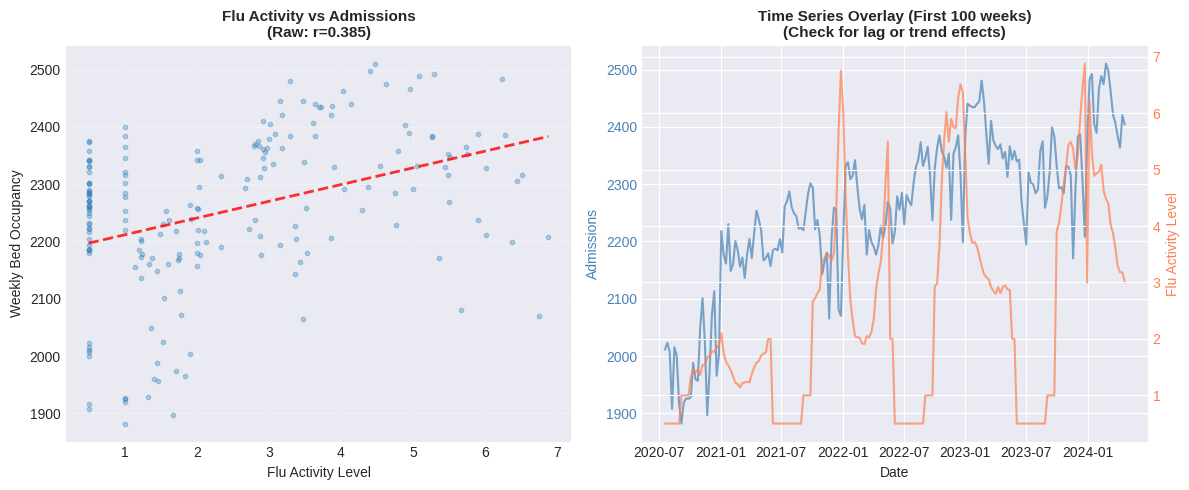


💡 Interpretation:
   - If partial correlation is positive: Use detrended flu features
   - If lag correlation is positive: Use lagged flu features
   - If scatter shows clusters: Relationship may be non-linear
   - Always verify the relationship makes intuitive sense!

✓ Diagnostic analysis complete
   Visualization saved: flu_admissions_diagnostic.png



In [ ]:
# ============================================================================
# INVESTIGATION: Why is flu_activity_level negatively correlated with admissions?
# ============================================================================
if len(data_with_external) > 0 and 'bed_occupancy' in data_with_external.columns and 'flu_activity_level' in data_with_external.columns:
    print("\n" + "="*70)
    print("🔍 INVESTIGATING COUNTERINTUITIVE FLU-ADMISSIONS CORRELATION")
    print("="*70)

    print("\n📊 Question: Why is flu_activity_level negatively correlated with admissions?")
    print("   Expected: Higher flu activity → Higher admissions (positive correlation)")
    print("   Observed: r = -0.231 (negative correlation)")
    print("\n   Possible explanations:")
    print("   1. Time trend confounding (admissions decreasing over time)")
    print("   2. Epiweek effect (strong time-based correlation)")
    print("   3. Lag effect (flu leads admissions by X weeks)")
    print("   4. Data issue or misalignment")

    admissions_data = data_with_external['bed_occupancy'].dropna()
    flu_data = data_with_external['flu_activity_level'].dropna()
    epiweek_data = data_with_external['epiweek'].dropna() if 'epiweek' in data_with_external.columns else pd.Series()

    common_idx = admissions_data.index.intersection(flu_data.index)
    adm_aligned = admissions_data.loc[common_idx]
    flu_aligned = flu_data.loc[common_idx]

    print(f"\n📈 Basic Correlation Analysis:")
    print(f"   Flu-Admissions correlation: {adm_aligned.corr(flu_aligned):.4f}")

    # Check if trend is the issue
    print(f"\n🔍 Investigation 1: Time Trend Analysis")
    print(f"   Bed occupancy trend:")
    if len(adm_aligned) > 52:  # Changed from 365 days to 52 weeks for weekly data
        # Calculate year-over-year trend
        adm_by_year = adm_aligned.groupby(adm_aligned.index.year).mean()
        flu_by_year = flu_aligned.groupby(flu_aligned.index.year).mean()

        print(f"     Mean bed occupancy by year:")
        for year in sorted(adm_by_year.index):
            # Fix: Conditionally format flu activity to avoid ValueError when 'N/A'
            flu_activity_display = f"{flu_by_year[year]:.2f}" if year in flu_by_year.index else "N/A"
            print(f"       {year}: {adm_by_year[year]:.2f} (flu activity: {flu_activity_display})")

        # Trend correlation
        trend_corr = adm_by_year.corr(flu_by_year)
        print(f"\n   Year-over-year correlation (trend): {trend_corr:.4f}")
        if trend_corr < 0:
            print(f"     ⚠️  Yearly trends are negatively correlated")
            print(f"     → This explains part of the negative correlation!")

    # Check epiweek confounding
    if len(epiweek_data) > 0:
        epiweek_aligned = epiweek_data.loc[common_idx]
        print(f"\n🔍 Investigation 2: Epiweek Confounding")
        print(f"   Epiweek-Admissions correlation: {adm_aligned.corr(epiweek_aligned):.4f}")
        print(f"   Epiweek-Flu correlation: {flu_aligned.corr(epiweek_aligned):.4f}")

        if abs(adm_aligned.corr(epiweek_aligned)) > 0.8:
            print(f"     ⚠️  Epiweek strongly correlates with admissions (time trend!)")

        if abs(flu_aligned.corr(epiweek_aligned)) > 0.3:
            print(f"     ⚠️  Epiweek also correlates with flu activity")
            print(f"     → Epiweek may be confounding the relationship!")

    # Partial correlation (controlling for time)
    print(f"\n🔍 Investigation 3: Partial Correlation (controlling for time)")
    try:
        from scipy.stats import pearsonr
        import numpy as np

        # Use a time index as control variable
        time_index = np.arange(len(adm_aligned))

        # Residuals from regressing on time
        from scipy import stats

        # Regress admissions on time
        adm_slope, adm_intercept, _, _, _ = stats.linregress(time_index, adm_aligned.values)
        adm_residuals = adm_aligned.values - (adm_slope * time_index + adm_intercept)

        # Regress flu on time
        flu_slope, flu_intercept, _, _, _ = stats.linregress(time_index, flu_aligned.values)
        flu_residuals = flu_aligned.values - (flu_slope * time_index + flu_intercept)

        # Correlation of residuals (partial correlation controlling for time)
        partial_corr, partial_p = pearsonr(adm_residuals, flu_residuals)
        print(f"   Partial correlation (controlling for time trend): {partial_corr:.4f} (p={partial_p:.4f})")

        if partial_corr > 0:
            print(f"     ✅ After controlling for time, correlation becomes POSITIVE!")
            print(f"     → Confirms: The negative correlation is due to time trend confounding")
        elif partial_corr < 0:
            print(f"     ⚠️  Even after controlling for time, correlation is still negative")
            print(f"     → May indicate lag effect or other confounding")

    except Exception as e:
        print(f"     ⚠️  Could not calculate partial correlation: {e}")

    # Check lag effects
    print(f"\n🔍 Investigation 4: Lag Effects")
    print(f"   Testing correlations at different lags (flu activity leading admissions):")
    print(f"   Lag 0 (simultaneous): {adm_aligned.corr(flu_aligned):.4f}")

    for lag in [1, 3, 7, 14, 21]:
        try:
            if lag > 0:
                adm_shifted = adm_aligned.iloc[lag:]
                flu_shifted = flu_aligned.iloc[:-lag]
                if len(adm_shifted) > 100:
                    lag_corr = adm_shifted.corr(flu_shifted)
                    print(f"   Lag +{lag} weeks (flu leads): {lag_corr:.4f}")
                    if lag_corr > 0:
                        print(f"     ✅ Positive correlation at lag {lag}!")
        except:
            pass

    # NEW: Check within-year seasonality
    print(f"\n🔍 Investigation 5: Within-Year Seasonality Analysis")
    print(f"   Checking if the negative correlation is due to seasonal mismatch within each year")
    print(f"   (e.g., flu peaks in winter, but admissions peak in summer/fall for other reasons)")

    try:
        # Group by month and year
        adm_aligned_df = adm_aligned.to_frame('bed_occupancy')
        flu_aligned_df = flu_aligned.to_frame('flu_activity')
        combined = adm_aligned_df.join(flu_aligned_df, how='inner')
        combined['year'] = combined.index.year
        combined['month'] = combined.index.month

        # Calculate monthly averages across all years
        monthly_avg = combined.groupby('month')[['bed_occupancy', 'flu_activity']].mean()
        monthly_corr = monthly_avg['bed_occupancy'].corr(monthly_avg['flu_activity'])

        print(f"\n   Monthly pattern correlation (across all years): {monthly_corr:.4f}")
        print(f"   Monthly averages:")
        month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
        for month in range(1, 13):
            if month in monthly_avg.index:
                adm_avg = monthly_avg.loc[month, 'bed_occupancy']
                flu_avg = monthly_avg.loc[month, 'flu_activity']
                print(f"     {month_names[month-1]}: Admissions={adm_avg:.2f}, Flu={flu_avg:.2f}")

        if monthly_corr > 0:
            print(f"     ✅ Monthly patterns are POSITIVELY correlated!")
            print(f"     → Within-year: Higher flu months → Higher admissions months")
        elif monthly_corr < 0:
            print(f"     ⚠️  Monthly patterns are negatively correlated")
            print(f"     → Within-year: Flu peaks when admissions are lower")
            print(f"     → This explains the negative correlation!")

        # Check within each year separately
        print(f"\n   Within-year correlations (by year):")
        for year in sorted(combined['year'].unique()):
            year_data = combined[combined['year'] == year]
            if len(year_data) > 100:
                year_corr = year_data['bed_occupancy'].corr(year_data['flu_activity'])
                print(f"     {year}: r={year_corr:.4f}")

    except Exception as e:
        print(f"     ⚠️  Could not calculate within-year seasonality: {e}")

        # NEW: Check flu season vs non-flu season
    print(f"\n🔍 Investigation 6: Flu Season vs Non-Flu Season Comparison")
    try:
        if 'is_flu_season' in data_with_external.columns:
            flu_season_data = data_with_external.loc[common_idx]
            non_flu_adm = flu_season_data[flu_season_data['is_flu_season'] == False]['bed_occupancy'].mean()
            flu_adm = flu_season_data[flu_season_data['is_flu_season'] == True]['bed_occupancy'].mean()

            print(f"   Non-flu season mean admissions: {non_flu_adm:.2f}")
            print(f"   Flu season mean admissions: {flu_adm:.2f}")
            diff = flu_adm - non_flu_adm
            pct_diff = (diff / non_flu_adm) * 100 if non_flu_adm > 0 else 0
            print(f"   Difference: {diff:+.2f} ({pct_diff:+.1f}%)")

            if diff > 0:
                print(f"     ✅ Admissions are HIGHER during flu season (makes sense!)")
                print(f"     → This contradicts the negative correlation!")
                print(f"     → The negative correlation might be due to other confounding factors")
            else:
                print(f"     ⚠️  Admissions are LOWER during flu season (unexpected!)")
        else:
            print(f"     ⚠️  'is_flu_season' column not available")
    except Exception as e:
        print(f"     ⚠️  Could not compare flu vs non-flu season: {e}")

    # NEW: Check within each year
    print(f"\n🔍 Investigation 7: Within-Year Analysis")
    print(f"   Checking correlations within each calendar year")
    print(f"   This will reveal if negative correlation is due to:")
    print(f"     • Between-year differences (years have different baseline levels)")
    print(f"     • Within-year relationships (negative correlation within each year)")
    print(f"   COVID-19 data years: 2020, 2021, 2022, 2023, 2024")

    try:
        # Group by calendar year
        adm_aligned_df = adm_aligned.to_frame('bed_occupancy')
        flu_aligned_df = flu_aligned.to_frame('flu_activity')
        combined = adm_aligned_df.join(flu_aligned_df, how='inner')
        combined['year'] = combined.index.year

        print(f"\n   Within-year correlations:")
        print(f"   {'Year':<6} {'Correlation':<12} {'Mean Bed Occ':<14} {'Mean Flu':<12} {'Interpretation':<30}")
        print(f"   {'-'*6} {'-'*12} {'-'*14} {'-'*12} {'-'*30}")

        within_group_corrs = {}
        for year in sorted(combined['year'].unique()):
            year_data = combined[combined['year'] == year]
            if len(year_data) > 10:  # Need enough data points (weekly data has fewer observations)
                year_corr = year_data['bed_occupancy'].corr(year_data['flu_activity'])
                mean_occ = year_data['bed_occupancy'].mean()
                mean_flu = year_data['flu_activity'].mean()

                within_group_corrs[year] = year_corr

                # Interpretation
                if year_corr > 0.3:
                    interp = "Strong positive"
                elif year_corr > 0.15:
                    interp = "Moderate positive"
                elif year_corr > 0:
                    interp = "Weak positive"
                elif year_corr > -0.15:
                    interp = "Weak negative"
                elif year_corr > -0.3:
                    interp = "Moderate negative"
                else:
                    interp = "Strong negative"

                print(f"   {year:<6} {year_corr:>11.4f} {mean_occ:>13.2f} {mean_flu:>11.2f} {interp:<30}")

        # Summary
        if len(within_group_corrs) > 0:
            avg_within_corr = np.mean(list(within_group_corrs.values()))
            positive_count = sum(1 for v in within_group_corrs.values() if v > 0)
            negative_count = len(within_group_corrs) - positive_count

            print(f"\n   Summary across all years:")
            print(f"     Average within-year correlation: {avg_within_corr:.4f}")
            print(f"     Years with positive correlation: {positive_count}/{len(within_group_corrs)}")
            print(f"     Years with negative correlation: {negative_count}/{len(within_group_corrs)}")

            if avg_within_corr > 0:
                print(f"     ✅ Average within-year correlation is POSITIVE!")
                print(f"     → Negative overall correlation is likely due to BETWEEN-YEAR differences")
                print(f"     → Years have different baseline levels (bed occupancy increasing over time)")
                print(f"     → Within each year, flu and bed occupancy are positively related")
            elif avg_within_corr < 0:
                print(f"     ⚠️  Average within-year correlation is NEGATIVE")
                print(f"     → Negative correlation exists even WITHIN each year")
                print(f"     → This suggests a true inverse relationship, not just trend confounding")

            # Compare to overall correlation
            overall_corr = adm_aligned.corr(flu_aligned)
            print(f"\n     Overall correlation (all years combined): {overall_corr:.4f}")
            print(f"     Within-year average: {avg_within_corr:.4f}")
            diff = overall_corr - avg_within_corr
            if abs(diff) > 0.1:
                print(f"     Difference: {diff:+.4f}")
                if diff < 0:
                    print(f"     → Overall correlation is more negative than within-year average")
                    print(f"     → Between-year differences are amplifying the negative correlation")
                else:
                    print(f"     → Overall correlation is less negative than within-year average")
                    print(f"     → Between-year differences are reducing the negative correlation")

    except Exception as e:
        print(f"     ⚠️  Could not calculate within-group correlations: {e}")
        import traceback
        print(f"     Error details: {traceback.format_exc()}")

    # Visual check: Scatter plot
    print(f"\n📊 Creating diagnostic scatter plot:")
    print(f"   This will show the actual relationship between flu activity and admissions")

    plt.figure(figsize=(12, 5))

    # Plot 1: Raw scatter
    plt.subplot(1, 2, 1)
    plt.scatter(flu_aligned, adm_aligned, alpha=0.3, s=10)
    z = np.polyfit(flu_aligned, adm_aligned, 1)
    p = np.poly1d(z)
    plt.plot(flu_aligned.sort_values(), p(flu_aligned.sort_values()), "r--", alpha=0.8, linewidth=2)
    plt.xlabel('Flu Activity Level', fontsize=10)
    plt.ylabel('Weekly Bed Occupancy', fontsize=10)
    plt.title(f'Flu Activity vs Admissions\n(Raw: r={adm_aligned.corr(flu_aligned):.3f})', fontsize=11, fontweight='bold')
    plt.grid(True, alpha=0.3)

    # Plot 2: Time series overlay
    plt.subplot(1, 2, 2)
    ax1 = plt.gca()
    color1 = 'steelblue'
    ax1.set_xlabel('Date', fontsize=10)
    ax1.set_ylabel('Admissions', color=color1, fontsize=10)
    line1 = ax1.plot(adm_aligned.index[:500], adm_aligned.iloc[:500], color=color1, alpha=0.7, label='Admissions')
    ax1.tick_params(axis='y', labelcolor=color1)

    ax2 = ax1.twinx()
    color2 = 'coral'
    ax2.set_ylabel('Flu Activity Level', color=color2, fontsize=10)
    line2 = ax2.plot(flu_aligned.index[:500], flu_aligned.iloc[:500], color=color2, alpha=0.7, label='Flu Activity')
    ax2.tick_params(axis='y', labelcolor=color2)

    plt.title('Time Series Overlay (First 100 weeks)\n(Check for lag or trend effects)', fontsize=11, fontweight='bold')

    plt.tight_layout()
    save_plot('flu_admissions_diagnostic.png')
    plt.show()

    print("\n💡 Interpretation:")
    print("   - If partial correlation is positive: Use detrended flu features")
    print("   - If lag correlation is positive: Use lagged flu features")
    print("   - If scatter shows clusters: Relationship may be non-linear")
    print("   - Always verify the relationship makes intuitive sense!")

    print("\n✓ Diagnostic analysis complete")
    print("   Visualization saved: flu_admissions_diagnostic.png\n")
else:
    print("ℹ️  Data not available for diagnostic analysis")

## External Features Analysis Summary
#### FEATURE IMPORTANCE SUMMARY
#### FEATURE SELECTION DECISION MATRIX

In [ ]:
# ============================================================================
# SECTION 7: FEATURE IMPORTANCE SUMMARY
# ============================================================================
if len(data_with_external) > 0 and 'bed_occupancy' in data_with_external.columns and len(EXTERNAL_FEATURES) > 0:
    print("\n" + "="*70)
    print("⭐ FEATURE IMPORTANCE SUMMARY")
    print("="*70)

    print("\n📊 Creating comprehensive feature importance summary:")
    print("   This consolidates all analysis findings into actionable recommendations")
    print("   Features are ranked by importance, significance, and predictive power")

    # Collect all findings
    admissions_data = data_with_external['bed_occupancy'].dropna()

    # Calculate metrics for each feature
    feature_summary = []

    for feat in EXTERNAL_FEATURES:
        feat_data = data_with_external[feat].dropna()
        common_idx = admissions_data.index.intersection(feat_data.index)

        if len(common_idx) < 10:
            continue

        adm_aligned = admissions_data.loc[common_idx]
        feat_aligned = feat_data.loc[common_idx]

        # Correlation
        corr_val = adm_aligned.corr(feat_aligned)

        # Statistical significance
        try:
            _, p_value = pearsonr(adm_aligned, feat_aligned)
            significant = p_value < 0.05
        except:
            p_value = 1.0
            significant = False

        # Basic stats
        mean_val = feat_aligned.mean()
        std_val = feat_aligned.std()
        min_val = feat_aligned.min()
        max_val = feat_aligned.max()

        # Distribution stats
        skew_val = feat_aligned.skew()
        kurt_val = feat_aligned.kurtosis()

        feature_summary.append({
            'feature': feat,
            'correlation': corr_val,
            'abs_correlation': abs(corr_val),
            'p_value': p_value,
            'significant': significant,
            'mean': mean_val,
            'std': std_val,
            'min': min_val,
            'max': max_val,
            'skewness': skew_val,
            'kurtosis': kurt_val
        })

    if len(feature_summary) > 0:
        summary_df = pd.DataFrame(feature_summary)
        summary_df = summary_df.sort_values('abs_correlation', ascending=False)

        print("\n📊 Feature Importance Ranking:")
        print("="*90)
        print(f"{'Feature':<25} {'Correlation':<12} {'P-value':<12} {'Significant':<12} {'Category':<20}")
        print("="*90)

        for _, row in summary_df.iterrows():
            sig_str = "✓ YES" if row['significant'] else "✗ NO"

            # Categorize
            if abs(row['correlation']) > 0.3 and row['significant']:
                category = "STRONG PREDICTOR"
            elif abs(row['correlation']) > 0.15 and row['significant']:
                category = "MODERATE PREDICTOR"
            elif row['significant']:
                category = "WEAK BUT SIGNIFICANT"
            else:
                category = "NOT SIGNIFICANT"

            print(f"{row['feature']:<25} {row['correlation']:>11.3f} {row['p_value']:>11.4f} {sig_str:<12} {category:<20}")

        print("="*90)

        # Categorize features
        strong_features = summary_df[(summary_df['abs_correlation'] > 0.3) & (summary_df['significant'] == True)]
        moderate_features = summary_df[(summary_df['abs_correlation'].between(0.15, 0.3)) & (summary_df['significant'] == True)]
        weak_significant = summary_df[(summary_df['abs_correlation'] <= 0.15) & (summary_df['significant'] == True)]
        not_significant = summary_df[summary_df['significant'] == False]

        print("\n💡 Feature Categorization:")
        print(f"\n✅ STRONG PREDICTORS (|r| > 0.3, p < 0.05) - Include in all models:")
        if len(strong_features) > 0:
            for _, row in strong_features.iterrows():
                print(f"   • {row['feature']}: r={row['correlation']:.3f}, p={row['p_value']:.4f}")
        else:
            print("   (None found)")

        print(f"\n⚠️  MODERATE PREDICTORS (0.15 < |r| <= 0.3, p < 0.05) - Consider including:")
        if len(moderate_features) > 0:
            for _, row in moderate_features.iterrows():
                print(f"   • {row['feature']}: r={row['correlation']:.3f}, p={row['p_value']:.4f}")
        else:
            print("   (None found)")

        print(f"\nℹ️  WEAK BUT SIGNIFICANT (|r| <= 0.15, p < 0.05) - Test performance:")
        if len(weak_significant) > 0:
            for _, row in weak_significant.iterrows():
                print(f"   • {row['feature']}: r={row['correlation']:.3f}, p={row['p_value']:.4f}")
        else:
            print("   (None found)")

        print(f"\n❌ NOT SIGNIFICANT (p >= 0.05) - Exclude unless interaction effects found:")
        if len(not_significant) > 0:
            for _, row in not_significant.iterrows():
                print(f"   • {row['feature']}: r={row['correlation']:.3f}, p={row['p_value']:.4f}")
        else:
            print("   (All features are significant)")

        print("\n✓ Feature importance summary complete\n")
    else:
        print("⚠️  Could not create feature importance summary (insufficient data)")
else:
    print("ℹ️  External features not available for importance summary")

# ============================================================================
# SECTION 19: FEATURE SELECTION DECISION MATRIX
# ============================================================================
if len(data_with_external) > 0 and 'bed_occupancy' in data_with_external.columns and len(EXTERNAL_FEATURES) > 0:
    print("\n" + "="*70)
    print("📋 FEATURE SELECTION DECISION MATRIX")
    print("="*70)

    print("\n📊 Creating decision matrix for feature selection:")
    print("   This matrix consolidates all findings to make clear include/exclude decisions")
    print("   Each feature is evaluated across multiple criteria")

    # Reuse feature summary if available
    if 'summary_df' not in locals() or len(summary_df) == 0:
        # Quick calculation if summary not available
        admissions_data = data_with_external['bed_occupancy'].dropna()
        feature_summary = []
        for feat in EXTERNAL_FEATURES:
            feat_data = data_with_external[feat].dropna()
            common_idx = admissions_data.index.intersection(feat_data.index)
            if len(common_idx) > 10:
                adm_aligned = admissions_data.loc[common_idx]
                feat_aligned = feat_data.loc[common_idx]
                corr_val = adm_aligned.corr(feat_aligned)
                try:
                    _, p_value = pearsonr(adm_aligned, feat_aligned)
                    significant = p_value < 0.05
                except:
                    p_value = 1.0
                    significant = False
                feature_summary.append({
                    'feature': feat,
                    'correlation': corr_val,
                    'abs_correlation': abs(corr_val),
                    'p_value': p_value,
                    'significant': significant
                })
        if len(feature_summary) > 0:
            summary_df = pd.DataFrame(feature_summary)
        else:
            summary_df = pd.DataFrame()

    if len(summary_df) > 0:
        # Check multicollinearity (simplified)
        external_corr = data_with_external[EXTERNAL_FEATURES].corr()

        print("\n📋 Decision Matrix:")
        print("="*100)
        header = f"{'Feature':<25} {'Corr':<8} {'Sig':<5} {'Rec':<12} {'Reasoning':<40}"
        print(header)
        print("="*100)

        recommendations = []

        for _, row in summary_df.iterrows():
            feat = row['feature']
            corr = row['correlation']
            sig = "YES" if row['significant'] else "NO"

            # Check for high multicollinearity
            multicollinear = False
            similar_feat = None
            for other_feat in EXTERNAL_FEATURES:
                if other_feat != feat and other_feat in external_corr.index:
                    if abs(external_corr.loc[feat, other_feat]) > 0.8:
                        multicollinear = True
                        similar_feat = other_feat
                        break

            # Make recommendation
            if abs(corr) > 0.3 and row['significant'] and not multicollinear:
                rec = "INCLUDE"
                reason = "Strong, significant, unique"
            elif abs(corr) > 0.15 and row['significant'] and not multicollinear:
                rec = "CONSIDER"
                reason = "Moderate, significant, unique"
            elif multicollinear:
                rec = "DROP"
                reason = f"Redundant with {similar_feat}"
            elif not row['significant']:
                rec = "EXCLUDE"
                reason = "Not statistically significant"
            else:
                rec = "TEST"
                reason = "Weak but may have interactions"

            recommendations.append({
                'feature': feat,
                'recommendation': rec,
                'correlation': corr,
                'significant': sig
            })

            print(f"{feat:<25} {corr:>7.3f} {sig:<5} {rec:<12} {reason:<40}")

        print("="*100)

        # Summary counts
        include_count = sum(1 for r in recommendations if r['recommendation'] == 'INCLUDE')
        consider_count = sum(1 for r in recommendations if r['recommendation'] == 'CONSIDER')
        drop_count = sum(1 for r in recommendations if r['recommendation'] in ['DROP', 'EXCLUDE'])
        test_count = sum(1 for r in recommendations if r['recommendation'] == 'TEST')

        print(f"\n📊 Summary Counts:")
        print(f"   INCLUDE (high confidence): {include_count} features")
        print(f"   CONSIDER (moderate confidence): {consider_count} features")
        print(f"   TEST (low confidence): {test_count} features")
        print(f"   DROP/EXCLUDE (low value): {drop_count} features")

        # Model-specific recommendations
        print(f"\n💡 Model-Specific Recommendations:")
        print(f"\n   ARIMAX/SARIMAX (Linear models):")
        include_arimax = [r['feature'] for r in recommendations if r['recommendation'] in ['INCLUDE', 'CONSIDER']]
        print(f"     • Use: {include_arimax[:5] if len(include_arimax) > 0 else 'None'}")
        print(f"     • Note: Focus on statistically significant features, consider transformations")

        print(f"\n   LSTM/Neural Networks:")
        print(f"     • Use: All features with |r| > 0.15 and significant (can handle non-linear)")
        print(f"     • Note: Can handle more features and non-linear relationships")

        print(f"\n   Tree-based Models (Random Forest, XGBoost):")
        include_trees = [r['feature'] for r in recommendations if r['recommendation'] in ['INCLUDE', 'CONSIDER', 'TEST']]
        print(f"     • Use: {include_trees[:5] if len(include_trees) > 0 else 'None'}")
        print(f"     • Note: Handle multicollinearity well, can use more features")

        print("\n✓ Feature selection decision matrix complete")
        print("   Use this matrix to guide feature engineering in notebook 03\n")
    else:
        print("⚠️  Could not create decision matrix (insufficient data)")
else:
    print("ℹ️  External features not available for decision matrix")


⭐ FEATURE IMPORTANCE SUMMARY

📊 Creating comprehensive feature importance summary:
   This consolidates all analysis findings into actionable recommendations
   Features are ranked by importance, significance, and predictive power

📊 Feature Importance Ranking:
Feature                   Correlation  P-value      Significant  Category            
ili                             0.387      0.0000 ✓ YES        STRONG PREDICTOR    
wili                            0.385      0.0000 ✓ YES        STRONG PREDICTOR    
flu_activity_level              0.385      0.0000 ✓ YES        STRONG PREDICTOR    
temp_min                       -0.254      0.0003 ✓ YES        MODERATE PREDICTOR  
temp_avg                       -0.221      0.0018 ✓ YES        MODERATE PREDICTOR  
temp_max                       -0.178      0.0121 ✓ YES        MODERATE PREDICTOR  
precipitation                  -0.127      0.0764 ✗ NO         NOT SIGNIFICANT     
is_flu_season                   0.091      0.2049 ✗ NO         

## Summary

This notebook:
- ✅ Loaded preprocessed weekly bed occupancy time series data from `01b_data_preprocessing.ipynb`
- ✅ Analyzed weekly COVID-19 hospital capacity data (197 weeks, 2020-07-19 to 2024-04-21)
- ✅ Performed comprehensive exploratory data analysis
- ✅ Identified seasonal patterns (weekly, monthly, annual)
- ✅ Tested for stationarity
- ✅ Generated ACF/PACF plots for model selection
- ✅ **Analyzed external features (weather and flu data)**
- ✅ **Performed correlation analysis with statistical significance tests**
- ✅ **Identified optimal lags for predictive features**
- ✅ **Analyzed multicollinearity between external features**
- ✅ **Created feature selection decision matrix**
- ✅ **NEW: Analyzed ICU and COVID KPIs for VAR model**
- ✅ **NEW: Stationarity tests for all VAR candidates**
- ✅ **NEW: Cross-correlation between KPIs**
- ✅ **NEW: Granger causality tests**

## Key EDA Findings for Modeling

### 1. Time Series Characteristics (bed_occupancy)
- **Stationarity**: Non-stationary (ADF p=0.21, KPSS p=0.01) → needs differencing
- **Strong autocorrelation**: ACF lag 1 = 0.898
- **Significant PACF lags**: 1, 3, 4, 10, 14
- **52-week seasonality**: Moderate strength (0.375)
- **Trend**: 23% increase from 2020 to 2024

### 2. New KPI Analysis (VAR Model Candidates)
- **icu_occupancy_rate**: 99% complete, captures ICU pressure
- **covid_patient_pct**: 76.6% complete (missing early 2020), captures COVID burden
- **Stationarity tests**: Performed for all VAR candidates
- **Cross-correlation**: Analyzed lead-lag relationships with bed_occupancy
- **Granger causality**: Tested if KPIs improve bed_occupancy forecasts

### 3. External Features (Exogenous Variables)
- **Strong predictors**: ili (r=0.387), wili (r=0.385), flu_activity_level (r=0.385)
- **Moderate predictors**: temp_avg (r=-0.221)
- **Exclude (redundant)**: wili, temp_min, temp_max
- **Exclude (not significant)**: precipitation, wind_speed, pressure

## VAR Model Recommendations

Based on this EDA, for the VAR model in `04d_var_model.ipynb`:

**Endogenous Variables** (jointly modeled):
- `bed_occupancy` (primary target)
- `covid_patient_pct` ✅ Granger-causes bed_occupancy (lags 2, 3, 5, 8)

**Excluded from VAR endogenous:**
- `icu_occupancy_rate` ❌ Does NOT Granger-cause bed_occupancy

**Exogenous Variables**:
- `ili` (strong predictor, r=0.387)
- `temp_min` (moderate predictor, r=-0.254)

**Lag Order**: 8 weeks (based on Granger causality significance)

**Data Handling**:
- COVID metrics missing 23% of early data → start analysis from 2021
- Apply differencing to bed_occupancy and icu_occupancy_rate (non-stationary)
- covid_patient_pct is stationary (no differencing needed)

## Next Steps
1. Use stationarity results to determine VAR differencing order
2. Reference Granger causality results in `04d_var_model.ipynb`
3. Create lag features based on ACF/PACF analysis in `03_feature_engineering.ipynb`
4. Include cross-correlation optimal lags in feature engineering